# MSc Thesis
# Mode choice responses during dynamic street space allocation: A stated preference experiment on mode choice in Amsterdam
#### R.F. Ghofir - Delft University of Technology, 2026

## `Part B: MNL Model Estimation`

### `1. Project setup`

In [42]:
# Biogeme
import biogeme.database as db
from biogeme.expressions import Beta, Variable
from biogeme import models

import sys
import os
import re
import pandas as pd
import numpy as np
from pathlib import Path

# Pandas setting to show all columns when displaying a pandas dataframe
pd.set_option('display.max_columns', None)

In [54]:
# Import function from estimator
from mnl_ml_estimator import estimate_mnl, estimate_panel_mnl, create_comparison_table, print_results

import importlib
importlib.reload(mnl_ml_estimator)

<module 'mnl_ml_estimator' from 'C:\\Users\\rifanfauzan\\OneDrive - Delft University of Technology\\Course\\Q3-TIL5060 TIL Thesis\\Analysis\\mnl_ml_estimator.py'>

### `2. Load dataset`

In [55]:
# Load df_long dataset preprocessed from 01_data_analysis notebook

df_long_file  = Path(f'sp_long_format_recode.csv')
df_long       = pd.read_csv(df_long_file)

### `3. MNL database and variables`

In [56]:
# Biogeme database definition
biodata = db.Database('dssa_choice_data', df_long)


In [57]:
# Define variables

# Attributes of car
time_car    = Variable('time_car')
rbt_car     = Variable('rbt_car')
cost_car    = Variable('cost_car')

# Attributes of bus
time_bus    = Variable('time_bus')
rbt_bus     = Variable('rbt_bus')
cost_bus    = Variable('cost_bus')
crowd_bus   = Variable('crowd_bus')

# Attributes of bicycle
time_bike  = Variable('time_bike')
rbt_bike   = Variable('rbt_bike')

# The choice and availabilities of the alternatives
CHOICE      = Variable('CHOICE')
AV1         = Variable('AV1')
AV2         = Variable('AV2')
AV3         = Variable('AV3')

# Socio-economic variables
AGE         = Variable('age_group')
GENDER      = Variable('gender')
EDUCATION   = Variable('education')
EMPLOYMENT  = Variable('employment')
HH_COMP     = Variable('HH_comp')
HH_INCOME   = Variable('income_group')
HH_INCOME_C = Variable('HH_income')
BIKE        = Variable('bike')
PT_SUBS     = Variable('PT_subs')
ORIGIN      = Variable('home_municipality')
DESTINATION = Variable('work_municipality')

# Travel behaviour variables
TT_CURRENT  = Variable('tb_tt')
TD_CURRENT  = Variable('tb_td')
TC_CURRENT  = Variable('TC_e')
FREQUENCY   = Variable('tb_freq')
SCHEDULE    = Variable('tb_sched')
TR_EARLY    = Variable('tb_tr')
TR_LATE     = Variable('tb_tr_late')
F_SUPPORT   = Variable('FAC1_support')
F_UNCERTAINTY=Variable('FAC2_uncertainty')
F_PREDICT   = Variable('FAC3_reliability')	

### `4. Base Linear Additive MNL`

In [58]:
all_models = {}

In [59]:
# Model specification - MNL
model_name    = 'Linear-additive RUM MNL'

# Define model parameters
# Define the model parameters, using the function "Beta()", in which you must define:
# the name of the parameter - usually the name of the variable,
# starting value - usually 0, but can be any number,
# lower bound - usually None, but can be any number,
# upper bound - usually None, but can be any number,
# 0 or 1, indicating if the parameter must be estimated. 0 means estimated, 1 means fixed to the starting value. 

B_time_car  = Beta('B_time_car' , 0, None, None, 0)
B_rbt_car   = Beta('B_rbt_car'  , 0, None, None, 0)
B_cost_car  = Beta('B_cost_car' , 0, None, None, 0)
B_time_bus  = Beta('B_time_bus' , 0, None, None, 0)
B_rbt_bus   = Beta('B_rbt_bus'  , 0, None, None, 0)
B_cost_bus  = Beta('B_cost_bus' , 0, None, None, 0)
B_crowd_bus = Beta('B_crowd_bus', 0, None, None, 0)
B_time_bike = Beta('B_time_bike', 0, None, None, 0)
B_rbt_bike  = Beta('B_rbt_bike' , 0, None, None, 0)
ASC_car     = Beta('ASC_car'    , 0, None, None, 1) # fixed to 0
ASC_bus     = Beta('ASC_bus'    , 0, None, None, 0)
ASC_bike    = Beta('ASC_bike'   , 0, None, None, 0)

# Define utility functions
V_car  = ASC_car  + B_time_car  * time_car  + B_rbt_car * rbt_car + B_cost_car * cost_car
V_bus  = ASC_bus  + B_time_bus  * time_bus  + B_rbt_bus * rbt_bus + B_cost_bus * cost_bus + B_crowd_bus * crowd_bus
V_bike = ASC_bike + B_time_bike * time_bike + B_rbt_bike * rbt_bike

# Dictionary to map utility function to alternative number
V = {1:V_car, 2:V_bus, 3:V_bike}

# Dictionary to map availability to alternative number
AV = {1: AV1, 2: AV2, 3:AV3}

In [78]:
# Estimate the model
results_MNL = estimate_mnl(V,AV,CHOICE,biodata,model_name)

# Print the estimation statistics
print_results(results_MNL)

all_models['Linear-additive RUM MNL'] = results_MNL

# Store the LL of the MNL model for later use
LL_MNL = results_MNL.data.logLike



Results for model linear-additive RUM-MNL with B_rbt_bike fixed to zero
Nbr of parameters:		10
Sample size:			4347
Excluded data:			0
Null log likelihood:		-4775.668
Final log likelihood:		-4017.022
Likelihood ratio test (null):		1517.291
Rho square (null):			0.159
Rho bar square (null):			0.157
Akaike Information Criterion:	8054.044
Bayesian Information Criterion:	8117.817

              Value  Rob. Std err  Rob. t-test  Rob. p-value
ASC_bike    -1.3361        0.1441        -9.27          0.00
ASC_bus     -0.8182        0.1617        -5.06          0.00
B_cost_bus  -0.0979        0.0215        -4.57          0.00
B_cost_car  -0.0694        0.0193        -3.60          0.00
B_crowd_bus -0.1579        0.0425        -3.72          0.00
B_rbt_bus   -0.0136        0.0120        -1.13          0.26
B_rbt_car    0.0064        0.0077         0.84          0.40
B_time_bike -0.0490        0.0054        -9.02          0.00
B_time_bus  -0.0434        0.0042       -10.24          0.00
B_time_car

### `5. Linear Additive MNL - Alternative Specification`

***`a. MNL estimation without alternative specific parameters`***

In [79]:
# Model specification - MNL
model_name    = 'Linear-additive RUM MNL (non alt-specific)'

# Define model parameters
# Define the model parameters, using the function "Beta()", in which you must define:
# the name of the parameter - usually the name of the variable,
# starting value - usually 0, but can be any number,
# lower bound - usually None, but can be any number,
# upper bound - usually None, but can be any number,
# 0 or 1, indicating if the parameter must be estimated. 0 means estimated, 1 means fixed to the starting value. 

B_time  = Beta('B_time' , 0, None, None, 0)
B_rbt   = Beta('B_rbt'  , 0, None, None, 0)
B_cost  = Beta('B_cost' , 0, None, None, 0)
B_crowd = Beta('B_crowd', 0, None, None, 0)
ASC_car     = Beta('ASC_car'    , 0, None, None, 1) # fixed to 0
ASC_bus     = Beta('ASC_bus'    , 0, None, None, 0)
ASC_bike    = Beta('ASC_bike'   , 0, None, None, 0)

# Define utility functions
V_car  = ASC_car  + B_time  * time_car  + B_rbt * rbt_car + B_cost * cost_car
V_bus  = ASC_bus  + B_time  * time_bus  + B_rbt * rbt_bus + B_cost * cost_bus + B_crowd * crowd_bus
V_bike = ASC_bike + B_time * time_bike + B_rbt * rbt_bike

# Dictionary to map utility function to alternative number
V = {1:V_car, 2:V_bus, 3:V_bike}

# Dictionary to map availability to alternative number
AV = {1: AV1, 2: AV2, 3:AV3}

# Estimate the model
results_MNL_nonaltspec = estimate_mnl(V,AV,CHOICE,biodata,model_name)

# Print the estimation statistics
print_results(results_MNL_nonaltspec)

all_models['Linear-additive MNL without alt-specific parameters'] = results_MNL_nonaltspec



Results for model Linear-additive RUM MNL (non alt-specific)
Nbr of parameters:		6
Sample size:			4347
Excluded data:			0
Null log likelihood:		-4775.668
Final log likelihood:		-4023.215
Likelihood ratio test (null):		1504.905
Rho square (null):			0.158
Rho bar square (null):			0.156
Akaike Information Criterion:	8058.43
Bayesian Information Criterion:	8096.694

           Value  Rob. Std err  Rob. t-test  Rob. p-value
ASC_bike -1.7316        0.0602       -28.76          0.00
ASC_bus  -1.1766        0.1053       -11.17          0.00
B_cost   -0.0839        0.0145        -5.79          0.00
B_crowd  -0.1616        0.0424        -3.81          0.00
B_rbt     0.0040        0.0060         0.66          0.51
B_time   -0.0388        0.0024       -16.07          0.00


***`b. MNL estimation without RBT and crowd`***

In [80]:
# ============================================================
# MNL WITHOUT RBT AND Crowding
# ============================================================
model_name    = 'Linear-additive RUM MNL no RBT and crowd'

# Define model parameters
# Define the model parameters, using the function "Beta()", in which you must define:
# the name of the parameter - usually the name of the variable,
# starting value - usually 0, but can be any number,
# lower bound - usually None, but can be any number,
# upper bound - usually None, but can be any number,
# 0 or 1, indicating if the parameter must be estimated. 0 means estimated, 1 means fixed to the starting value. 

B_time_car  = Beta('B_time_car' , 0, None, None, 0)
#B_rbt_car   = Beta('B_rbt_car'  , 0, None, None, 0)
B_cost_car  = Beta('B_cost_car' , 0, None, None, 0)
B_time_bus  = Beta('B_time_bus' , 0, None, None, 0)
#B_rbt_bus   = Beta('B_rbt_bus'  , 0, None, None, 0)
B_cost_bus  = Beta('B_cost_bus' , 0, None, None, 0)
#B_crowd_bus = Beta('B_crowd_bus', 0, None, None, 0)
B_time_bike = Beta('B_time_bike', 0, None, None, 0)
#B_rbt_bike  = Beta('B_rbt_bike' , 0, None, None, 0)
ASC_car     = Beta('ASC_car'    , 0, None, None, 1) # fixed to 0
ASC_bus     = Beta('ASC_bus'    , 0, None, None, 0)
ASC_bike    = Beta('ASC_bike'   , 0, None, None, 0)

# Define utility functions (no RBT)
V_car  = ASC_car  + B_time_car  * time_car   + B_cost_car * cost_car
V_bus  = ASC_bus  + B_time_bus  * time_bus   + B_cost_bus * cost_bus
V_bike = ASC_bike + B_time_bike * time_bike  

# Dictionary to map utility function to alternative number
V = {1:V_car, 2:V_bus, 3:V_bike}

# Dictionary to map availability to alternative number
AV = {1: AV1, 2: AV2, 3:AV3}

# Estimate the model
results_MNLnoRBT = estimate_mnl(V,AV,CHOICE,biodata,model_name)

# Print the estimation statistics
print_results(results_MNLnoRBT)

all_models['Linear-additive RUM MNL without RBT and Crowding'] = results_MNLnoRBT



Results for model Linear-additive RUM MNL no RBT and crowd
Nbr of parameters:		7
Sample size:			4347
Excluded data:			0
Null log likelihood:		-4775.668
Final log likelihood:		-4024.855
Likelihood ratio test (null):		1501.625
Rho square (null):			0.157
Rho bar square (null):			0.156
Akaike Information Criterion:	8063.71
Bayesian Information Criterion:	8108.351

              Value  Rob. Std err  Rob. t-test  Rob. p-value
ASC_bike    -1.3991        0.1213       -11.54           0.0
ASC_bus     -1.2632        0.0999       -12.64           0.0
B_cost_bus  -0.1042        0.0213        -4.89           0.0
B_cost_car  -0.0683        0.0193        -3.54           0.0
B_time_bike -0.0489        0.0054        -9.01           0.0
B_time_bus  -0.0440        0.0042       -10.38           0.0
B_time_car  -0.0296        0.0039        -7.68           0.0


***`c. MNL estimation with categorical crowding and non-linearities`***

In [81]:
# ============================================================
# MNL WITH CATEGORICAL CROWDING
# ============================================================  
model_name = 'MNL with categorical Crowding'

# Parameters to be estimated
B_time_car  = Beta('B_time_car' , 0, None, None, 0)
B_rbt_car   = Beta('B_rbt_car'  , 0, None, None, 0)
B_cost_car  = Beta('B_cost_car' , 0, None, None, 0)
B_time_bus  = Beta('B_time_bus' , 0, None, None, 0)
B_rbt_bus   = Beta('B_rbt_bus'  , 0, None, None, 0)
B_cost_bus  = Beta('B_cost_bus' , 0, None, None, 0)
B_crowd_bus_low = Beta('B_crowd_bus_low', 0, None, None, 1)
B_crowd_bus_med = Beta('B_crowd_bus_med', 0, None, None, 0)
B_crowd_bus_hig = Beta('B_crowd_bus_hig', 0, None, None, 0)
B_time_bike = Beta('B_time_bike', 0, None, None, 0)
B_rbt_bike  = Beta('B_rbt_bike' , 0, None, None, 0)
ASC_car     = Beta('ASC_car'    , 0, None, None, 1) # fixed to 0
ASC_bus     = Beta('ASC_bus'    , 0, None, None, 0)
ASC_bike    = Beta('ASC_bike'   , 0, None, None, 0)


# Definition of the utility functions
V_car  = ASC_car  + B_time_car  * time_car  + B_rbt_car * rbt_car + B_cost_car * cost_car
V_bus  = ASC_bus  + B_time_bus  * time_bus  + B_rbt_bus * rbt_bus + B_cost_bus * cost_bus + B_crowd_bus_low * (crowd_bus==1) + B_crowd_bus_med * (crowd_bus==2) + B_crowd_bus_hig * (crowd_bus==3)
V_bike = ASC_bike + B_time_bike * time_bike + B_rbt_bike * rbt_bike

# Dictionary to map utility function to alternative number
V = {1:V_car, 2:V_bus, 3:V_bike}

# Dictionary to map availability to alternative number
AV = {1: AV1, 2: AV2, 3:AV3}

# Estimate
results_cat = estimate_mnl(V, AV, CHOICE, biodata, model_name)

# Print the estimation statistics
print_results(results_cat)

all_models['Linear-additive RUM MNL with categorical crowding'] = results_cat



Results for model MNL with categorical Crowding
Nbr of parameters:		12
Sample size:			4347
Excluded data:			0
Null log likelihood:		-4775.668
Final log likelihood:		-4014.716
Likelihood ratio test (null):		1521.903
Rho square (null):			0.159
Rho bar square (null):			0.157
Akaike Information Criterion:	8053.433
Bayesian Information Criterion:	8129.96

                  Value  Rob. Std err  Rob. t-test  Rob. p-value
ASC_bike        -1.4488        0.1704        -8.50          0.00
ASC_bus         -1.0223        0.1483        -6.89          0.00
B_cost_bus      -0.0989        0.0215        -4.59          0.00
B_cost_car      -0.0691        0.0193        -3.58          0.00
B_crowd_bus_hig -0.3148        0.0867        -3.63          0.00
B_crowd_bus_med -0.0332        0.0834        -0.40          0.69
B_rbt_bike       0.0183        0.0146         1.25          0.21
B_rbt_bus       -0.0129        0.0120        -1.08          0.28
B_rbt_car        0.0063        0.0077         0.82          

beta_crowd = 0.000 -0.033 -0.315


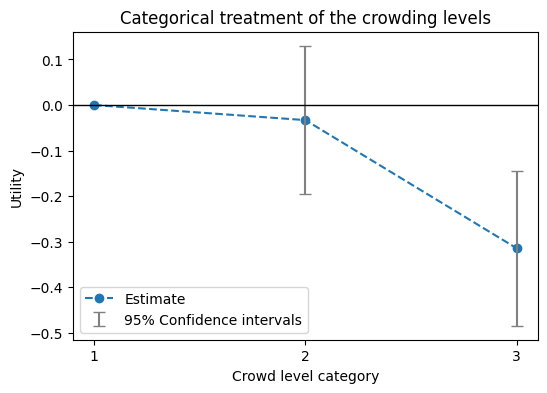

In [82]:
# Illustrate the effect of crowding levels the utility
fig, ax = plt.subplots(figsize=(6, 4))

# Add B_noise_cat1 = 0 to the beta_hat_cat
beta_hat_cat = results_cat.get_estimated_parameters()

beta_hat_cat.loc['B_crowd_bus_low', 'Value']  = 0
beta_crowd = beta_hat_cat.loc[['B_crowd_bus_low','B_crowd_bus_med','B_crowd_bus_hig'],['Value','Rob. Std err']]
print("beta_crowd =", *(f'{b:#0.3f}' for b in beta_crowd['Value']))

# Plot the effect of the crowd levels on utility
x = list(range(1, 4, 1)) # categories of crowd levels
y_est = beta_crowd['Value']
y_stderr = 1.96 * beta_crowd['Rob. Std err']

ax.plot(x, y_est,'o--',label='Estimate')
ax.errorbar(x, y_est, yerr=y_stderr, fmt='none',ecolor='grey',elinewidth=1.5,capsize=4,label='95% Confidence intervals')
ax.axhline(0, color='black', linestyle='-', linewidth=1)
ax.set_xlabel('Crowd level category')
ax.set_xticks(x)
ax.set_ylabel('Utility')
ax.set_title('Categorical treatment of the crowding levels')
ax.legend(loc='best')
plt.show()

In [83]:
# ============================================================
# MNL WITH EXPONENTIAL TIME
# ============================================================
model_name    = 'Non linear-additive RUM MNL (exp(time))'

# Define model parameters
# Define the model parameters, using the function "Beta()", in which you must define:
# the name of the parameter - usually the name of the variable,
# starting value - usually 0, but can be any number,
# lower bound - usually None, but can be any number,
# upper bound - usually None, but can be any number,
# 0 or 1, indicating if the parameter must be estimated. 0 means estimated, 1 means fixed to the starting value. 

B_time_car  = Beta('B_time_car' , 0, None, None, 0)
B_rbt_car   = Beta('B_rbt_car'  , 0, None, None, 0)
B_cost_car  = Beta('B_cost_car' , 0, None, None, 0)
B_time_bus  = Beta('B_time_bus' , 0, None, None, 0)
B_rbt_bus   = Beta('B_rbt_bus'  , 0, None, None, 0)
B_cost_bus  = Beta('B_cost_bus' , 0, None, None, 0)
B_crowd_bus = Beta('B_crowd_bus', 0, None, None, 0)
B_time_bike = Beta('B_time_bike', 0, None, None, 0)
B_rbt_bike  = Beta('B_rbt_bike' , 0, None, None, 0)
ASC_car     = Beta('ASC_car'    , 0, None, None, 1) # fixed to 0
ASC_bus     = Beta('ASC_bus'    , 0, None, None, 0)
ASC_bike    = Beta('ASC_bike'   , 0, None, None, 0)

# Define utility functions
V_car  = ASC_car  + B_time_car  * exp(time_car)  + B_rbt_car * (rbt_car) + B_cost_car * (cost_car)
V_bus  = ASC_bus  + B_time_bus  * exp(time_bus)  + B_rbt_bus * (rbt_bus) + B_cost_bus * (cost_bus) + B_crowd_bus * crowd_bus
V_bike = ASC_bike + B_time_bike * exp(time_bike) + B_rbt_bike * (rbt_bike)

# Dictionary to map utility function to alternative number
V = {1:V_car, 2:V_bus, 3:V_bike}

# Dictionary to map availability to alternative number
AV = {1: AV1, 2: AV2, 3:AV3}

# Estimate
results_mnl_exptt = estimate_mnl(V, AV, CHOICE, biodata, model_name)

# Print the estimation statistics
print_results(results_mnl_exptt)

all_models['Non-linear additive RUM MNL (exp-tt)'] = results_mnl_exptt



Results for model Non linear-additive RUM MNL (exp(time))
Nbr of parameters:		11
Sample size:			4347
Excluded data:			0
Null log likelihood:		-4775.668
Final log likelihood:		-4051.465
Likelihood ratio test (null):		1448.406
Rho square (null):			0.152
Rho bar square (null):			0.149
Akaike Information Criterion:	8124.929
Bayesian Information Criterion:	8195.079

              Value  Rob. Std err   Rob. t-test  Rob. p-value
ASC_bike    -0.8294           0.0 -4.785839e+22           0.0
ASC_bus      0.1515           0.0  1.748064e+22           0.0
B_cost_bus  -0.0953           0.0 -5.625909e+21           0.0
B_cost_car  -0.0538           0.0 -2.998120e+21           0.0
B_crowd_bus -0.1463           0.0 -8.449848e+21           0.0
B_rbt_bike  -0.0283           0.0 -2.842247e+20           0.0
B_rbt_bus   -0.0129           0.0 -2.511244e+20           0.0
B_rbt_car    0.0344           0.0  4.088047e+20           0.0
B_time_bike -0.0000           0.0 -9.220000e+00           0.0
B_time_bus  -0

In [84]:
# ============================================================
# MNL WITH QUADRATIC TIME
# ============================================================
model_name    = 'Non linear-additive RUM MNL ((time)**2)'

# Define model parameters
# Define the model parameters, using the function "Beta()", in which you must define:
# the name of the parameter - usually the name of the variable,
# starting value - usually 0, but can be any number,
# lower bound - usually None, but can be any number,
# upper bound - usually None, but can be any number,
# 0 or 1, indicating if the parameter must be estimated. 0 means estimated, 1 means fixed to the starting value. 

B_time_car  = Beta('B_time_car' , 0, None, None, 0)
B_rbt_car   = Beta('B_rbt_car'  , 0, None, None, 0)
B_cost_car  = Beta('B_cost_car' , 0, None, None, 0)
B_time_bus  = Beta('B_time_bus' , 0, None, None, 0)
B_rbt_bus   = Beta('B_rbt_bus'  , 0, None, None, 0)
B_cost_bus  = Beta('B_cost_bus' , 0, None, None, 0)
B_crowd_bus = Beta('B_crowd_bus', 0, None, None, 0)
B_time_bike = Beta('B_time_bike', 0, None, None, 0)
B_rbt_bike  = Beta('B_rbt_bike' , 0, None, None, 0)
ASC_car     = Beta('ASC_car'    , 0, None, None, 1) # fixed to 0
ASC_bus     = Beta('ASC_bus'    , 0, None, None, 0)
ASC_bike    = Beta('ASC_bike'   , 0, None, None, 0)

# Define utility functions
V_car  = ASC_car  + B_time_car  * (time_car)**2  + B_rbt_car * (rbt_car) + B_cost_car * (cost_car)
V_bus  = ASC_bus  + B_time_bus  * (time_bus)**2  + B_rbt_bus * (rbt_bus) + B_cost_bus * (cost_bus) + B_crowd_bus * crowd_bus
V_bike = ASC_bike + B_time_bike * (time_bike)**2 + B_rbt_bike * (rbt_bike)

# Dictionary to map utility function to alternative number
V = {1:V_car, 2:V_bus, 3:V_bike}

# Dictionary to map availability to alternative number
AV = {1: AV1, 2: AV2, 3:AV3}

# Estimate
results_mnl_tt2 = estimate_mnl(V, AV, CHOICE, biodata, model_name)

# Print the estimation statistics
print_results(results_mnl_tt2)

all_models['Non-linear additive RUM MNL (tt2)'] = results_mnl_tt2



Results for model Non linear-additive RUM MNL ((time)**2)
Nbr of parameters:		11
Sample size:			4347
Excluded data:			0
Null log likelihood:		-4775.668
Final log likelihood:		-4067.479
Likelihood ratio test (null):		1416.377
Rho square (null):			0.148
Rho bar square (null):			0.146
Akaike Information Criterion:	8156.958
Bayesian Information Criterion:	8227.108

              Value  Rob. Std err  Rob. t-test  Rob. p-value
ASC_bike    -1.4350        0.1421       -10.10          0.00
ASC_bus     -0.4156        0.1632        -2.55          0.01
B_cost_bus  -0.1009        0.0210        -4.80          0.00
B_cost_car  -0.0844        0.0191        -4.41          0.00
B_crowd_bus -0.1670        0.0416        -4.02          0.00
B_rbt_bike   0.0186        0.0146         1.28          0.20
B_rbt_bus   -0.0151        0.0117        -1.28          0.20
B_rbt_car    0.0078        0.0076         1.02          0.31
B_time_bike -0.0018        0.0002        -9.30          0.00
B_time_bus  -0.0018     

In [85]:
# ============================================================
# MNL WITH LOGARITHMIC RBT
# ============================================================
model_name    = 'Non linear-additive RUM MNL (log(1+rbt))'

# Define model parameters
# Define the model parameters, using the function "Beta()", in which you must define:
# the name of the parameter - usually the name of the variable,
# starting value - usually 0, but can be any number,
# lower bound - usually None, but can be any number,
# upper bound - usually None, but can be any number,
# 0 or 1, indicating if the parameter must be estimated. 0 means estimated, 1 means fixed to the starting value. 

B_time_car  = Beta('B_time_car' , 0, None, None, 0)
B_rbt_car   = Beta('B_rbt_car'  , 0, None, None, 0)
B_cost_car  = Beta('B_cost_car' , 0, None, None, 0)
B_time_bus  = Beta('B_time_bus' , 0, None, None, 0)
B_rbt_bus   = Beta('B_rbt_bus'  , 0, None, None, 0)
B_cost_bus  = Beta('B_cost_bus' , 0, None, None, 0)
B_crowd_bus = Beta('B_crowd_bus', 0, None, None, 0)
B_time_bike = Beta('B_time_bike', 0, None, None, 0)
B_rbt_bike  = Beta('B_rbt_bike' , 0, None, None, 0)
ASC_car     = Beta('ASC_car'    , 0, None, None, 1) # fixed to 0
ASC_bus     = Beta('ASC_bus'    , 0, None, None, 0)
ASC_bike    = Beta('ASC_bike'   , 0, None, None, 0)

# Define utility functions
V_car  = ASC_car  + B_time_car  * time_car  + B_rbt_car * log(1+rbt_car) + B_cost_car * (cost_car)
V_bus  = ASC_bus  + B_time_bus  * time_bus  + B_rbt_bus * log(1+rbt_bus) + B_cost_bus * (cost_bus) + B_crowd_bus * crowd_bus
V_bike = ASC_bike + B_time_bike * time_bike + B_rbt_bike * log(1+rbt_bike)

# Dictionary to map utility function to alternative number
V = {1:V_car, 2:V_bus, 3:V_bike}

# Dictionary to map availability to alternative number
AV = {1: AV1, 2: AV2, 3:AV3}

# Estimate
results_mnl_logrbt1 = estimate_mnl(V, AV, CHOICE, biodata, model_name)

# Print the estimation statistics
print_results(results_mnl_logrbt1)

all_models['Non-linear additive RUM MNL log(1+rbt)'] = results_mnl_logrbt1



Results for model Non linear-additive RUM MNL (log(1+rbt))
Nbr of parameters:		11
Sample size:			4347
Excluded data:			0
Null log likelihood:		-4775.668
Final log likelihood:		-4016.089
Likelihood ratio test (null):		1519.158
Rho square (null):			0.159
Rho bar square (null):			0.157
Akaike Information Criterion:	8054.177
Bayesian Information Criterion:	8124.327

              Value  Rob. Std err  Rob. t-test  Rob. p-value
ASC_bike    -1.4961        0.2952        -5.07          0.00
ASC_bus     -0.6304        0.2624        -2.40          0.02
B_cost_bus  -0.0976        0.0214        -4.55          0.00
B_cost_car  -0.0698        0.0193        -3.62          0.00
B_crowd_bus -0.1551        0.0426        -3.64          0.00
B_rbt_bike   0.1238        0.1043         1.19          0.24
B_rbt_bus   -0.1096        0.0847        -1.29          0.20
B_rbt_car    0.0592        0.0776         0.76          0.45
B_time_bike -0.0489        0.0054        -9.01          0.00
B_time_bus  -0.0434    

In [86]:
# ============================================================
# MNL WITH QUADRATIC COST
# ============================================================
model_name    = 'Non linear-additive RUM MNL ((cost)**2)'

# Define model parameters
# Define the model parameters, using the function "Beta()", in which you must define:
# the name of the parameter - usually the name of the variable,
# starting value - usually 0, but can be any number,
# lower bound - usually None, but can be any number,
# upper bound - usually None, but can be any number,
# 0 or 1, indicating if the parameter must be estimated. 0 means estimated, 1 means fixed to the starting value. 

B_time_car  = Beta('B_time_car' , 0, None, None, 0)
B_rbt_car   = Beta('B_rbt_car'  , 0, None, None, 0)
B_cost_car  = Beta('B_cost_car' , 0, None, None, 0)
B_time_bus  = Beta('B_time_bus' , 0, None, None, 0)
B_rbt_bus   = Beta('B_rbt_bus'  , 0, None, None, 0)
B_cost_bus  = Beta('B_cost_bus' , 0, None, None, 0)
B_crowd_bus = Beta('B_crowd_bus', 0, None, None, 0)
B_time_bike = Beta('B_time_bike', 0, None, None, 0)
B_rbt_bike  = Beta('B_rbt_bike' , 0, None, None, 0)
ASC_car     = Beta('ASC_car'    , 0, None, None, 1) # fixed to 0
ASC_bus     = Beta('ASC_bus'    , 0, None, None, 0)
ASC_bike    = Beta('ASC_bike'   , 0, None, None, 0)

# Define utility functions
V_car  = ASC_car  + B_time_car  * (time_car)  + B_rbt_car * (rbt_car) + B_cost_car * (cost_car)**2
V_bus  = ASC_bus  + B_time_bus  * (time_bus)  + B_rbt_bus * (rbt_bus) + B_cost_bus * (cost_bus)**2 + B_crowd_bus * crowd_bus
V_bike = ASC_bike + B_time_bike * (time_bike) + B_rbt_bike * (rbt_bike)

# Dictionary to map utility function to alternative number
V = {1:V_car, 2:V_bus, 3:V_bike}

# Dictionary to map availability to alternative number
AV = {1: AV1, 2: AV2, 3:AV3}

# Estimate
results_mnl_cost2 = estimate_mnl(V, AV, CHOICE, biodata, model_name)

# Print the estimation statistics
print_results(results_mnl_cost2)

all_models['Non-linear additive RUM MNL (cost^2)'] = results_mnl_cost2



Results for model Non linear-additive RUM MNL ((cost)**2)
Nbr of parameters:		11
Sample size:			4347
Excluded data:			0
Null log likelihood:		-4775.668
Final log likelihood:		-4015.393
Likelihood ratio test (null):		1520.55
Rho square (null):			0.159
Rho bar square (null):			0.157
Akaike Information Criterion:	8052.785
Bayesian Information Criterion:	8122.935

              Value  Rob. Std err  Rob. t-test  Rob. p-value
ASC_bike    -1.4499        0.1680        -8.63          0.00
ASC_bus     -0.8653        0.1593        -5.43          0.00
B_cost_bus  -0.0211        0.0052        -4.04          0.00
B_cost_car  -0.0199        0.0046        -4.31          0.00
B_crowd_bus -0.1601        0.0425        -3.76          0.00
B_rbt_bike   0.0185        0.0146         1.27          0.20
B_rbt_bus   -0.0135        0.0120        -1.13          0.26
B_rbt_car    0.0064        0.0077         0.84          0.40
B_time_bike -0.0486        0.0054        -8.95          0.00
B_time_bus  -0.0434      

In [87]:
# ============================================================
# MNL WITH EXPONENTIAL COST
# ============================================================
model_name    = 'Non linear-additive RUM MNL (exp(cost))'

# Define model parameters
# Define the model parameters, using the function "Beta()", in which you must define:
# the name of the parameter - usually the name of the variable,
# starting value - usually 0, but can be any number,
# lower bound - usually None, but can be any number,
# upper bound - usually None, but can be any number,
# 0 or 1, indicating if the parameter must be estimated. 0 means estimated, 1 means fixed to the starting value. 

B_time_car  = Beta('B_time_car' , 0, None, None, 0)
B_rbt_car   = Beta('B_rbt_car'  , 0, None, None, 0)
B_cost_car  = Beta('B_cost_car' , 0, None, None, 0)
B_time_bus  = Beta('B_time_bus' , 0, None, None, 0)
B_rbt_bus   = Beta('B_rbt_bus'  , 0, None, None, 0)
B_cost_bus  = Beta('B_cost_bus' , 0, None, None, 0)
B_crowd_bus = Beta('B_crowd_bus', 0, None, None, 0)
B_time_bike = Beta('B_time_bike', 0, None, None, 0)
B_rbt_bike  = Beta('B_rbt_bike' , 0, None, None, 0)
ASC_car     = Beta('ASC_car'    , 0, None, None, 1) # fixed to 0
ASC_bus     = Beta('ASC_bus'    , 0, None, None, 0)
ASC_bike    = Beta('ASC_bike'   , 0, None, None, 0)

# Define utility functions
V_car  = ASC_car  + B_time_car  * (time_car)  + B_rbt_car * (rbt_car) + B_cost_car * exp(cost_car)
V_bus  = ASC_bus  + B_time_bus  * (time_bus)  + B_rbt_bus * (rbt_bus) + B_cost_bus * exp(cost_bus) + B_crowd_bus * crowd_bus
V_bike = ASC_bike + B_time_bike * (time_bike) + B_rbt_bike * (rbt_bike)

# Dictionary to map utility function to alternative number
V = {1:V_car, 2:V_bus, 3:V_bike}

# Dictionary to map availability to alternative number
AV = {1: AV1, 2: AV2, 3:AV3}

# Estimate
results_mnl_expcost = estimate_mnl(V, AV, CHOICE, biodata, model_name)

# Print the estimation statistics
print_results(results_mnl_expcost)

all_models['Non-linear additive RUM MNL exp(cost)'] = results_mnl_expcost



Results for model Non linear-additive RUM MNL (exp(cost))
Nbr of parameters:		11
Sample size:			4347
Excluded data:			0
Null log likelihood:		-4775.668
Final log likelihood:		-4015.765
Likelihood ratio test (null):		1519.805
Rho square (null):			0.159
Rho bar square (null):			0.157
Akaike Information Criterion:	8053.53
Bayesian Information Criterion:	8123.68

              Value  Rob. Std err  Rob. t-test  Rob. p-value
ASC_bike    -1.4386        0.1674        -8.60          0.00
ASC_bus     -0.8820        0.1586        -5.56          0.00
B_cost_bus  -0.0055        0.0015        -3.70          0.00
B_cost_car  -0.0059        0.0013        -4.53          0.00
B_crowd_bus -0.1614        0.0425        -3.80          0.00
B_rbt_bike   0.0180        0.0146         1.23          0.22
B_rbt_bus   -0.0134        0.0120        -1.12          0.26
B_rbt_car    0.0065        0.0077         0.84          0.40
B_time_bike -0.0487        0.0054        -8.96          0.00
B_time_bus  -0.0435       

In [88]:
# ============================================================
# MNL WITH QUADRATIC RBT
# ============================================================
model_name    = 'Non linear-additive RUM MNL ((RBT)**2)'

# Define model parameters
# Define the model parameters, using the function "Beta()", in which you must define:
# the name of the parameter - usually the name of the variable,
# starting value - usually 0, but can be any number,
# lower bound - usually None, but can be any number,
# upper bound - usually None, but can be any number,
# 0 or 1, indicating if the parameter must be estimated. 0 means estimated, 1 means fixed to the starting value. 

B_time_car  = Beta('B_time_car' , 0, None, None, 0)
B_rbt_car   = Beta('B_rbt_car'  , 0, None, None, 0)
B_cost_car  = Beta('B_cost_car' , 0, None, None, 0)
B_time_bus  = Beta('B_time_bus' , 0, None, None, 0)
B_rbt_bus   = Beta('B_rbt_bus'  , 0, None, None, 0)
B_cost_bus  = Beta('B_cost_bus' , 0, None, None, 0)
B_crowd_bus = Beta('B_crowd_bus', 0, None, None, 0)
B_time_bike = Beta('B_time_bike', 0, None, None, 0)
B_rbt_bike  = Beta('B_rbt_bike' , 0, None, None, 0)
ASC_car     = Beta('ASC_car'    , 0, None, None, 1) # fixed to 0
ASC_bus     = Beta('ASC_bus'    , 0, None, None, 0)
ASC_bike    = Beta('ASC_bike'   , 0, None, None, 0)

# Define utility functions
V_car  = ASC_car  + B_time_car  * (time_car)  + B_rbt_car * (rbt_car)**2 + B_cost_car * (cost_car)
V_bus  = ASC_bus  + B_time_bus  * (time_bus)  + B_rbt_bus * (rbt_bus)**2 + B_cost_bus * (cost_bus) + B_crowd_bus * crowd_bus
V_bike = ASC_bike + B_time_bike * (time_bike) + B_rbt_bike * (rbt_bike)**2

# Dictionary to map utility function to alternative number
V = {1:V_car, 2:V_bus, 3:V_bike}

# Dictionary to map availability to alternative number
AV = {1: AV1, 2: AV2, 3:AV3}

# Estimate
results_mnl_rbt2 = estimate_mnl(V, AV, CHOICE, biodata, model_name)

# Print the estimation statistics
print_results(results_mnl_rbt2)

all_models['Non-linear additive RUM MNL (rbt^2)'] = results_mnl_rbt2



Results for model Non linear-additive RUM MNL ((RBT)**2)
Nbr of parameters:		11
Sample size:			4347
Excluded data:			0
Null log likelihood:		-4775.668
Final log likelihood:		-4016.244
Likelihood ratio test (null):		1518.848
Rho square (null):			0.159
Rho bar square (null):			0.157
Akaike Information Criterion:	8054.488
Bayesian Information Criterion:	8124.637

              Value  Rob. Std err  Rob. t-test  Rob. p-value
ASC_bike    -1.4283        0.1385       -10.31          0.00
ASC_bus     -0.8934        0.1387        -6.44          0.00
B_cost_bus  -0.0972        0.0215        -4.53          0.00
B_cost_car  -0.0694        0.0193        -3.60          0.00
B_crowd_bus -0.1551        0.0425        -3.65          0.00
B_rbt_bike   0.0015        0.0011         1.40          0.16
B_rbt_bus   -0.0008        0.0009        -0.90          0.37
B_rbt_car    0.0003        0.0004         0.89          0.37
B_time_bike -0.0489        0.0054        -9.01          0.00
B_time_bus  -0.0435      

In [89]:
# ============================================================
# MNL WITH LOGARITHMIC RBT
# ============================================================
model_name    = 'Non linear-additive RUM MNL (log(RBT))'

# Define model parameters
# Define the model parameters, using the function "Beta()", in which you must define:
# the name of the parameter - usually the name of the variable,
# starting value - usually 0, but can be any number,
# lower bound - usually None, but can be any number,
# upper bound - usually None, but can be any number,
# 0 or 1, indicating if the parameter must be estimated. 0 means estimated, 1 means fixed to the starting value. 

B_time_car  = Beta('B_time_car' , 0, None, None, 0)
B_rbt_car   = Beta('B_rbt_car'  , 0, None, None, 0)
B_cost_car  = Beta('B_cost_car' , 0, None, None, 0)
B_time_bus  = Beta('B_time_bus' , 0, None, None, 0)
B_rbt_bus   = Beta('B_rbt_bus'  , 0, None, None, 0)
B_cost_bus  = Beta('B_cost_bus' , 0, None, None, 0)
B_crowd_bus = Beta('B_crowd_bus', 0, None, None, 0)
B_time_bike = Beta('B_time_bike', 0, None, None, 0)
B_rbt_bike  = Beta('B_rbt_bike' , 0, None, None, 0)
ASC_car     = Beta('ASC_car'    , 0, None, None, 1) # fixed to 0
ASC_bus     = Beta('ASC_bus'    , 0, None, None, 0)
ASC_bike    = Beta('ASC_bike'   , 0, None, None, 0)

# Define utility functions
V_car  = ASC_car  + B_time_car  * (time_car)  + B_rbt_car * log(rbt_car) + B_cost_car * (cost_car)
V_bus  = ASC_bus  + B_time_bus  * (time_bus)  + B_rbt_bus * log(rbt_bus) + B_cost_bus * (cost_bus) + B_crowd_bus * crowd_bus
V_bike = ASC_bike + B_time_bike * (time_bike) + B_rbt_bike * log(rbt_bike)

# Dictionary to map utility function to alternative number
V = {1:V_car, 2:V_bus, 3:V_bike}

# Dictionary to map availability to alternative number
AV = {1: AV1, 2: AV2, 3:AV3}

# Estimate
results_mnl_logrbt = estimate_mnl(V, AV, CHOICE, biodata, model_name)

# Print the estimation statistics
print_results(results_mnl_logrbt)

all_models['Non-linear additive RUM MNL log(rbt)'] = results_mnl_logrbt



Results for model Non linear-additive RUM MNL (log(RBT))
Nbr of parameters:		11
Sample size:			4347
Excluded data:			0
Null log likelihood:		-4775.668
Final log likelihood:		-4016.069
Likelihood ratio test (null):		1519.197
Rho square (null):			0.159
Rho bar square (null):			0.157
Akaike Information Criterion:	8054.139
Bayesian Information Criterion:	8124.288

              Value  Rob. Std err  Rob. t-test  Rob. p-value
ASC_bike    -1.4602        0.2479        -5.89          0.00
ASC_bus     -0.6983        0.2250        -3.10          0.00
B_cost_bus  -0.0976        0.0214        -4.55          0.00
B_cost_car  -0.0698        0.0193        -3.62          0.00
B_crowd_bus -0.1552        0.0426        -3.65          0.00
B_rbt_bike   0.1025        0.0880         1.16          0.24
B_rbt_bus   -0.0950        0.0713        -1.33          0.18
B_rbt_car    0.0519        0.0691         0.75          0.45
B_time_bike -0.0489        0.0054        -9.01          0.00
B_time_bus  -0.0434      

***`d. MNL estimation with interaction effects to current commuting conditions`***

In [90]:
# ============================================================
# MNL WITH INTERACTION EFFECT TO CURRENT TT AND TC
# ============================================================
model_name    = 'Non linear-additive RUM MNL (add reference TT and TC)'

# Define model parameters
# Define the model parameters, using the function "Beta()", in which you must define:
# the name of the parameter - usually the name of the variable,
# starting value - usually 0, but can be any number,
# lower bound - usually None, but can be any number,
# upper bound - usually None, but can be any number,
# 0 or 1, indicating if the parameter must be estimated. 0 means estimated, 1 means fixed to the starting value. 

B_time_car  = Beta('B_time_car' , 0, None, None, 0)
B_rbt_car   = Beta('B_rbt_car'  , 0, None, None, 0)
B_cost_car  = Beta('B_cost_car' , 0, None, None, 0)
B_time_bus  = Beta('B_time_bus' , 0, None, None, 0)
B_rbt_bus   = Beta('B_rbt_bus'  , 0, None, None, 0)
B_cost_bus  = Beta('B_cost_bus' , 0, None, None, 0)
B_crowd_bus = Beta('B_crowd_bus', 0, None, None, 0)
B_time_bike = Beta('B_time_bike', 0, None, None, 0)
B_rbt_bike  = Beta('B_rbt_bike' , 0, None, None, 0)
ASC_car     = Beta('ASC_car'    , 0, None, None, 1) # fixed to 0
ASC_bus     = Beta('ASC_bus'    , 0, None, None, 0)
ASC_bike    = Beta('ASC_bike'   , 0, None, None, 0)

B_timecar_int = Beta('B_timecar_int' , 0, None, None, 0)
B_timebus_int = Beta('B_timebus_int' , 0, None, None, 0)
B_timebike_int = Beta('B_timebike_int' , 0, None, None, 0)

B_costcar_int = Beta('B_costcar_int' , 0, None, None, 0)
B_costbus_int = Beta('B_costbus_int' , 0, None, None, 0)

# Define utility functions
V_car  = ASC_car  + (B_time_car + B_timecar_int * (TT_CURRENT)) * (time_car)   + B_rbt_car * (rbt_car) + (B_cost_car + B_costcar_int * (TC_CURRENT)) * (cost_car) 
V_bus  = ASC_bus  + (B_time_bus + B_timebus_int * (TT_CURRENT)) * (time_bus)   + B_rbt_bus * (rbt_bus) + (B_cost_bus + B_costbus_int * (TC_CURRENT)) * (cost_bus)  + B_crowd_bus * crowd_bus
V_bike = ASC_bike + (B_time_bike + B_timebike_int * (TT_CURRENT))* (time_bike)  + B_rbt_bike * (rbt_bike)

# Dictionary to map utility function to alternative number
V = {1:V_car, 2:V_bus, 3:V_bike}

# Dictionary to map availability to alternative number
AV = {1: AV1, 2: AV2, 3:AV3}

# Estimate
results_mnl_baselineTB = estimate_mnl(V, AV, CHOICE, biodata, model_name)

# Print the estimation statistics
print_results(results_mnl_baselineTB)

all_models['Linear additive RUM MNL interaction current TB'] = results_mnl_baselineTB



Results for model Non linear-additive RUM MNL (add reference TT and TC)
Nbr of parameters:		16
Sample size:			4347
Excluded data:			0
Null log likelihood:		-4775.668
Final log likelihood:		-3983.412
Likelihood ratio test (null):		1584.511
Rho square (null):			0.166
Rho bar square (null):			0.163
Akaike Information Criterion:	7998.824
Bayesian Information Criterion:	8100.86

                 Value  Rob. Std err  Rob. t-test  Rob. p-value
ASC_bike       -1.4540        0.1706        -8.52          0.00
ASC_bus        -0.8307        0.1620        -5.13          0.00
B_cost_bus     -0.1263        0.0260        -4.86          0.00
B_cost_car     -0.1138        0.0235        -4.84          0.00
B_costbus_int   0.0079        0.0040         1.99          0.05
B_costcar_int   0.0116        0.0038         3.09          0.00
B_crowd_bus    -0.1533        0.0427        -3.59          0.00
B_rbt_bike      0.0196        0.0146         1.34          0.18
B_rbt_bus      -0.0136        0.0120        -

In [91]:
# ============================================================
# MNL WITH INTERACTION EFFECT TO CURRENT TT, TC, AND TR_LATE
# ============================================================
model_name    = 'Non linear-additive RUM MNL (add reference TT, TC, TR late)'

# Define model parameters
# Define the model parameters, using the function "Beta()", in which you must define:
# the name of the parameter - usually the name of the variable,
# starting value - usually 0, but can be any number,
# lower bound - usually None, but can be any number,
# upper bound - usually None, but can be any number,
# 0 or 1, indicating if the parameter must be estimated. 0 means estimated, 1 means fixed to the starting value. 

B_time_car  = Beta('B_time_car' , 0, None, None, 0)
B_rbt_car   = Beta('B_rbt_car'  , 0, None, None, 0)
B_cost_car  = Beta('B_cost_car' , 0, None, None, 0)
B_time_bus  = Beta('B_time_bus' , 0, None, None, 0)
B_rbt_bus   = Beta('B_rbt_bus'  , 0, None, None, 0)
B_cost_bus  = Beta('B_cost_bus' , 0, None, None, 0)
B_crowd_bus = Beta('B_crowd_bus', 0, None, None, 0)
B_time_bike = Beta('B_time_bike', 0, None, None, 0)
B_rbt_bike  = Beta('B_rbt_bike' , 0, None, None, 0)
ASC_car     = Beta('ASC_car'    , 0, None, None, 1) # fixed to 0
ASC_bus     = Beta('ASC_bus'    , 0, None, None, 0)
ASC_bike    = Beta('ASC_bike'   , 0, None, None, 0)

B_timecar_int = Beta('B_timecar_int' , 0, None, None, 0)
B_timebus_int = Beta('B_timebus_int' , 0, None, None, 0)
B_timebike_int = Beta('B_timebike_int' , 0, None, None, 0)

B_costcar_int = Beta('B_costcar_int' , 0, None, None, 0)
B_costbus_int = Beta('B_costbus_int' , 0, None, None, 0)

B_rbtcar_int = Beta('B_rbtcar_int' , 0, None, None, 0)
B_rbtbus_int = Beta('B_rbtbus_int' , 0, None, None, 0)
B_rbtbike_int = Beta('B_rbtbike_int' , 0, None, None, 0)

# Define utility functions
V_car  = ASC_car  + (B_time_car + B_timecar_int * (TT_CURRENT)) * (time_car)   + (B_rbt_car + B_rbtcar_int *(TR_LATE)) * (rbt_car) + (B_cost_car + B_costcar_int * (TC_CURRENT)) * (cost_car) 
V_bus  = ASC_bus  + (B_time_bus + B_timebus_int * (TT_CURRENT)) * (time_bus)   + (B_rbt_bus + B_rbtbus_int *(TR_LATE)) * (rbt_bus) + (B_cost_bus + B_costbus_int * (TC_CURRENT)) * (cost_bus)  + B_crowd_bus * crowd_bus
V_bike = ASC_bike + (B_time_bike + B_timebike_int * (TT_CURRENT))* (time_bike)  + (B_rbt_bike + B_rbtbike_int *(TR_LATE))* (rbt_bike)

# Dictionary to map utility function to alternative number
V = {1:V_car, 2:V_bus, 3:V_bike}

# Dictionary to map availability to alternative number
AV = {1: AV1, 2: AV2, 3:AV3}

# Estimate
results_mnl_baselineTB_late = estimate_mnl(V, AV, CHOICE, biodata, model_name)

# Print the estimation statistics
print_results(results_mnl_baselineTB_late)

all_models['Linear additive RUM MNL interaction current TB and TR late'] = results_mnl_baselineTB_late



Results for model Non linear-additive RUM MNL (add reference TT, TC, TR late)
Nbr of parameters:		19
Sample size:			4347
Excluded data:			0
Null log likelihood:		-4775.668
Final log likelihood:		-3978.562
Likelihood ratio test (null):		1594.212
Rho square (null):			0.167
Rho bar square (null):			0.163
Akaike Information Criterion:	7995.123
Bayesian Information Criterion:	8116.291

                 Value  Rob. Std err  Rob. t-test  Rob. p-value
ASC_bike       -1.4518        0.1706        -8.51          0.00
ASC_bus        -0.8306        0.1619        -5.13          0.00
B_cost_bus     -0.1235        0.0260        -4.75          0.00
B_cost_car     -0.1109        0.0236        -4.70          0.00
B_costbus_int   0.0071        0.0040         1.79          0.07
B_costcar_int   0.0108        0.0038         2.85          0.00
B_crowd_bus    -0.1530        0.0427        -3.58          0.00
B_rbt_bike      0.0421        0.0260         1.62          0.11
B_rbt_bus      -0.0383        0.0243  

In [92]:
# ============================================================
# MNL WITH INTERACTION EFFECT TO CURRENT TT, TC, AND TR_EARLY
# ============================================================
model_name    = 'Non linear-additive RUM MNL (add reference TT, TC, TR early)'

# Define model parameters
# Define the model parameters, using the function "Beta()", in which you must define:
# the name of the parameter - usually the name of the variable,
# starting value - usually 0, but can be any number,
# lower bound - usually None, but can be any number,
# upper bound - usually None, but can be any number,
# 0 or 1, indicating if the parameter must be estimated. 0 means estimated, 1 means fixed to the starting value. 

B_time_car  = Beta('B_time_car' , 0, None, None, 0)
B_rbt_car   = Beta('B_rbt_car'  , 0, None, None, 0)
B_cost_car  = Beta('B_cost_car' , 0, None, None, 0)
B_time_bus  = Beta('B_time_bus' , 0, None, None, 0)
B_rbt_bus   = Beta('B_rbt_bus'  , 0, None, None, 0)
B_cost_bus  = Beta('B_cost_bus' , 0, None, None, 0)
B_crowd_bus = Beta('B_crowd_bus', 0, None, None, 0)
B_time_bike = Beta('B_time_bike', 0, None, None, 0)
B_rbt_bike  = Beta('B_rbt_bike' , 0, None, None, 0)
ASC_car     = Beta('ASC_car'    , 0, None, None, 1) # fixed to 0
ASC_bus     = Beta('ASC_bus'    , 0, None, None, 0)
ASC_bike    = Beta('ASC_bike'   , 0, None, None, 0)

B_timecar_int = Beta('B_timecar_int' , 0, None, None, 0)
B_timebus_int = Beta('B_timebus_int' , 0, None, None, 0)
B_timebike_int = Beta('B_timebike_int' , 0, None, None, 0)

B_costcar_int = Beta('B_costcar_int' , 0, None, None, 0)
B_costbus_int = Beta('B_costbus_int' , 0, None, None, 0)

B_rbtecar_int = Beta('B_rbtcar_int' , 0, None, None, 0)
B_rbtebus_int = Beta('B_rbtbus_int' , 0, None, None, 0)
B_rbtebike_int = Beta('B_rbtbike_int' , 0, None, None, 0)

# Define utility functions
V_car  = ASC_car  + (B_time_car + B_timecar_int * (TT_CURRENT)) * (time_car)   + (B_rbt_car + B_rbtecar_int *(TR_EARLY)) * (rbt_car) + (B_cost_car + B_costcar_int * (TC_CURRENT)) * (cost_car) 
V_bus  = ASC_bus  + (B_time_bus + B_timebus_int * (TT_CURRENT)) * (time_bus)   + (B_rbt_bus + B_rbtebus_int *(TR_EARLY)) * (rbt_bus) + (B_cost_bus + B_costbus_int * (TC_CURRENT)) * (cost_bus)  + B_crowd_bus * crowd_bus
V_bike = ASC_bike + (B_time_bike + B_timebike_int * (TT_CURRENT))* (time_bike)  + (B_rbt_bike + B_rbtebike_int *(TR_EARLY))* (rbt_bike)

# Dictionary to map utility function to alternative number
V = {1:V_car, 2:V_bus, 3:V_bike}

# Dictionary to map availability to alternative number
AV = {1: AV1, 2: AV2, 3:AV3}

# Estimate
results_mnl_baselineTB_early = estimate_mnl(V, AV, CHOICE, biodata, model_name)

# Print the estimation statistics
print_results(results_mnl_baselineTB_early)

all_models['Linear additive RUM MNL interaction current TB and TR early'] = results_mnl_baselineTB_early



Results for model Non linear-additive RUM MNL (add reference TT, TC, TR early)
Nbr of parameters:		19
Sample size:			4347
Excluded data:			0
Null log likelihood:		-4775.668
Final log likelihood:		-3962.092
Likelihood ratio test (null):		1627.152
Rho square (null):			0.17
Rho bar square (null):			0.166
Akaike Information Criterion:	7962.184
Bayesian Information Criterion:	8083.351

                 Value  Rob. Std err  Rob. t-test  Rob. p-value
ASC_bike       -1.4295        0.1717        -8.33          0.00
ASC_bus        -0.8248        0.1617        -5.10          0.00
B_cost_bus     -0.1163        0.0264        -4.41          0.00
B_cost_car     -0.0980        0.0238        -4.12          0.00
B_costbus_int   0.0052        0.0041         1.25          0.21
B_costcar_int   0.0073        0.0039         1.89          0.06
B_crowd_bus    -0.1551        0.0427        -3.64          0.00
B_rbt_bike      0.0854        0.0231         3.70          0.00
B_rbt_bus      -0.0286        0.0211  

### `6. Attribute importance test`

In [93]:
''' 
Explore each attribute importance by assessing the parameter contribution to the model fit
'''

# Create a list with the parameter names
param_list = ['ASC_bus', 'ASC_bike','B_time_car','B_rbt_car','B_cost_car','B_time_bus','B_rbt_bus','B_cost_bus','B_crowd_bus','B_time_bike','B_rbt_bike']

# Create an empty dataframe with the parameter names as index (rows) to store the results
df_out = pd.DataFrame(index = param_list + ['LL'])

# Loop over the parameters
for param_fix in param_list:

    model_name = f'linear-additive RUM-MNL with {param_fix} fixed to zero'

    # Parameters to be estimated
    # Note that int(param_fix == 'B_stores') returns 1 if param_fix is 'B_stores', and 0 otherwise
    B_time_car  = Beta('B_time_car' , 0, None, None, int(param_fix == 'B_time_car'))
    B_rbt_car   = Beta('B_rbt_car'  , 0, None, None, int(param_fix == 'B_rbt_car'))
    B_cost_car  = Beta('B_cost_car' , 0, None, None, int(param_fix == 'B_cost_car'))
    B_time_bus  = Beta('B_time_bus' , 0, None, None, int(param_fix == 'B_time_bus'))
    B_rbt_bus   = Beta('B_rbt_bus'  , 0, None, None, int(param_fix == 'B_rbt_bus'))
    B_cost_bus  = Beta('B_cost_bus' , 0, None, None, int(param_fix == 'B_cost_bus'))
    B_crowd_bus = Beta('B_crowd_bus', 0, None, None, int(param_fix == 'B_crowd_bus'))
    B_time_bike = Beta('B_time_bike', 0, None, None, int(param_fix == 'B_time_bike'))
    B_rbt_bike  = Beta('B_rbt_bike' , 0, None, None, int(param_fix == 'B_rbt_bike'))
    ASC_bus     = Beta('ASC_bus'    , 0, None, None, int(param_fix == 'ASC_bus'))
    ASC_bike    = Beta('ASC_bike'   , 0, None, None, int(param_fix == 'ASC_bike'))

    # Define utility functions
    V_car  = ASC_car  + B_time_car  * time_car  + B_rbt_car * rbt_car + B_cost_car * cost_car
    V_bus  = ASC_bus  + B_time_bus  * time_bus  + B_rbt_bus * rbt_bus + B_cost_bus * cost_bus + B_crowd_bus * crowd_bus
    V_bike = ASC_bike + B_time_bike * time_bike + B_rbt_bike * rbt_bike

    # Dictionary to map utility function to alternative number
    V = {1:V_car, 2:V_bus, 3:V_bike}

    # Dictionary to map availability to alternative number
    AV = {1: AV1, 2: AV2, 3:AV3}

    # Estimate the model
    results = estimate_mnl(V,AV,CHOICE,biodata,model_name)

    # Store the parameter estimates in a dataframe
    col = param_fix + '_fixed'
    df_out.loc[:,col] = results.get_beta_values()

    # Store the log-likelihood
    df_out.loc['LL',col] = results.get_general_statistics()['Final log likelihood'][0]

# Show the dataframe with the results
df_out.round(3)



,ASC_bus_fixed,ASC_bike_fixed,B_time_car_fixed,B_rbt_car_fixed,B_cost_car_fixed,B_time_bus_fixed,B_rbt_bus_fixed,B_cost_bus_fixed,B_crowd_bus_fixed,B_time_bike_fixed,B_rbt_bike_fixed
ASC_bus,NaN,-0.099,-0.243,-0.890,-0.702,-0.804,-0.900,-0.978,-1.117,-0.885,-0.817
ASC_bike,-1.017,NaN,-0.842,-1.514,-1.291,-1.451,-1.451,-1.450,-1.458,-2.183,-1.328
B_time_car,-0.020,-0.014,NaN,-0.030,-0.030,-0.031,-0.030,-0.029,-0.029,-0.031,-0.030
B_rbt_car,0.024,0.036,0.006,NaN,0.006,0.007,0.007,0.007,0.006,0.007,0.007
B_cost_car,-0.050,-0.028,-0.071,-0.069,NaN,-0.082,-0.069,-0.069,-0.068,-0.081,-0.069
B_time_bus,-0.043,-0.044,-0.045,-0.043,-0.044,NaN,-0.044,-0.044,-0.044,-0.046,-0.043
B_rbt_bus,-0.037,-0.013,-0.014,-0.014,-0.012,-0.015,NaN,-0.013,-0.013,-0.012,-0.013
B_cost_bus,-0.120,-0.097,-0.095,-0.097,-0.097,-0.102,-0.097,NaN,-0.104,-0.096,-0.098
B_crowd_bus,-0.260,-0.162,-0.153,-0.154,-0.152,-0.169,-0.156,-0.172,NaN,-0.157,-0.156
B_time_bike,-0.050,-0.070,-0.051,-0.049,-0.050,-0.052,-0.049,-0.049,-0.049,NaN,-0.049


In [94]:
# Sort the attributes from most to least important
df_out.loc['LL',:].sort_values(ascending=True).index[:].to_list()

['B_time_bus_fixed',
 'B_time_bike_fixed',
 'ASC_bike_fixed',
 'B_time_car_fixed',
 'ASC_bus_fixed',
 'B_cost_bus_fixed',
 'B_cost_car_fixed',
 'B_crowd_bus_fixed',
 'B_rbt_bike_fixed',
 'B_rbt_bus_fixed',
 'B_rbt_car_fixed']

In [95]:
# B. We compute the LRS for each model 
df_out.loc['LRS',:] = -2*(df_out.loc['LL',:] -(LL_MNL))

# We determine the critical Chi-square value for a 99% confidence interval and 1 degrees of freedom: 6.63
df_out.loc['LRSCHI2', :] = (df_out.loc['LRS', :] > 6.63).astype(float)

# The table shows all models exceed the critical Chi-square value. In other words, all attributes are important to explain the choice behaviour
df_out

,ASC_bus_fixed,ASC_bike_fixed,B_time_car_fixed,B_rbt_car_fixed,B_cost_car_fixed,B_time_bus_fixed,B_rbt_bus_fixed,B_cost_bus_fixed,B_crowd_bus_fixed,B_time_bike_fixed,B_rbt_bike_fixed
ASC_bus,NaN,-0.099442,-0.242659,-0.889849,-0.701877,-0.803770,-0.899783,-0.977959,-1.116650,-0.885050,-0.817455
ASC_bike,-1.016968,NaN,-0.842155,-1.513638,-1.291415,-1.450715,-1.450723,-1.449810,-1.458461,-2.182741,-1.328467
B_time_car,-0.020442,-0.013876,NaN,-0.029599,-0.029624,-0.031130,-0.029626,-0.029343,-0.029462,-0.031323,-0.029525
B_rbt_car,0.023611,0.035919,0.006407,NaN,0.006377,0.007245,0.006929,0.006725,0.006311,0.006936,0.006611
B_cost_car,-0.049728,-0.028336,-0.071041,-0.069434,NaN,-0.081826,-0.069263,-0.068746,-0.068405,-0.080759,-0.069083
B_time_bus,-0.042801,-0.044072,-0.044762,-0.043468,-0.044309,NaN,-0.043502,-0.043928,-0.043977,-0.045789,-0.043425
B_rbt_bus,-0.037459,-0.013077,-0.013648,-0.013594,-0.012371,-0.014790,NaN,-0.012539,-0.013498,-0.012075,-0.013461
B_cost_bus,-0.120096,-0.097300,-0.095393,-0.097454,-0.096647,-0.102129,-0.097144,NaN,-0.104020,-0.096197,-0.097859
B_crowd_bus,-0.260298,-0.162286,-0.152588,-0.154351,-0.152387,-0.168613,-0.155752,-0.172476,NaN,-0.156885,-0.156323
B_time_bike,-0.049947,-0.070345,-0.050784,-0.048967,-0.050253,-0.052157,-0.048828,-0.048757,-0.048986,NaN,-0.049148


### `7. MNL with Interaction Effects`

****`a. Interaction with gender`****

In [96]:
# Model specification - MNL
model_name    = 'Linear-additive RUM MNL with gender-time interaction'

# Define model parameters
# Define the model parameters, using the function "Beta()", in which you must define:
# the name of the parameter - usually the name of the variable,
# starting value - usually 0, but can be any number,
# lower bound - usually None, but can be any number,
# upper bound - usually None, but can be any number,
# 0 or 1, indicating if the parameter must be estimated. 0 means estimated, 1 means fixed to the starting value. 

B_time_car    = Beta('B_time_car' , 0, None, None, 0)
B_time_car_female  = Beta('B_time_car_female' , 0, None, None, 0)
B_rbt_car          = Beta('B_rbt_car'  , 0, None, None, 0)
B_cost_car         = Beta('B_cost_car' , 0, None, None, 0)
B_time_bus    = Beta('B_time_bus' , 0, None, None, 0)
B_time_bus_female  = Beta('B_time_bus_female' , 0, None, None, 0)
B_rbt_bus          = Beta('B_rbt_bus'  , 0, None, None, 0)
B_cost_bus         = Beta('B_cost_bus' , 0, None, None, 0)
B_crowd_bus        = Beta('B_crowd_bus', 0, None, None, 0)
B_time_bike    = Beta('B_time_bike' , 0, None, None, 0)
B_time_bike_female = Beta('B_time_bike_female', 0, None, None, 0)
B_rbt_bike         = Beta('B_rbt_bike' , 0, None, None, 0)
ASC_car            = Beta('ASC_car'    , 0, None, None, 1) # fixed to 0
ASC_bus            = Beta('ASC_bus'    , 0, None, None, 0)
ASC_bike           = Beta('ASC_bike'   , 0, None, None, 0)

# Define utility functions
V_car  = ASC_car  + (B_time_car + B_time_car_female*(GENDER==1))  * time_car  + B_rbt_car * rbt_car + B_cost_car * cost_car
V_bus  = ASC_bus  + (B_time_bus + B_time_bus_female*(GENDER==1))  * time_bus  + B_rbt_bus * rbt_bus + B_cost_bus * cost_bus + B_crowd_bus * crowd_bus
V_bike = ASC_bike + (B_time_bike + B_time_bike_female*(GENDER==1)) * time_bike + B_rbt_bike * rbt_bike

# Dictionary to map utility function to alternative number
V = {1:V_car, 2:V_bus, 3:V_bike}

# Dictionary to map availability to alternative number
AV = {1: AV1, 2: AV2, 3:AV3}

# Estimate
results_gendertime = estimate_mnl(V, AV, CHOICE, biodata, model_name)

# Print the estimation statistics
print_results(results_gendertime)

all_models['Linear additive RUM MNL with gender-time interaction'] = results_gendertime



Results for model Linear-additive RUM MNL with gender-time interaction
Nbr of parameters:		14
Sample size:			4347
Excluded data:			0
Null log likelihood:		-4775.668
Final log likelihood:		-4011.37
Likelihood ratio test (null):		1528.595
Rho square (null):			0.16
Rho bar square (null):			0.157
Akaike Information Criterion:	8050.741
Bayesian Information Criterion:	8140.022

                     Value  Rob. Std err  Rob. t-test  Rob. p-value
ASC_bike           -1.4446        0.1701        -8.49          0.00
ASC_bus            -0.8254        0.1614        -5.11          0.00
B_cost_bus         -0.0973        0.0215        -4.54          0.00
B_cost_car         -0.0694        0.0193        -3.60          0.00
B_crowd_bus        -0.1555        0.0426        -3.65          0.00
B_rbt_bike          0.0190        0.0146         1.30          0.19
B_rbt_bus          -0.0131        0.0120        -1.10          0.27
B_rbt_car           0.0065        0.0077         0.85          0.40
B_time_bike

In [97]:
# Model specification - MNL
model_name    = 'Linear-additive RUM MNL with gender-cost interaction'

# Define model parameters
# Define the model parameters, using the function "Beta()", in which you must define:
# the name of the parameter - usually the name of the variable,
# starting value - usually 0, but can be any number,
# lower bound - usually None, but can be any number,
# upper bound - usually None, but can be any number,
# 0 or 1, indicating if the parameter must be estimated. 0 means estimated, 1 means fixed to the starting value. 

B_cost_car_female  = Beta('B_cost_car_female' , 0, None, None, 0)
B_cost_car         = Beta('B_cost_car' , 0, None, None, 0)
B_rbt_car          = Beta('B_rbt_car'  , 0, None, None, 0)
B_time_car         = Beta('B_time_car' , 0, None, None, 0)
B_cost_bus_female  = Beta('B_cost_bus_female' , 0, None, None, 0)
B_cost_bus         = Beta('B_cost_bus' , 0, None, None, 0)
B_rbt_bus          = Beta('B_rbt_bus'  , 0, None, None, 0)
B_time_bus         = Beta('B_time_bus' , 0, None, None, 0)
B_crowd_bus        = Beta('B_crowd_bus', 0, None, None, 0)
B_time_bike        = Beta('B_time_bike', 0, None, None, 0)
B_rbt_bike         = Beta('B_rbt_bike' , 0, None, None, 0)
ASC_car            = Beta('ASC_car'    , 0, None, None, 1) # fixed to 0
ASC_bus            = Beta('ASC_bus'    , 0, None, None, 0)
ASC_bike           = Beta('ASC_bike'   , 0, None, None, 0)

# Define utility functions
V_car  = ASC_car  + (B_cost_car + B_cost_car_female*(GENDER==1))  * cost_car  + B_rbt_car * rbt_car + B_time_car * time_car
V_bus  = ASC_bus  + (B_cost_bus + B_cost_bus_female*(GENDER==1))  * cost_bus  + B_rbt_bus * rbt_bus + B_time_bus * time_bus + B_crowd_bus * crowd_bus
V_bike = ASC_bike + B_time_bike * time_bike + B_rbt_bike * rbt_bike

# Dictionary to map utility function to alternative number
V = {1:V_car, 2:V_bus, 3:V_bike}

# Dictionary to map availability to alternative number
AV = {1: AV1, 2: AV2, 3:AV3}

# Estimate
results_gendercost = estimate_mnl(V, AV, CHOICE, biodata, model_name)

# Print the estimation statistics
print_results(results_gendercost)

all_models['Linear additive RUM MNL with gender-cost interaction'] = results_gendercost



Results for model Linear-additive RUM MNL with gender-cost interaction
Nbr of parameters:		13
Sample size:			4347
Excluded data:			0
Null log likelihood:		-4775.668
Final log likelihood:		-4014.041
Likelihood ratio test (null):		1523.253
Rho square (null):			0.159
Rho bar square (null):			0.157
Akaike Information Criterion:	8054.083
Bayesian Information Criterion:	8136.987

                    Value  Rob. Std err  Rob. t-test  Rob. p-value
ASC_bike          -1.4513        0.1698        -8.55          0.00
ASC_bus           -0.8238        0.1614        -5.10          0.00
B_cost_bus        -0.0735        0.0245        -2.99          0.00
B_cost_bus_female -0.0637        0.0316        -2.01          0.04
B_cost_car        -0.0567        0.0221        -2.57          0.01
B_cost_car_female -0.0334        0.0276        -1.21          0.23
B_crowd_bus       -0.1559        0.0426        -3.66          0.00
B_rbt_bike         0.0189        0.0146         1.30          0.20
B_rbt_bus         

In [98]:
# Model specification - MNL
model_name    = 'Linear-additive RUM MNL with gender-crowd interaction and ASC'

# Define model parameters
# Define the model parameters, using the function "Beta()", in which you must define:
# the name of the parameter - usually the name of the variable,
# starting value - usually 0, but can be any number,
# lower bound - usually None, but can be any number,
# upper bound - usually None, but can be any number,
# 0 or 1, indicating if the parameter must be estimated. 0 means estimated, 1 means fixed to the starting value. 

B_time             = Beta('B_time_car' , 0, None, None, 0)
B_rbt_car          = Beta('B_rbt_car'  , 0, None, None, 0)
B_cost_car         = Beta('B_cost_car' , 0, None, None, 0)
B_time_bus         = Beta('B_time_bus' , 0, None, None, 0)
B_rbt_bus          = Beta('B_rbt_bus'  , 0, None, None, 0)
B_cost_bus         = Beta('B_cost_bus' , 0, None, None, 0)
B_crowd_bus        = Beta('B_crowd_bus', 0, None, None, 0)
B_crowd_bus_female = Beta('B_crowd_bus_female', 0, None, None, 0)
B_time_bike        = Beta('B_time_bike', 0, None, None, 0)
B_rbt_bike         = Beta('B_rbt_bike' , 0, None, None, 0)
B_female_bus       = Beta('B_female_bus',0, None, None, 0)
ASC_car            = Beta('ASC_car'    , 0, None, None, 1) # fixed to 0
ASC_bus            = Beta('ASC_bus'    , 0, None, None, 0)
ASC_bike           = Beta('ASC_bike'   , 0, None, None, 0)

# Define utility functions
V_car  = ASC_car  + B_time_car  * time_car  + B_rbt_car * rbt_car + B_cost_car * cost_car
V_bus  = ASC_bus + B_female_bus*(GENDER==1)  + B_time_bus  * time_bus  + B_rbt_bus * rbt_bus + B_cost_bus * cost_bus + (B_crowd_bus + B_crowd_bus_female*(GENDER==1))* crowd_bus
V_bike = ASC_bike + B_time_bike * time_bike + B_rbt_bike * rbt_bike

# Dictionary to map utility function to alternative number
V = {1:V_car, 2:V_bus, 3:V_bike}

# Dictionary to map availability to alternative number
AV = {1: AV1, 2: AV2, 3:AV3}

# Estimate
results_gendercrowd = estimate_mnl(V, AV, CHOICE, biodata, model_name)

# Print the estimation statistics
print_results(results_gendercrowd)

all_models['Linear additive RUM MNL with gender-crowd interaction'] = results_gendercrowd



Results for model Linear-additive RUM MNL with gender-crowd interaction and ASC
Nbr of parameters:		13
Sample size:			4347
Excluded data:			0
Null log likelihood:		-4775.668
Final log likelihood:		-4012.419
Likelihood ratio test (null):		1526.498
Rho square (null):			0.16
Rho bar square (null):			0.157
Akaike Information Criterion:	8050.838
Bayesian Information Criterion:	8133.742

                     Value  Rob. Std err  Rob. t-test  Rob. p-value
ASC_bike           -1.4531        0.1698        -8.56          0.00
ASC_bus            -0.8991        0.1768        -5.09          0.00
B_cost_bus         -0.0972        0.0215        -4.53          0.00
B_cost_car         -0.0698        0.0193        -3.61          0.00
B_crowd_bus        -0.0933        0.0538        -1.73          0.08
B_crowd_bus_female -0.1663        0.0878        -1.89          0.06
B_female_bus        0.1834        0.1857         0.99          0.32
B_rbt_bike          0.0190        0.0146         1.30          0.19
B

In [99]:
# Model specification - MNL
model_name    = 'Linear-additive RUM MNL with gender-RBT interaction'

# Define model parameters
# Define the model parameters, using the function "Beta()", in which you must define:
# the name of the parameter - usually the name of the variable,
# starting value - usually 0, but can be any number,
# lower bound - usually None, but can be any number,
# upper bound - usually None, but can be any number,
# 0 or 1, indicating if the parameter must be estimated. 0 means estimated, 1 means fixed to the starting value. 

B_rbt_car_female  = Beta('B_rbt_car_female' , 0, None, None, 0)
B_rbt_car         = Beta('B_rbt_car' , 0, None, None, 0)
B_time_car          = Beta('B_time_car'  , 0, None, None, 0)
B_cost_car         = Beta('B_cost_car' , 0, None, None, 0)
B_rbt_bus_female  = Beta('B_rbt_bus_female' , 0, None, None, 0)
B_rbt_bus         = Beta('B_rbt_bus' , 0, None, None, 0)
B_time_bus          = Beta('B_time_bus'  , 0, None, None, 0)
B_cost_bus         = Beta('B_cost_bus' , 0, None, None, 0)
B_crowd_bus        = Beta('B_crowd_bus', 0, None, None, 0)
B_rbt_bike_female = Beta('B_rbt_bike_female', 0, None, None, 0)
B_rbt_bike         = Beta('B_rbt_bike' , 0, None, None, 0)
B_time_bike         = Beta('B_time_bike' , 0, None, None, 0)
ASC_car            = Beta('ASC_car'    , 0, None, None, 1) # fixed to 0
ASC_bus            = Beta('ASC_bus'    , 0, None, None, 0)
ASC_bike           = Beta('ASC_bike'   , 0, None, None, 0)

# Define utility functions
V_car  = ASC_car  + (B_rbt_car + B_rbt_car_female*(GENDER==1))  * rbt_car  + B_time_car * time_car + B_cost_car * cost_car
V_bus  = ASC_bus  + (B_rbt_bus + B_rbt_bus_female*(GENDER==1))  * rbt_bus  + B_time_bus * time_bus + B_cost_bus * cost_bus + B_crowd_bus * crowd_bus
V_bike = ASC_bike + (B_rbt_bike +  B_rbt_bike_female*(GENDER==1)) * rbt_bike + B_time_bike * time_bike

# Dictionary to map utility function to alternative number
V = {1:V_car, 2:V_bus, 3:V_bike}

# Dictionary to map availability to alternative number
AV = {1: AV1, 2: AV2, 3:AV3}

# Estimate
results_genderrbt = estimate_mnl(V, AV, CHOICE, biodata, model_name)

# Print the estimation statistics
print_results(results_genderrbt)

all_models['Linear additive RUM MNL with gender-RBT interaction'] = results_genderrbt



Results for model Linear-additive RUM MNL with gender-RBT interaction
Nbr of parameters:		14
Sample size:			4347
Excluded data:			0
Null log likelihood:		-4775.668
Final log likelihood:		-4011.87
Likelihood ratio test (null):		1527.596
Rho square (null):			0.16
Rho bar square (null):			0.157
Akaike Information Criterion:	8051.74
Bayesian Information Criterion:	8141.021

                    Value  Rob. Std err  Rob. t-test  Rob. p-value
ASC_bike          -1.4443        0.1700        -8.50          0.00
ASC_bus           -0.8275        0.1614        -5.13          0.00
B_cost_bus        -0.0974        0.0214        -4.54          0.00
B_cost_car        -0.0696        0.0193        -3.61          0.00
B_crowd_bus       -0.1546        0.0426        -3.63          0.00
B_rbt_bike         0.0068        0.0171         0.40          0.69
B_rbt_bike_female  0.0281        0.0183         1.54          0.12
B_rbt_bus         -0.0071        0.0135        -0.52          0.60
B_rbt_bus_female  -0.0

****`b. Interaction with age group`****

In [100]:
# Model specification - MNL
model_name    = 'Linear-additive RUM MNL with age-time interaction'

# Define model parameters
# Define the model parameters, using the function "Beta()", in which you must define:
# the name of the parameter - usually the name of the variable,
# starting value - usually 0, but can be any number,
# lower bound - usually None, but can be any number,
# upper bound - usually None, but can be any number,
# 0 or 1, indicating if the parameter must be estimated. 0 means estimated, 1 means fixed to the starting value. 

B_time_car_20_39   = Beta('B_time_car_20_39' , 0, None, None, 0)
B_time_car_40_64   = Beta('B_time_car_40_64' , 0, None, None, 0)
B_time_car_65_80   = Beta('B_time_car_65_80' , 0, None, None, 0)
B_time_car_80      = Beta('B_time_car_80' , 0, None, None, 0)
B_time_car_noage   = Beta('B_time_car_noage' , 0, None, None, 0)
B_time_car         = Beta('B_time_car' , 0, None, None, 0)
B_rbt_car          = Beta('B_rbt_car'  , 0, None, None, 0)
B_cost_car         = Beta('B_cost_car' , 0, None, None, 0)
B_time_bus_20_39   = Beta('B_time_bus_20_39' , 0, None, None, 0)
B_time_bus_40_64   = Beta('B_time_bus_40_64' , 0, None, None, 0)
B_time_bus_65_80   = Beta('B_time_bus_65_80' , 0, None, None, 0)
B_time_bus_80      = Beta('B_time_bus_80' , 0, None, None, 0)
B_time_bus_noage   = Beta('B_time_bus_noage' , 0, None, None, 0)
B_time_bus         = Beta('B_time_bus' , 0, None, None, 0)
B_rbt_bus          = Beta('B_rbt_bus'  , 0, None, None, 0)
B_cost_bus         = Beta('B_cost_bus' , 0, None, None, 0)
B_crowd_bus        = Beta('B_crowd_bus', 0, None, None, 0)
B_time_bike_20_39   = Beta('B_time_bike_20_39' , 0, None, None, 0)
B_time_bike_40_64   = Beta('B_time_bike_40_64' , 0, None, None, 0)
B_time_bike_65_80   = Beta('B_time_bike_65_80' , 0, None, None, 0)
B_time_bike_80      = Beta('B_time_bike_80' , 0, None, None, 0)
B_time_bike_noage   = Beta('B_time_bike_noage' , 0, None, None, 0)
B_time_bike         = Beta('B_time_bike' , 0, None, None, 0)
B_rbt_bike         = Beta('B_rbt_bike' , 0, None, None, 0)
ASC_car            = Beta('ASC_car'    , 0, None, None, 1) # fixed to 0
ASC_bus            = Beta('ASC_bus'    , 0, None, None, 0)
ASC_bike           = Beta('ASC_bike'   , 0, None, None, 0)

# Define utility functions
V_car = (
    ASC_car
    + (B_time_car
      + B_time_car_20_39 * (AGE == 1)
      + B_time_car_40_64 * (AGE == 2)
      + B_time_car_65_80 * (AGE == 3)
      + B_time_car_80    * (AGE == 4)
      + B_time_car_noage * (AGE == 5)
    ) * time_car
    + B_rbt_car * rbt_car
    + B_cost_car * cost_car
)

V_bus = (
    ASC_bus
    + ( B_time_bus
      + B_time_bus_20_39 * (AGE == 1)
      + B_time_bus_40_64 * (AGE == 2)
      + B_time_bus_65_80 * (AGE == 3)
      + B_time_bus_80    * (AGE == 4)
      + B_time_bus_noage * (AGE == 5)
    ) * time_bus
    + B_rbt_bus * rbt_bus
    + B_cost_bus * cost_bus
    + B_crowd_bus * crowd_bus
)

V_bike = (
    ASC_bike
    + ( B_time_bike
      + B_time_bike_20_39 * (AGE == 1)
      + B_time_bike_40_64 * (AGE == 2)
      + B_time_bike_65_80 * (AGE == 3)
      + B_time_bike_80    * (AGE == 4)
      + B_time_bike_noage * (AGE == 5)
    ) * time_bike
    + B_rbt_bike * rbt_bike
)
# Dictionary to map utility function to alternative number
V = {1:V_car, 2:V_bus, 3:V_bike}

# Dictionary to map availability to alternative number
AV = {1: AV1, 2: AV2, 3:AV3}

# Estimate
results_agetime = estimate_mnl(V, AV, CHOICE, biodata, model_name)

# Print the estimation statistics
print_results(results_agetime)

all_models['Linear additive RUM MNL with age-time interaction'] = results_agetime



Results for model Linear-additive RUM MNL with age-time interaction
Nbr of parameters:		26
Sample size:			4347
Excluded data:			0
Null log likelihood:		-4775.668
Final log likelihood:		-3989.305
Likelihood ratio test (null):		1572.725
Rho square (null):			0.165
Rho bar square (null):			0.159
Akaike Information Criterion:	8030.611
Bayesian Information Criterion:	8196.419

                    Value  Rob. Std err  Rob. t-test  Rob. p-value
ASC_bike          -1.4470        0.1699        -8.52          0.00
ASC_bus           -0.8321        0.1609        -5.17          0.00
B_cost_bus        -0.0985        0.0215        -4.57          0.00
B_cost_car        -0.0704        0.0194        -3.63          0.00
B_crowd_bus       -0.1571        0.0427        -3.68          0.00
B_rbt_bike         0.0187        0.0146         1.27          0.20
B_rbt_bus         -0.0129        0.0120        -1.08          0.28
B_rbt_car          0.0066        0.0077         0.86          0.39
B_time_bike        0.

C:\ProgramData\anaconda3\envs\thesis_dssa\Lib\site-packages\pandas\core\internals\blocks.py:1986: RuntimeWarning: overflow encountered in multiply
  values = self.values.round(decimals)  # type: ignore[union-attr]


In [101]:
# Model specification - MNL
model_name    = 'Linear-additive RUM MNL with age-cost interaction'

# Define model parameters
# Define the model parameters, using the function "Beta()", in which you must define:
# the name of the parameter - usually the name of the variable,
# starting value - usually 0, but can be any number,
# lower bound - usually None, but can be any number,
# upper bound - usually None, but can be any number,
# 0 or 1, indicating if the parameter must be estimated. 0 means estimated, 1 means fixed to the starting value. 

B_cost_car_20_39   = Beta('B_cost_car_20_39' , 0, None, None, 0)
B_cost_car_40_64   = Beta('B_cost_car_40_64' , 0, None, None, 0)
B_cost_car_65_80   = Beta('B_cost_car_65_80' , 0, None, None, 0)
B_cost_car_80      = Beta('B_cost_car_80' , 0, None, None, 0)
B_cost_car_noage   = Beta('B_cost_car_noage' , 0, None, None, 0)
B_cost_car         = Beta('B_cost_car' , 0, None, None, 0)
B_rbt_car          = Beta('B_rbt_car'  , 0, None, None, 0)
B_time_car         = Beta('B_time_car' , 0, None, None, 0)
B_cost_bus_20_39   = Beta('B_cost_bus_20_39' , 0, None, None, 0)
B_cost_bus_40_64   = Beta('B_cost_bus_40_64' , 0, None, None, 0)
B_cost_bus_65_80   = Beta('B_cost_bus_65_80' , 0, None, None, 0)
B_cost_bus_80      = Beta('B_cost_bus_80' , 0, None, None, 0)
B_cost_bus_noage   = Beta('B_cost_bus_noage' , 0, None, None, 0)
B_cost_bus         = Beta('B_cost_bus' , 0, None, None, 0)
B_rbt_bus          = Beta('B_rbt_bus'  , 0, None, None, 0)
B_time_bus         = Beta('B_time_bus' , 0, None, None, 0)
B_crowd_bus        = Beta('B_crowd_bus', 0, None, None, 0)
B_time_bike        = Beta('B_time_bike' , 0, None, None, 0)
B_rbt_bike         = Beta('B_rbt_bike' , 0, None, None, 0)
ASC_car            = Beta('ASC_car'    , 0, None, None, 1) # fixed to 0
ASC_bus            = Beta('ASC_bus'    , 0, None, None, 0)
ASC_bike           = Beta('ASC_bike'   , 0, None, None, 0)

# Define utility functions
V_car = (
    ASC_car
    + ( B_cost_car 
      + B_cost_car_20_39 * (AGE == 1)
      + B_cost_car_40_64 * (AGE == 2)
      + B_cost_car_65_80 * (AGE == 3)
      + B_cost_car_80    * (AGE == 4)
      + B_cost_car_noage * (AGE == 5)
    ) * cost_car
    + B_rbt_car * rbt_car
    + B_time_car * time_car
)

V_bus = (
    ASC_bus
    + ( B_cost_bus 
      + B_cost_bus_20_39 * (AGE == 1)
      + B_cost_bus_40_64 * (AGE == 2)
      + B_cost_bus_65_80 * (AGE == 3)
      + B_cost_bus_80    * (AGE == 4)
      + B_cost_bus_noage * (AGE == 5)
    ) * cost_bus
    + B_rbt_bus * rbt_bus
    + B_time_bus * time_bus
    + B_crowd_bus * crowd_bus
)

V_bike = (
    ASC_bike
    + B_time * time_bike
    + B_rbt_bike * rbt_bike
)
# Dictionary to map utility function to alternative number
V = {1:V_car, 2:V_bus, 3:V_bike}

# Dictionary to map availability to alternative number
AV = {1: AV1, 2: AV2, 3:AV3}

# Estimate
results_agecost = estimate_mnl(V, AV, CHOICE, biodata, model_name)

# Print the estimation statistics
print_results(results_agecost)

all_models['Linear additive RUM MNL with age-cost interaction'] = results_agecost



Results for model Linear-additive RUM MNL with age-cost interaction
Nbr of parameters:		20
Sample size:			4347
Excluded data:			0
Null log likelihood:		-4775.668
Final log likelihood:		-4004.104
Likelihood ratio test (null):		1543.128
Rho square (null):			0.162
Rho bar square (null):			0.157
Akaike Information Criterion:	8048.207
Bayesian Information Criterion:	8175.752

                   Value  Rob. Std err  Rob. t-test  Rob. p-value
ASC_bike         -1.7553        0.1328       -13.21          0.00
ASC_bus          -0.9616        0.1549        -6.21          0.00
B_cost_bus       -0.5383        0.3943        -1.37          0.17
B_cost_bus_20_39  0.4610        0.3942         1.17          0.24
B_cost_bus_40_64  0.4211        0.3945         1.07          0.29
B_cost_bus_65_80  0.0000           inf         0.00          1.00
B_cost_bus_80    -0.2797        0.5632        -0.50          0.62
B_cost_bus_noage  0.4862        0.4033         1.21          0.23
B_cost_car       -0.0212      

C:\ProgramData\anaconda3\envs\thesis_dssa\Lib\site-packages\pandas\core\internals\blocks.py:1986: RuntimeWarning: overflow encountered in multiply
  values = self.values.round(decimals)  # type: ignore[union-attr]


****`c. Interaction with HH comp`****

In [102]:
# Model specification - MNL
model_name    = 'Linear-additive RUM MNL with HH comp-cost interaction'

# Define model parameters
# Define the model parameters, using the function "Beta()", in which you must define:
# the name of the parameter - usually the name of the variable,
# starting value - usually 0, but can be any number,
# lower bound - usually None, but can be any number,
# upper bound - usually None, but can be any number,
# 0 or 1, indicating if the parameter must be estimated. 0 means estimated, 1 means fixed to the starting value. 

B_cost_car          = Beta('B_cost_car' , 0, None, None, 0)
B_cost_car_couple   = Beta('B_cost_car_couple' , 0, None, None, 0)
B_cost_car_couchild = Beta('B_cost_car_couchild' , 0, None, None, 0)
B_cost_car_sparent  = Beta('B_cost_car_sparent' , 0, None, None, 0)
B_cost_car_otherc   = Beta('B_cost_car_otherc' , 0, None, None, 0)
B_rbt_car           = Beta('B_rbt_car'  , 0, None, None, 0)
B_time_car          = Beta('B_time_car' , 0, None, None, 0)
B_cost_bus          = Beta('B_cost_bus' , 0, None, None, 0)
B_cost_bus_couple   = Beta('B_cost_bus_couple' , 0, None, None, 0)
B_cost_bus_couchild = Beta('B_cost_bus_couchild' , 0, None, None, 0)
B_cost_bus_sparent   = Beta('B_cost_bus_sparent' , 0, None, None, 0)
B_cost_bus_otherc   = Beta('B_cost_bus_otherc' , 0, None, None, 0)
B_rbt_bus          = Beta('B_rbt_bus'  , 0, None, None, 0)
B_time_bus         = Beta('B_time_bus' , 0, None, None, 0)
B_crowd_bus        = Beta('B_crowd_bus', 0, None, None, 0)
B_time_bike        = Beta('B_time_bike' , 0, None, None, 0)
B_rbt_bike         = Beta('B_rbt_bike' , 0, None, None, 0)
ASC_car            = Beta('ASC_car'    , 0, None, None, 1) # fixed to 0
ASC_bus            = Beta('ASC_bus'    , 0, None, None, 0)
ASC_bike           = Beta('ASC_bike'   , 0, None, None, 0)

# Define utility functions
V_car = (
    ASC_car
    + ( B_cost_car 
      + B_cost_car_couple * (HH_COMP == 1)
      + B_cost_car_couchild * (HH_COMP == 2)
      + B_cost_car_sparent * (HH_COMP == 3)
      + B_cost_car_otherc * (HH_COMP == 3)  
    ) * cost_car
    + B_rbt_car * rbt_car
    + B_time_car * time_car
)

V_bus = (
    ASC_bus
    + ( B_cost_bus 
      + B_cost_bus_couple * (HH_COMP == 1)
      + B_cost_bus_couchild * (HH_COMP == 2)
      + B_cost_bus_sparent * (HH_COMP == 3)
      + B_cost_bus_otherc * (HH_COMP == 4) 
    ) * cost_bus
    + B_rbt_bus * rbt_bus
    + B_time_bus * time_bus
    + B_crowd_bus * crowd_bus
)

V_bike = (
    ASC_bike
    + B_time * time_bike
    + B_rbt_bike * rbt_bike
)
# Dictionary to map utility function to alternative number
V = {1:V_car, 2:V_bus, 3:V_bike}

# Dictionary to map availability to alternative number
AV = {1: AV1, 2: AV2, 3:AV3}

# Estimate
results_compcost = estimate_mnl(V, AV, CHOICE, biodata, model_name)

# Print the estimation statistics
print_results(results_compcost)

all_models['Linear additive RUM MNL with housecomposition-cost interaction'] = results_compcost



Results for model Linear-additive RUM MNL with HH comp-cost interaction
Nbr of parameters:		18
Sample size:			4347
Excluded data:			0
Null log likelihood:		-4775.668
Final log likelihood:		-4011.309
Likelihood ratio test (null):		1528.718
Rho square (null):			0.16
Rho bar square (null):			0.156
Akaike Information Criterion:	8058.617
Bayesian Information Criterion:	8173.408

                      Value  Rob. Std err  Rob. t-test  Rob. p-value
ASC_bike            -1.7554        0.1324       -13.26          0.00
ASC_bus             -0.9710        0.1548        -6.27          0.00
B_cost_bus          -0.1241        0.0413        -3.00          0.00
B_cost_bus_couchild  0.0527        0.0433         1.22          0.22
B_cost_bus_couple    0.0354        0.0533         0.66          0.51
B_cost_bus_otherc   -0.2754        0.1295        -2.13          0.03
B_cost_bus_sparent  -0.0866        0.0721        -1.20          0.23
B_cost_car          -0.0540        0.0344        -1.57          0.12


In [103]:
# Model specification - MNL
model_name    = 'Linear-additive RUM MNL with HH comp-crowd interaction'

# Define model parameters
# Define the model parameters, using the function "Beta()", in which you must define:
# the name of the parameter - usually the name of the variable,
# starting value - usually 0, but can be any number,
# lower bound - usually None, but can be any number,
# upper bound - usually None, but can be any number,
# 0 or 1, indicating if the parameter must be estimated. 0 means estimated, 1 means fixed to the starting value. 

B_cost_car          = Beta('B_cost_car' , 0, None, None, 0)
B_rbt_car           = Beta('B_rbt_car'  , 0, None, None, 0)
B_time_car          = Beta('B_time_car' , 0, None, None, 0)
B_cost_bus          = Beta('B_cost_bus' , 0, None, None, 0)
B_crowd_bus_couple   = Beta('B_crowd_bus_couple' , 0, None, None, 0)
B_crowd_bus_couchild = Beta('B_crowd_bus_couchild' , 0, None, None, 0)
B_crowd_bus_sparent   = Beta('B_crowd_bus_sparent' , 0, None, None, 0)
B_crowd_bus_otherc   = Beta('B_crowd_bus_otherc' , 0, None, None, 0)
B_rbt_bus          = Beta('B_rbt_bus'  , 0, None, None, 0)
B_time_bus         = Beta('B_time_bus' , 0, None, None, 0)
B_crowd_bus        = Beta('B_crowd_bus', 0, None, None, 0)
B_time_bike        = Beta('B_time_bike' , 0, None, None, 0)
B_rbt_bike         = Beta('B_rbt_bike' , 0, None, None, 0)
ASC_car            = Beta('ASC_car'    , 0, None, None, 1) # fixed to 0
ASC_bus            = Beta('ASC_bus'    , 0, None, None, 0)
ASC_bike           = Beta('ASC_bike'   , 0, None, None, 0)

# Define utility functions
V_car = (
    ASC_car
    + B_cost_car * cost_car
    + B_rbt_car * rbt_car
    + B_time_car * time_car
)

V_bus = (
    ASC_bus
    + ( B_crowd_bus 
      + B_crowd_bus_couple * (HH_COMP == 1)
      + B_crowd_bus_couchild * (HH_COMP == 2)
      + B_crowd_bus_sparent * (HH_COMP == 3)
      + B_crowd_bus_otherc * (HH_COMP == 4) 
    ) * crowd_bus
    + B_rbt_bus * rbt_bus
    + B_time_bus * time_bus
    + B_cost_bus * cost_bus
)

V_bike = (
    ASC_bike
    + B_time * time_bike
    + B_rbt_bike * rbt_bike
)
# Dictionary to map utility function to alternative number
V = {1:V_car, 2:V_bus, 3:V_bike}

# Dictionary to map availability to alternative number
AV = {1: AV1, 2: AV2, 3:AV3}

# Estimate
results_compcrowd = estimate_mnl(V, AV, CHOICE, biodata, model_name)

# Print the estimation statistics
print_results(results_compcrowd)

all_models['Linear additive RUM MNL with housecomposition-crowd interaction'] = results_compcrowd



Results for model Linear-additive RUM MNL with HH comp-crowd interaction
Nbr of parameters:		14
Sample size:			4347
Excluded data:			0
Null log likelihood:		-4775.668
Final log likelihood:		-4008.328
Likelihood ratio test (null):		1534.68
Rho square (null):			0.161
Rho bar square (null):			0.158
Akaike Information Criterion:	8044.655
Bayesian Information Criterion:	8133.936

                       Value  Rob. Std err  Rob. t-test  Rob. p-value
ASC_bike             -1.7572        0.1324       -13.27          0.00
ASC_bus              -0.9631        0.1552        -6.21          0.00
B_cost_bus           -0.0973        0.0216        -4.51          0.00
B_cost_car           -0.0733        0.0194        -3.77          0.00
B_crowd_bus          -0.1945        0.0576        -3.38          0.00
B_crowd_bus_couchild  0.0715        0.0467         1.53          0.13
B_crowd_bus_couple    0.0261        0.0571         0.46          0.65
B_crowd_bus_otherc   -0.5679        0.1750        -3.25     

****`d. Interaction with employment`****

In [104]:
# Model specification - MNL
model_name    = 'Linear-additive RUM MNL with employment-RBT interaction'

# Define model parameters
# Define the model parameters, using the function "Beta()", in which you must define:
# the name of the parameter - usually the name of the variable,
# starting value - usually 0, but can be any number,
# lower bound - usually None, but can be any number,
# upper bound - usually None, but can be any number,
# 0 or 1, indicating if the parameter must be estimated. 0 means estimated, 1 means fixed to the starting value. 

B_rbt_car_parttime  = Beta('B_rbt_car_parttime' , 0, None, None, 0)
B_rbt_car_selfemploy= Beta('B_rbt_car_selfemploy' , 0, None, None, 0)
B_rbt_car_otherempl = Beta('B_rbt_car_otherempl' , 0, None, None, 0)
B_rbt_car           = Beta('B_rbt_car' , 0, None, None, 0)
B_time_car          = Beta('B_time_car'  , 0, None, None, 0)
B_cost_car          = Beta('B_cost_car' , 0, None, None, 0)
B_rbt_bus_parttime  = Beta('B_rbt_bus_parttime' , 0, None, None, 0)
B_rbt_bus_selfemploy= Beta('B_rbt_bus_selfemploy' , 0, None, None, 0)
B_rbt_bus_otherempl = Beta('B_rbt_bus_otherempl' , 0, None, None, 0)
B_rbt_bus           = Beta('B_rbt_bus' , 0, None, None, 0)
B_time_bus          = Beta('B_time_bus'  , 0, None, None, 0)
B_cost_bus          = Beta('B_cost_bus' , 0, None, None, 0)
B_crowd_bus         = Beta('B_crowd_bus', 0, None, None, 0)
B_rbt_bike_parttime  = Beta('B_rbt_bike_parttime' , 0, None, None, 0)
B_rbt_bike_selfemploy= Beta('B_rbt_bike_selfemploy' , 0, None, None, 0)
B_rbt_bike_otherempl = Beta('B_rbt_bike_otherempl' , 0, None, None, 0)
B_rbt_bike          = Beta('B_rbt_bike', 0, None, None, 0)
B_time_bike         = Beta('B_time_bike' , 0, None, None, 0)
ASC_car             = Beta('ASC_car'    , 0, None, None, 1) # fixed to 0
ASC_bus             = Beta('ASC_bus'    , 0, None, None, 0)
ASC_bike            = Beta('ASC_bike'   , 0, None, None, 0)

# Define utility functions
V_car  = (ASC_car  + (B_rbt_car_parttime*(EMPLOYMENT==1) +
                      B_rbt_car_selfemploy*(EMPLOYMENT==2) +
                      B_rbt_car_otherempl*(EMPLOYMENT==3) + 
                      B_rbt_car)  * rbt_car  + B_time_car * time_car + B_cost_car * cost_car)
V_bus  = (ASC_bus  + (B_rbt_bus_parttime*(EMPLOYMENT==1) +
                      B_rbt_bus_selfemploy*(EMPLOYMENT==2) +
                      B_rbt_bus_otherempl*(EMPLOYMENT==3) + 
                      B_rbt_bus)  * rbt_bus  + B_time_bus * time_bus + B_cost_bus * cost_bus + B_crowd_bus * crowd_bus)
V_bike = (ASC_bike + (B_rbt_bike_parttime*(EMPLOYMENT==1) +
                      B_rbt_bike_selfemploy*(EMPLOYMENT==2) +
                      B_rbt_bike_otherempl*(EMPLOYMENT==3) + 
                      B_rbt_bike) * rbt_bike + B_time_bike * time_bike)

# Dictionary to map utility function to alternative number
V = {1:V_car, 2:V_bus, 3:V_bike}

# Dictionary to map availability to alternative number
AV = {1: AV1, 2: AV2, 3:AV3}

# Estimate
results_employmentrbt = estimate_mnl(V, AV, CHOICE, biodata, model_name)

# Print the estimation statistics
print_results(results_employmentrbt)

all_models['Linear additive RUM MNL with employment-RBT interaction'] = results_employmentrbt



Results for model Linear-additive RUM MNL with employment-RBT interaction
Nbr of parameters:		20
Sample size:			4347
Excluded data:			0
Null log likelihood:		-4775.668
Final log likelihood:		-4003.122
Likelihood ratio test (null):		1545.092
Rho square (null):			0.162
Rho bar square (null):			0.158
Akaike Information Criterion:	8046.244
Bayesian Information Criterion:	8173.788

                        Value  Rob. Std err  Rob. t-test  Rob. p-value
ASC_bike              -1.4512        0.1700        -8.54          0.00
ASC_bus               -0.8200        0.1613        -5.08          0.00
B_cost_bus            -0.0982        0.0215        -4.57          0.00
B_cost_car            -0.0702        0.0193        -3.63          0.00
B_crowd_bus           -0.1582        0.0427        -3.71          0.00
B_rbt_bike             0.0084        0.0163         0.52          0.61
B_rbt_bike_otherempl   0.0351        0.0370         0.95          0.34
B_rbt_bike_parttime    0.0329        0.0241       

In [105]:
# Model specification - MNL
model_name    = 'Linear-additive RUM MNL with employment-time interaction'

# Define model parameters
# Define the model parameters, using the function "Beta()", in which you must define:
# the name of the parameter - usually the name of the variable,
# starting value - usually 0, but can be any number,
# lower bound - usually None, but can be any number,
# upper bound - usually None, but can be any number,
# 0 or 1, indicating if the parameter must be estimated. 0 means estimated, 1 means fixed to the starting value. 

B_time_car_parttime  = Beta('B_time_car_parttime' , 0, None, None, 0)
B_time_car_selfemploy= Beta('B_time_car_selfemploy' , 0, None, None, 0)
B_time_car_otherempl = Beta('B_time_car_otherempl' , 0, None, None, 0)
B_rbt_car           = Beta('B_rbt_car' , 0, None, None, 0)
B_time_car          = Beta('B_time_car'  , 0, None, None, 0)
B_cost_car          = Beta('B_cost_car' , 0, None, None, 0)
B_time_bus_parttime  = Beta('B_time_bus_parttime' , 0, None, None, 0)
B_time_bus_selfemploy= Beta('B_time_bus_selfemploy' , 0, None, None, 0)
B_time_bus_otherempl = Beta('B_time_bus_otherempl' , 0, None, None, 0)
B_rbt_bus           = Beta('B_rbt_bus' , 0, None, None, 0)
B_time_bus          = Beta('B_time_bus'  , 0, None, None, 0)
B_cost_bus          = Beta('B_cost_bus' , 0, None, None, 0)
B_crowd_bus         = Beta('B_crowd_bus', 0, None, None, 0)
B_time_bike_parttime  = Beta('B_time_bike_parttime' , 0, None, None, 0)
B_time_bike_selfemploy= Beta('B_time_bike_selfemploy' , 0, None, None, 0)
B_time_bike_otherempl = Beta('B_time_bike_otherempl' , 0, None, None, 0)
B_rbt_bike          = Beta('B_rbt_bike', 0, None, None, 0)
B_time_bike         = Beta('B_time_bike' , 0, None, None, 0)
ASC_car             = Beta('ASC_car'    , 0, None, None, 1) # fixed to 0
ASC_bus             = Beta('ASC_bus'    , 0, None, None, 0)
ASC_bike            = Beta('ASC_bike'   , 0, None, None, 0)

# Define utility functions
V_car  = (ASC_car  + (B_time_car_parttime*(EMPLOYMENT==1) +
                      B_time_car_selfemploy*(EMPLOYMENT==2) +
                      B_time_car_otherempl*(EMPLOYMENT==3) + 
                      B_time_car)  * time_car  + B_rbt_car * rbt_car + B_cost_car * cost_car)
V_bus  = (ASC_bus  + (B_time_bus_parttime*(EMPLOYMENT==1) +
                      B_time_bus_selfemploy*(EMPLOYMENT==2) +
                      B_time_bus_otherempl*(EMPLOYMENT==3) + 
                      B_time_bus)  * time_bus  + B_rbt_bus * rbt_bus + B_cost_bus * cost_bus + B_crowd_bus * crowd_bus)
V_bike = (ASC_bike + (B_time_bike_parttime*(EMPLOYMENT==1) +
                      B_time_bike_selfemploy*(EMPLOYMENT==2) +
                      B_time_bike_otherempl*(EMPLOYMENT==3) + 
                      B_time_bike) * time_bike + B_rbt_bike * rbt_bike)

# Dictionary to map utility function to alternative number
V = {1:V_car, 2:V_bus, 3:V_bike}

# Dictionary to map availability to alternative number
AV = {1: AV1, 2: AV2, 3:AV3}

# Estimate
results_employmenttime = estimate_mnl(V, AV, CHOICE, biodata, model_name)

# Print the estimation statistics
print_results(results_employmenttime)

all_models['Linear additive RUM MNL with employment-time interaction'] = results_employmenttime



Results for model Linear-additive RUM MNL with employment-time interaction
Nbr of parameters:		20
Sample size:			4347
Excluded data:			0
Null log likelihood:		-4775.668
Final log likelihood:		-4004.263
Likelihood ratio test (null):		1542.81
Rho square (null):			0.162
Rho bar square (null):			0.157
Akaike Information Criterion:	8048.525
Bayesian Information Criterion:	8176.07

                         Value  Rob. Std err  Rob. t-test  Rob. p-value
ASC_bike               -1.4328        0.1699        -8.43          0.00
ASC_bus                -0.8138        0.1612        -5.05          0.00
B_cost_bus             -0.0985        0.0215        -4.59          0.00
B_cost_car             -0.0693        0.0193        -3.59          0.00
B_crowd_bus            -0.1577        0.0426        -3.70          0.00
B_rbt_bike              0.0186        0.0146         1.27          0.20
B_rbt_bus              -0.0133        0.0120        -1.11          0.27
B_rbt_car               0.0069        0.007

In [106]:
# Model specification - MNL
model_name    = 'Linear-additive RUM MNL with employment-cost interaction'

# Define model parameters
# Define the model parameters, using the function "Beta()", in which you must define:
# the name of the parameter - usually the name of the variable,
# starting value - usually 0, but can be any number,
# lower bound - usually None, but can be any number,
# upper bound - usually None, but can be any number,
# 0 or 1, indicating if the parameter must be estimated. 0 means estimated, 1 means fixed to the starting value. 

B_cost_car_parttime  = Beta('B_cost_car_parttime' , 0, None, None, 0)
B_cost_car_selfemploy= Beta('B_cost_car_selfemploy' , 0, None, None, 0)
B_cost_car_otherempl = Beta('B_cost_car_otherempl' , 0, None, None, 0)
B_rbt_car           = Beta('B_rbt_car' , 0, None, None, 0)
B_time_car          = Beta('B_time_car'  , 0, None, None, 0)
B_cost_car          = Beta('B_cost_car' , 0, None, None, 0)
B_cost_bus_parttime  = Beta('B_cost_bus_parttime' , 0, None, None, 0)
B_cost_bus_selfemploy= Beta('B_cost_bus_selfemploy' , 0, None, None, 0)
B_cost_bus_otherempl = Beta('B_cost_bus_otherempl' , 0, None, None, 0)
B_rbt_bus           = Beta('B_rbt_bus' , 0, None, None, 0)
B_time_bus          = Beta('B_time_bus'  , 0, None, None, 0)
B_cost_bus          = Beta('B_cost_bus' , 0, None, None, 0)
B_crowd_bus         = Beta('B_crowd_bus', 0, None, None, 0)

B_rbt_bike          = Beta('B_rbt_bike', 0, None, None, 0)
B_time_bike         = Beta('B_time_bike' , 0, None, None, 0)
ASC_car             = Beta('ASC_car'    , 0, None, None, 1) # fixed to 0
ASC_bus             = Beta('ASC_bus'    , 0, None, None, 0)
ASC_bike            = Beta('ASC_bike'   , 0, None, None, 0)

# Define utility functions
V_car  = (ASC_car  + (B_cost_car_parttime*(EMPLOYMENT==1) +
                      B_cost_car_selfemploy*(EMPLOYMENT==2) +
                      B_cost_car_otherempl*(EMPLOYMENT==3) + 
                      B_cost_car)  * cost_car  + B_time_car * time_car + B_rbt_car * rbt_car)
V_bus  = (ASC_bus  + (B_cost_bus_parttime*(EMPLOYMENT==1) +
                      B_cost_bus_selfemploy*(EMPLOYMENT==2) +
                      B_cost_bus_otherempl*(EMPLOYMENT==3) + 
                      B_cost_bus)  * cost_bus  + B_time_bus * time_bus + B_cost_bus * rbt_bus + B_crowd_bus * crowd_bus)
V_bike = (ASC_bike +  B_rbt_bike * rbt_bike + B_time_bike * time_bike)

# Dictionary to map utility function to alternative number
V = {1:V_car, 2:V_bus, 3:V_bike}

# Dictionary to map availability to alternative number
AV = {1: AV1, 2: AV2, 3:AV3}

# Estimate
results_employmentcost = estimate_mnl(V, AV, CHOICE, biodata, model_name)

# Print the estimation statistics
print_results(results_employmentcost)

all_models['Linear additive RUM MNL with employment-cost interaction'] = results_employmentcost



Results for model Linear-additive RUM MNL with employment-cost interaction
Nbr of parameters:		16
Sample size:			4347
Excluded data:			0
Null log likelihood:		-4775.668
Final log likelihood:		-4010.22
Likelihood ratio test (null):		1530.896
Rho square (null):			0.16
Rho bar square (null):			0.157
Akaike Information Criterion:	8052.439
Bayesian Information Criterion:	8154.475

                        Value  Rob. Std err  Rob. t-test  Rob. p-value
ASC_bike              -1.4570        0.1705        -8.55          0.00
ASC_bus               -0.8209        0.1611        -5.09          0.00
B_cost_bus            -0.0244        0.0107        -2.28          0.02
B_cost_bus_otherempl  -0.2521        0.0781        -3.23          0.00
B_cost_bus_parttime   -0.1109        0.0410        -2.71          0.01
B_cost_bus_selfemploy -0.0741        0.0498        -1.49          0.14
B_cost_car            -0.0581        0.0213        -2.73          0.01
B_cost_car_otherempl  -0.0102        0.0549        

****`e. Interaction with edu`****

In [107]:
# Model specification - MNL
model_name    = 'Linear-additive RUM MNL with education-cost interaction'

# Define model parameters
# Define the model parameters, using the function "Beta()", in which you must define:
# the name of the parameter - usually the name of the variable,
# starting value - usually 0, but can be any number,
# lower bound - usually None, but can be any number,
# upper bound - usually None, but can be any number,
# 0 or 1, indicating if the parameter must be estimated. 0 means estimated, 1 means fixed to the starting value. 

B_cost_car          = Beta('B_cost_car' , 0, None, None, 0)
B_cost_car_edu_sec  = Beta('B_cost_car_edu_sec' , 0, None, None, 0)
B_cost_car_edu_hbo  = Beta('B_cost_car_edu_hbo' , 0, None, None, 0)
B_cost_car_edu_wo   = Beta('B_cost_car_edu_wo' , 0, None, None, 0)
B_rbt_car           = Beta('B_rbt_car'  , 0, None, None, 0)
B_time_car          = Beta('B_time_car' , 0, None, None, 0)
B_cost_bus          = Beta('B_cost_bus' , 0, None, None, 0)
B_cost_bus_edu_sec  = Beta('B_cost_bus_edu_sec' , 0, None, None, 0)
B_cost_bus_edu_hbo  = Beta('B_cost_bus_edu_hbo' , 0, None, None, 0)
B_cost_bus_edu_wo   = Beta('B_cost_bus_edu_wo' , 0, None, None, 0)
B_rbt_bus          = Beta('B_rbt_bus'  , 0, None, None, 0)
B_time_bus         = Beta('B_time_bus' , 0, None, None, 0)
B_crowd_bus        = Beta('B_crowd_bus', 0, None, None, 0)
B_time_bike        = Beta('B_time_bike' , 0, None, None, 0)
B_rbt_bike         = Beta('B_rbt_bike' , 0, None, None, 0)
ASC_car            = Beta('ASC_car'    , 0, None, None, 1) # fixed to 0
ASC_bus            = Beta('ASC_bus'    , 0, None, None, 0)
ASC_bike           = Beta('ASC_bike'   , 0, None, None, 0)

# Define utility functions
V_car = (
    ASC_car
    + ( B_cost_car 
      + B_cost_car_edu_sec * (EDUCATION == 1)
      + B_cost_car_edu_hbo * (EDUCATION == 2)
      + B_cost_car_edu_wo * (EDUCATION == 3)
    ) * cost_car
    + B_rbt_car * rbt_car
    + B_time_car * time_car
)

V_bus = (
    ASC_bus
    + ( B_cost_bus 
      + B_cost_bus_edu_sec * (EDUCATION == 1)
      + B_cost_bus_edu_hbo * (EDUCATION == 2)
      + B_cost_bus_edu_wo * (EDUCATION == 3)
    ) * cost_bus
    + B_rbt_bus * rbt_bus
    + B_time_bus * time_bus
    + B_crowd_bus * crowd_bus
)

V_bike = (
    ASC_bike
    + B_time * time_bike
    + B_rbt_bike * rbt_bike
)
# Dictionary to map utility function to alternative number
V = {1:V_car, 2:V_bus, 3:V_bike}

# Dictionary to map availability to alternative number
AV = {1: AV1, 2: AV2, 3:AV3}

# Estimate
results_educost = estimate_mnl(V, AV, CHOICE, biodata, model_name)

# Print the estimation statistics
print_results(results_educost)

all_models['Linear additive RUM MNL with education-cost interaction'] = results_educost



Results for model Linear-additive RUM MNL with education-cost interaction
Nbr of parameters:		16
Sample size:			4347
Excluded data:			0
Null log likelihood:		-4775.668
Final log likelihood:		-4011.6
Likelihood ratio test (null):		1528.136
Rho square (null):			0.16
Rho bar square (null):			0.157
Akaike Information Criterion:	8055.199
Bayesian Information Criterion:	8157.235

                     Value  Rob. Std err  Rob. t-test  Rob. p-value
ASC_bike           -1.7577        0.1326       -13.25          0.00
ASC_bus            -0.9655        0.1548        -6.24          0.00
B_cost_bus         -0.0324        0.0861        -0.38          0.71
B_cost_bus_edu_hbo -0.0810        0.0883        -0.92          0.36
B_cost_bus_edu_sec -0.1719        0.0932        -1.84          0.07
B_cost_bus_edu_wo  -0.0086        0.0882        -0.10          0.92
B_cost_car          0.0179        0.0777         0.23          0.82
B_cost_car_edu_hbo -0.1117        0.0795        -1.41          0.16
B_cost_ca

In [108]:
# Model specification - MNL
model_name    = 'Linear-additive RUM MNL with education-time interaction'

# Define model parameters
# Define the model parameters, using the function "Beta()", in which you must define:
# the name of the parameter - usually the name of the variable,
# starting value - usually 0, but can be any number,
# lower bound - usually None, but can be any number,
# upper bound - usually None, but can be any number,
# 0 or 1, indicating if the parameter must be estimated. 0 means estimated, 1 means fixed to the starting value. 

B_cost_car          = Beta('B_cost_car' , 0, None, None, 0)
B_time_car_edu_sec  = Beta('B_time_car_edu_sec' , 0, None, None, 0)
B_time_car_edu_hbo  = Beta('B_time_car_edu_hbo' , 0, None, None, 0)
B_time_car_edu_wo   = Beta('B_time_car_edu_wo' , 0, None, None, 0)
B_rbt_car           = Beta('B_rbt_car'  , 0, None, None, 0)
B_time_car          = Beta('B_time_car' , 0, None, None, 0)
B_cost_bus          = Beta('B_cost_bus' , 0, None, None, 0)
B_time_bus_edu_sec  = Beta('B_time_bus_edu_sec' , 0, None, None, 0)
B_time_bus_edu_hbo  = Beta('B_time_bus_edu_hbo' , 0, None, None, 0)
B_time_bus_edu_wo   = Beta('B_time_bus_edu_wo' , 0, None, None, 0)
B_rbt_bus          = Beta('B_rbt_bus'  , 0, None, None, 0)
B_time_bus         = Beta('B_time_bus' , 0, None, None, 0)
B_crowd_bus        = Beta('B_crowd_bus', 0, None, None, 0)
B_time_bike        = Beta('B_time_bike' , 0, None, None, 0)
B_time_bike_edu_sec  = Beta('B_time_bike_edu_sec' , 0, None, None, 0)
B_time_bike_edu_hbo  = Beta('B_time_bike_edu_hbo' , 0, None, None, 0)
B_time_bike_edu_wo   = Beta('B_time_bike_edu_wo' , 0, None, None, 0)
B_rbt_bike         = Beta('B_rbt_bike' , 0, None, None, 0)
ASC_car            = Beta('ASC_car'    , 0, None, None, 1) # fixed to 0
ASC_bus            = Beta('ASC_bus'    , 0, None, None, 0)
ASC_bike           = Beta('ASC_bike'   , 0, None, None, 0)

# Define utility functions
V_car = (
    ASC_car
    + ( B_time_car 
      + B_time_car_edu_sec * (EDUCATION == 1)
      + B_time_car_edu_hbo * (EDUCATION == 2)
      + B_time_car_edu_wo * (EDUCATION == 3)
    ) * time_car
    + B_rbt_car * rbt_car
    + B_cost_car * cost_car
)

V_bus = (
    ASC_bus
    + ( B_time_bus 
      + B_time_bus_edu_sec * (EDUCATION == 1)
      + B_time_bus_edu_hbo * (EDUCATION == 2)
      + B_time_bus_edu_wo * (EDUCATION == 3)
    ) * time_bus
    + B_rbt_bus * rbt_bus
    + B_cost_bus * cost_bus
    + B_crowd_bus * crowd_bus
)

V_bike = (
    ASC_bike
    + (B_time 
      + B_time_bike_edu_sec * (EDUCATION == 1)
      + B_time_bike_edu_hbo * (EDUCATION == 2)
      + B_time_bike_edu_wo * (EDUCATION == 3)
      ) * time_bike
    + B_rbt_bike * rbt_bike
)
# Dictionary to map utility function to alternative number
V = {1:V_car, 2:V_bus, 3:V_bike}

# Dictionary to map availability to alternative number
AV = {1: AV1, 2: AV2, 3:AV3}

# Estimate
results_edutime = estimate_mnl(V, AV, CHOICE, biodata, model_name)

# Print the estimation statistics
print_results(results_edutime)

all_models['Linear additive RUM MNL with education-time interaction'] = results_edutime



Results for model Linear-additive RUM MNL with education-time interaction
Nbr of parameters:		19
Sample size:			4347
Excluded data:			0
Null log likelihood:		-4775.668
Final log likelihood:		-4005.4
Likelihood ratio test (null):		1540.535
Rho square (null):			0.161
Rho bar square (null):			0.157
Akaike Information Criterion:	8048.8
Bayesian Information Criterion:	8169.968

                      Value  Rob. Std err  Rob. t-test  Rob. p-value
ASC_bike            -1.5207        0.1619        -9.39          0.00
ASC_bus             -0.8647        0.1595        -5.42          0.00
B_cost_bus          -0.0980        0.0215        -4.56          0.00
B_cost_car          -0.0702        0.0193        -3.63          0.00
B_crowd_bus         -0.1555        0.0426        -3.65          0.00
B_rbt_bike           0.0190        0.0146         1.30          0.19
B_rbt_bus           -0.0132        0.0120        -1.10          0.27
B_rbt_car            0.0065        0.0077         0.84          0.40
B

****`f. Interaction with income`****

In [109]:
# Model specification - MNL
model_name    = 'Linear-additive RUM MNL with income-cost interaction'

# Define model parameters
# Define the model parameters, using the function "Beta()", in which you must define:
# the name of the parameter - usually the name of the variable,
# starting value - usually 0, but can be any number,
# lower bound - usually None, but can be any number,
# upper bound - usually None, but can be any number,
# 0 or 1, indicating if the parameter must be estimated. 0 means estimated, 1 means fixed to the starting value. 

B_cost_car          = Beta('B_cost_car' , 0, None, None, 0)
B_cost_car_inc50_100   = Beta('B_cost_car_inc50_100' , 0, None, None, 0)
B_cost_car_inc100_150   = Beta('B_cost_car_inc100_150' , 0, None, None, 0)
B_cost_car_inc150more   = Beta('B_cost_car_inc150more' , 0, None, None, 0)
B_cost_car_noinc   = Beta('B_cost_car_noinc' , 0, None, None, 0)
B_rbt_car           = Beta('B_rbt_car'  , 0, None, None, 0)
B_time_car          = Beta('B_time_car' , 0, None, None, 0)
B_cost_bus          = Beta('B_cost_bus' , 0, None, None, 0)
B_cost_bus_inc50_100   = Beta('B_cost_bus_inc50_100' , 0, None, None, 0)
B_cost_bus_inc100_150   = Beta('B_cost_bus_inc100_150' , 0, None, None, 0)
B_cost_bus_inc150more   = Beta('B_cost_bus_inc150more' , 0, None, None, 0)
B_cost_bus_noinc   = Beta('B_cost_bus_noinc' , 0, None, None, 0)
B_rbt_bus          = Beta('B_rbt_bus'  , 0, None, None, 0)
B_time_bus         = Beta('B_time_bus' , 0, None, None, 0)
B_crowd_bus        = Beta('B_crowd_bus', 0, None, None, 0)
B_time_bike        = Beta('B_time_bike' , 0, None, None, 0)
B_rbt_bike         = Beta('B_rbt_bike' , 0, None, None, 0)
ASC_car            = Beta('ASC_car'    , 0, None, None, 1) # fixed to 0
ASC_bus            = Beta('ASC_bus'    , 0, None, None, 0)
ASC_bike           = Beta('ASC_bike'   , 0, None, None, 0)

# Define utility functions
V_car = (
    ASC_car
    + ( B_cost_car +
        B_cost_car_inc50_100  * (HH_INCOME == 1)
      + B_cost_car_inc100_150 * (HH_INCOME == 2)
      + B_cost_car_inc150more * (HH_INCOME == 3)
      + B_cost_car_noinc * (HH_INCOME == 4)
    ) * cost_car
    + B_rbt_car * rbt_car
    + B_time_car * time_car
)

V_bus = (
    ASC_bus
    + ( B_cost_bus +
        B_cost_bus_inc50_100  * (HH_INCOME == 1)
      + B_cost_bus_inc100_150 * (HH_INCOME == 2)
      + B_cost_bus_inc150more * (HH_INCOME == 3)
      + B_cost_bus_noinc * (HH_INCOME == 4)
    ) * cost_bus
    + B_rbt_bus * rbt_bus
    + B_time_bus * time_bus
    + B_crowd_bus * crowd_bus
)

V_bike = (
    ASC_bike
    + B_time_bike * time_bike
    + B_rbt_bike * rbt_bike
)
# Dictionary to map utility function to alternative number
V = {1:V_car, 2:V_bus, 3:V_bike}

# Dictionary to map availability to alternative number
AV = {1: AV1, 2: AV2, 3:AV3}

# Estimate
results_inccost = estimate_mnl(V, AV, CHOICE, biodata, model_name)

# Print the estimation statistics
print_results(results_inccost)

all_models['Linear additive RUM MNL with income-cost interaction'] = results_inccost



Results for model Linear-additive RUM MNL with income-cost interaction
Nbr of parameters:		19
Sample size:			4347
Excluded data:			0
Null log likelihood:		-4775.668
Final log likelihood:		-3974.551
Likelihood ratio test (null):		1602.234
Rho square (null):			0.168
Rho bar square (null):			0.164
Akaike Information Criterion:	7987.102
Bayesian Information Criterion:	8108.269

                        Value  Rob. Std err  Rob. t-test  Rob. p-value
ASC_bike              -1.4766        0.1704        -8.67          0.00
ASC_bus               -0.8484        0.1622        -5.23          0.00
B_cost_bus            -0.2022        0.0349        -5.80          0.00
B_cost_bus_inc100_150  0.1330        0.0458         2.91          0.00
B_cost_bus_inc150more  0.0990        0.0915         1.08          0.28
B_cost_bus_inc50_100   0.1265        0.0400         3.16          0.00
B_cost_bus_noinc       0.2025        0.0522         3.88          0.00
B_cost_car            -0.0524        0.0288        -1

In [110]:
# Model specification - MNL
model_name    = 'Linear-additive RUM MNL with income-cost interaction (income as continuous var)'

# Define model parameters
# Define the model parameters, using the function "Beta()", in which you must define:
# the name of the parameter - usually the name of the variable,
# starting value - usually 0, but can be any number,
# lower bound - usually None, but can be any number,
# upper bound - usually None, but can be any number,
# 0 or 1, indicating if the parameter must be estimated. 0 means estimated, 1 means fixed to the starting value. 

B_cost_car          = Beta('B_cost_car' , 0, None, None, 0)
B_cost_car_inc      = Beta('B_cost_car_inc' , 0, None, None, 0)
B_rbt_car           = Beta('B_rbt_car'  , 0, None, None, 0)
B_time_car          = Beta('B_time_car' , 0, None, None, 0)
B_cost_bus          = Beta('B_cost_bus' , 0, None, None, 0)
B_cost_bus_inc     = Beta('B_cost_bus_inc' , 0, None, None, 0)
B_rbt_bus          = Beta('B_rbt_bus'  , 0, None, None, 0)
B_time_bus         = Beta('B_time_bus' , 0, None, None, 0)
B_crowd_bus        = Beta('B_crowd_bus', 0, None, None, 0)
B_time_bike        = Beta('B_time_bike' , 0, None, None, 0)
B_rbt_bike         = Beta('B_rbt_bike' , 0, None, None, 0)
ASC_car            = Beta('ASC_car'    , 0, None, None, 1) # fixed to 0
ASC_bus            = Beta('ASC_bus'    , 0, None, None, 0)
ASC_bike           = Beta('ASC_bike'   , 0, None, None, 0)

# Define utility functions
V_car = (
    ASC_car
    + ( B_cost_car +
        B_cost_car_inc  * (HH_INCOME_C)
    ) * cost_car
    + B_rbt_car * rbt_car
    + B_time_car * time_car
)

V_bus = (
    ASC_bus
    + ( B_cost_bus +
        B_cost_bus_inc  * (HH_INCOME_C)
    ) * cost_bus
    + B_rbt_bus * rbt_bus
    + B_time_bus * time_bus
    + B_crowd_bus * crowd_bus
)

V_bike = (
    ASC_bike
    + B_time_bike * time_bike
    + B_rbt_bike * rbt_bike
)
# Dictionary to map utility function to alternative number
V = {1:V_car, 2:V_bus, 3:V_bike}

# Dictionary to map availability to alternative number
AV = {1: AV1, 2: AV2, 3:AV3}

# Estimate
results_inccost_cont = estimate_mnl(V, AV, CHOICE, biodata, model_name)

# Print the estimation statistics
print_results(results_inccost_cont)

all_models['Linear additive RUM MNL with income-cost interaction'] = results_inccost_cont



Results for model Linear-additive RUM MNL with income-cost interaction (income as continuous var)
Nbr of parameters:		13
Sample size:			4347
Excluded data:			0
Null log likelihood:		-4775.668
Final log likelihood:		-4012.612
Likelihood ratio test (null):		1526.112
Rho square (null):			0.16
Rho bar square (null):			0.157
Akaike Information Criterion:	8051.223
Bayesian Information Criterion:	8134.127

                 Value  Rob. Std err  Rob. t-test  Rob. p-value
ASC_bike       -1.4560        0.1698        -8.58          0.00
ASC_bus        -0.8296        0.1615        -5.14          0.00
B_cost_bus     -0.1736        0.0351        -4.94          0.00
B_cost_bus_inc  0.0096        0.0035         2.77          0.01
B_cost_car     -0.0996        0.0311        -3.20          0.00
B_cost_car_inc  0.0038        0.0032         1.21          0.23
B_crowd_bus    -0.1568        0.0426        -3.68          0.00
B_rbt_bike      0.0186        0.0146         1.27          0.20
B_rbt_bus      -0.0

****`g. Interaction with schedule and frequency`****

In [111]:
# Model specification - MNL
model_name    = 'Linear-additive RUM MNL with schedule-RBT interaction'

# Define model parameters
# Define the model parameters, using the function "Beta()", in which you must define:
# the name of the parameter - usually the name of the variable,
# starting value - usually 0, but can be any number,
# lower bound - usually None, but can be any number,
# upper bound - usually None, but can be any number,
# 0 or 1, indicating if the parameter must be estimated. 0 means estimated, 1 means fixed to the starting value. 

B_rbt_car_flexsched = Beta('B_rbt_car_flexsched' , 0, None, None, 0)
B_rbt_car           = Beta('B_rbt_car' , 0, None, None, 0)
B_time_car          = Beta('B_time_car'  , 0, None, None, 0)
B_cost_car          = Beta('B_cost_car' , 0, None, None, 0)
B_rbt_bus_flexsched = Beta('B_rbt_bus_flexsched' , 0, None, None, 0)
B_rbt_bus           = Beta('B_rbt_bus' , 0, None, None, 0)
B_time_bus          = Beta('B_time_bus'  , 0, None, None, 0)
B_cost_bus          = Beta('B_cost_bus' , 0, None, None, 0)
B_crowd_bus         = Beta('B_crowd_bus', 0, None, None, 0)
B_rbt_bike_flexsched= Beta('B_rbt_bike_flexsched' , 0, None, None, 0)
B_rbt_bike          = Beta('B_rbt_bike', 0, None, None, 0)
B_time_bike         = Beta('B_time_bike' , 0, None, None, 0)
ASC_car             = Beta('ASC_car'    , 0, None, None, 1) # fixed to 0
ASC_bus             = Beta('ASC_bus'    , 0, None, None, 0)
ASC_bike            = Beta('ASC_bike'   , 0, None, None, 0)

# Define utility functions
V_car  = ASC_car  + (B_rbt_car  + B_rbt_car_flexsched*(SCHEDULE==1))  * rbt_car  + B_time_car * time_car + B_cost_car * cost_car
V_bus  = ASC_bus  + (B_rbt_bus  + B_rbt_bus_flexsched*(SCHEDULE==1))  * rbt_bus  + B_time_bus * time_bus + B_cost_bus * cost_bus + B_crowd_bus * crowd_bus
V_bike = ASC_bike + (B_rbt_bike  + B_rbt_bike_flexsched*(SCHEDULE==1)) * rbt_bike + B_time_bike * time_bike

# Dictionary to map utility function to alternative number
V = {1:V_car, 2:V_bus, 3:V_bike}

# Dictionary to map availability to alternative number
AV = {1: AV1, 2: AV2, 3:AV3}

# Estimate
results_schedulerbt = estimate_mnl(V, AV, CHOICE, biodata, model_name)

# Print the estimation statistics
print_results(results_schedulerbt)

all_models['Linear additive RUM MNL with schedule-RBT interaction'] = results_schedulerbt



Results for model Linear-additive RUM MNL with schedule-RBT interaction
Nbr of parameters:		14
Sample size:			4347
Excluded data:			0
Null log likelihood:		-4775.668
Final log likelihood:		-3997.855
Likelihood ratio test (null):		1555.626
Rho square (null):			0.163
Rho bar square (null):			0.16
Akaike Information Criterion:	8023.71
Bayesian Information Criterion:	8112.991

                       Value  Rob. Std err  Rob. t-test  Rob. p-value
ASC_bike             -1.4472        0.1702        -8.50          0.00
ASC_bus              -0.8135        0.1609        -5.06          0.00
B_cost_bus           -0.0983        0.0215        -4.58          0.00
B_cost_car           -0.0696        0.0194        -3.59          0.00
B_crowd_bus          -0.1575        0.0426        -3.70          0.00
B_rbt_bike            0.0097        0.0164         0.59          0.56
B_rbt_bike_flexsched  0.0283        0.0192         1.48          0.14
B_rbt_bus            -0.0075        0.0131        -0.58       

In [112]:
# Model specification - MNL
model_name    = 'Linear-additive RUM MNL with schedule-time interaction'

# Define model parameters
# Define the model parameters, using the function "Beta()", in which you must define:
# the name of the parameter - usually the name of the variable,
# starting value - usually 0, but can be any number,
# lower bound - usually None, but can be any number,
# upper bound - usually None, but can be any number,
# 0 or 1, indicating if the parameter must be estimated. 0 means estimated, 1 means fixed to the starting value. 

B_time_car_flexsched = Beta('B_time_car_flexsched' , 0, None, None, 0)
B_rbt_car           = Beta('B_rbt_car' , 0, None, None, 0)
B_time_car          = Beta('B_time_car'  , 0, None, None, 0)
B_cost_car          = Beta('B_cost_car' , 0, None, None, 0)
B_time_bus_flexsched = Beta('B_time_bus_flexsched' , 0, None, None, 0)
B_rbt_bus           = Beta('B_rbt_bus' , 0, None, None, 0)
B_time_bus          = Beta('B_time_bus'  , 0, None, None, 0)
B_cost_bus          = Beta('B_cost_bus' , 0, None, None, 0)
B_crowd_bus         = Beta('B_crowd_bus', 0, None, None, 0)
B_time_bike_flexsched= Beta('B_time_bike_flexsched' , 0, None, None, 0)
B_rbt_bike          = Beta('B_rbt_bike', 0, None, None, 0)
B_time_bike         = Beta('B_time_bike' , 0, None, None, 0)
ASC_car             = Beta('ASC_car'    , 0, None, None, 1) # fixed to 0
ASC_bus             = Beta('ASC_bus'    , 0, None, None, 0)
ASC_bike            = Beta('ASC_bike'   , 0, None, None, 0)

# Define utility functions
V_car  = ASC_car  + (B_time_car + B_time_car_flexsched*(SCHEDULE==1))  * time_car  + B_rbt_car * rbt_car + B_cost_car * cost_car
V_bus  = ASC_bus  + (B_time_bus  + B_time_bus_flexsched*(SCHEDULE==1))  * time_bus  + B_rbt_bus * rbt_bus + B_cost_bus * cost_bus + B_crowd_bus * crowd_bus
V_bike = ASC_bike + (B_time_bike  + B_time_bike_flexsched*(SCHEDULE==1)) * time_bike + B_rbt_bike * rbt_bike

# Dictionary to map utility function to alternative number
V = {1:V_car, 2:V_bus, 3:V_bike}

# Dictionary to map availability to alternative number
AV = {1: AV1, 2: AV2, 3:AV3}

# Estimate
results_scheduletime = estimate_mnl(V, AV, CHOICE, biodata, model_name)

# Print the estimation statistics
print_results(results_scheduletime)

all_models['Linear additive RUM MNL with schedule-time interaction'] = results_scheduletime



Results for model Linear-additive RUM MNL with schedule-time interaction
Nbr of parameters:		14
Sample size:			4347
Excluded data:			0
Null log likelihood:		-4775.668
Final log likelihood:		-3993.902
Likelihood ratio test (null):		1563.531
Rho square (null):			0.164
Rho bar square (null):			0.161
Akaike Information Criterion:	8015.804
Bayesian Information Criterion:	8105.085

                        Value  Rob. Std err  Rob. t-test  Rob. p-value
ASC_bike              -1.4607        0.1698        -8.60          0.00
ASC_bus               -0.8336        0.1612        -5.17          0.00
B_cost_bus            -0.0973        0.0215        -4.52          0.00
B_cost_car            -0.0712        0.0194        -3.67          0.00
B_crowd_bus           -0.1559        0.0427        -3.65          0.00
B_rbt_bike             0.0195        0.0146         1.33          0.18
B_rbt_bus             -0.0131        0.0120        -1.09          0.28
B_rbt_car              0.0064        0.0077        

In [113]:
# Model specification - MNL
model_name    = 'Linear-additive RUM MNL with frequency-RBT interaction'

# Define model parameters
# Define the model parameters, using the function "Beta()", in which you must define:
# the name of the parameter - usually the name of the variable,
# starting value - usually 0, but can be any number,
# lower bound - usually None, but can be any number,
# upper bound - usually None, but can be any number,
# 0 or 1, indicating if the parameter must be estimated. 0 means estimated, 1 means fixed to the starting value. 

B_rbt_car_freq5     = Beta('B_rbt_car_freq5' , 0, None, None, 0)
B_rbt_car_freq4     = Beta('B_rbt_car_freq4' , 0, None, None, 0)
B_rbt_car_freq3     = Beta('B_rbt_car_freq3' , 0, None, None, 0)
B_rbt_car_freq2     = Beta('B_rbt_car_freq2' , 0, None, None, 0)
B_rbt_car_freq1     = Beta('B_rbt_car_freq1' , 0, None, None, 0)
B_rbt_car           = Beta('B_rbt_car' , 0, None, None, 0)
B_time_car          = Beta('B_time_car'  , 0, None, None, 0)
B_cost_car          = Beta('B_cost_car' , 0, None, None, 0)
B_rbt_bus_freq5     = Beta('B_rbt_bus_freq5' , 0, None, None, 0)
B_rbt_bus_freq4     = Beta('B_rbt_bus_freq4' , 0, None, None, 0)
B_rbt_bus_freq3     = Beta('B_rbt_bus_freq3' , 0, None, None, 0)
B_rbt_bus_freq2     = Beta('B_rbt_bus_freq2' , 0, None, None, 0)
B_rbt_bus_freq1     = Beta('B_rbt_bus_freq1' , 0, None, None, 0)
B_rbt_bus           = Beta('B_rbt_bus' , 0, None, None, 0)
B_time_bus          = Beta('B_time_bus'  , 0, None, None, 0)
B_cost_bus          = Beta('B_cost_bus' , 0, None, None, 0)
B_crowd_bus         = Beta('B_crowd_bus', 0, None, None, 0)
B_rbt_bike_freq5     = Beta('B_rbt_bike_freq5' , 0, None, None, 0)
B_rbt_bike_freq4     = Beta('B_rbt_bike_freq4' , 0, None, None, 0)
B_rbt_bike_freq3     = Beta('B_rbt_bike_freq3' , 0, None, None, 0)
B_rbt_bike_freq2     = Beta('B_rbt_bike_freq2' , 0, None, None, 0)
B_rbt_bike_freq1     = Beta('B_rbt_bike_freq1' , 0, None, None, 0)
B_rbt_bike          = Beta('B_rbt_bike' , 0, None, None, 0)
B_time_bike         = Beta('B_time_bike' , 0, None, None, 0)
ASC_car             = Beta('ASC_car'    , 0, None, None, 1) # fixed to 0
ASC_bus             = Beta('ASC_bus'    , 0, None, None, 0)
ASC_bike            = Beta('ASC_bike'   , 0, None, None, 0)

# Define utility functions
V_car  = (ASC_car  + (B_rbt_car_freq5*(FREQUENCY==5) +
                      B_rbt_car_freq4*(FREQUENCY==4) +
                      B_rbt_car_freq3*(FREQUENCY==3) +
                      B_rbt_car_freq2*(FREQUENCY==2) +
                      B_rbt_car_freq1*(FREQUENCY==1) + 
                      B_rbt_car)  * rbt_car  + B_time_car * time_car + B_cost_car * cost_car)
V_bus  = (ASC_bus  + (B_rbt_bus_freq5*(FREQUENCY==5) +
                      B_rbt_bus_freq4*(FREQUENCY==4) +
                      B_rbt_bus_freq3*(FREQUENCY==3) +
                      B_rbt_bus_freq2*(FREQUENCY==2) +
                      B_rbt_bus_freq1*(FREQUENCY==1) + 
                      B_rbt_bus)  * rbt_bus  + B_time_bus * time_bus + B_cost_bus * cost_bus + B_crowd_bus * crowd_bus)
V_bike = (ASC_bike + (B_rbt_bike_freq5*(FREQUENCY==5) +
                      B_rbt_bike_freq4*(FREQUENCY==4) +
                      B_rbt_bike_freq3*(FREQUENCY==3) +
                      B_rbt_bike_freq2*(FREQUENCY==2) +
                      B_rbt_bike_freq1*(FREQUENCY==1) +  
                      B_rbt_bike) * rbt_bike + B_time_bike * time_bike)

# Dictionary to map utility function to alternative number
V = {1:V_car, 2:V_bus, 3:V_bike}

# Dictionary to map availability to alternative number
AV = {1: AV1, 2: AV2, 3:AV3}

# Estimate
results_freqrbt = estimate_mnl(V, AV, CHOICE, biodata, model_name)

# Print the estimation statistics
print_results(results_freqrbt)

all_models['Linear additive RUM MNL with frequency-RBT interaction'] = results_freqrbt



Results for model Linear-additive RUM MNL with frequency-RBT interaction
Nbr of parameters:		26
Sample size:			4347
Excluded data:			0
Null log likelihood:		-4775.668
Final log likelihood:		-3990.084
Likelihood ratio test (null):		1571.168
Rho square (null):			0.164
Rho bar square (null):			0.159
Akaike Information Criterion:	8032.167
Bayesian Information Criterion:	8197.976

                   Value  Rob. Std err  Rob. t-test  Rob. p-value
ASC_bike         -1.4433        0.1705        -8.46          0.00
ASC_bus          -0.8215        0.1619        -5.07          0.00
B_cost_bus       -0.0976        0.0215        -4.54          0.00
B_cost_car       -0.0698        0.0194        -3.60          0.00
B_crowd_bus      -0.1580        0.0427        -3.70          0.00
B_rbt_bike        0.0164        0.0393         0.42          0.68
B_rbt_bike_freq1  0.0384        0.0546         0.70          0.48
B_rbt_bike_freq2  0.0172        0.0459         0.37          0.71
B_rbt_bike_freq3  0.0489 

In [114]:
# Model specification - MNL
model_name    = 'Linear-additive RUM MNL with frequency-time interaction'

# Define model parameters
# Define the model parameters, using the function "Beta()", in which you must define:
# the name of the parameter - usually the name of the variable,
# starting value - usually 0, but can be any number,
# lower bound - usually None, but can be any number,
# upper bound - usually None, but can be any number,
# 0 or 1, indicating if the parameter must be estimated. 0 means estimated, 1 means fixed to the starting value. 

B_time_car_freq5     = Beta('B_time_car_freq5' , 0, None, None, 0)
B_time_car_freq4     = Beta('B_time_car_freq4' , 0, None, None, 0)
B_time_car_freq3     = Beta('B_time_car_freq3' , 0, None, None, 0)
B_time_car_freq2     = Beta('B_time_car_freq2' , 0, None, None, 0)
B_time_car_freq1     = Beta('B_time_car_freq1' , 0, None, None, 0)
B_rbt_car           = Beta('B_rbt_car' , 0, None, None, 0)
B_time_car          = Beta('B_time_car'  , 0, None, None, 0)
B_cost_car          = Beta('B_cost_car' , 0, None, None, 0)
B_time_bus_freq5     = Beta('B_time_bus_freq5' , 0, None, None, 0)
B_time_bus_freq4     = Beta('B_time_bus_freq4' , 0, None, None, 0)
B_time_bus_freq3     = Beta('B_time_bus_freq3' , 0, None, None, 0)
B_time_bus_freq2     = Beta('B_time_bus_freq2' , 0, None, None, 0)
B_time_bus_freq1     = Beta('B_time_bus_freq1' , 0, None, None, 0)
B_rbt_bus           = Beta('B_rbt_bus' , 0, None, None, 0)
B_time_bus          = Beta('B_time_bus'  , 0, None, None, 0)
B_cost_bus          = Beta('B_cost_bus' , 0, None, None, 0)
B_crowd_bus         = Beta('B_crowd_bus', 0, None, None, 0)
B_time_bike_freq5     = Beta('B_time_bike_freq5' , 0, None, None, 0)
B_time_bike_freq4     = Beta('B_time_bike_freq4' , 0, None, None, 0)
B_time_bike_freq3     = Beta('B_time_bike_freq3' , 0, None, None, 0)
B_time_bike_freq2     = Beta('B_time_bike_freq2' , 0, None, None, 0)
B_time_bike_freq1     = Beta('B_time_bike_freq1' , 0, None, None, 0)
B_rbt_bike          = Beta('B_rbt_bike' , 0, None, None, 0)
B_time_bike         = Beta('B_time_bike' , 0, None, None, 0)
ASC_car             = Beta('ASC_car'    , 0, None, None, 1) # fixed to 0
ASC_bus             = Beta('ASC_bus'    , 0, None, None, 0)
ASC_bike            = Beta('ASC_bike'   , 0, None, None, 0)

# Define utility functions
V_car  = (ASC_car  + (B_time_car_freq5*(FREQUENCY==5) +
                      B_time_car_freq4*(FREQUENCY==4) +
                      B_time_car_freq3*(FREQUENCY==3) +
                      B_time_car_freq2*(FREQUENCY==2) +
                      B_time_car_freq1*(FREQUENCY==1) + 
                      B_time_car)  * time_car  + B_rbt_car * rbt_car + B_cost_car * cost_car)
V_bus  = (ASC_bus  + (B_time_bus_freq5*(FREQUENCY==5) +
                      B_time_bus_freq4*(FREQUENCY==4) +
                      B_time_bus_freq3*(FREQUENCY==3) +
                      B_time_bus_freq2*(FREQUENCY==2) +
                      B_time_bus_freq1*(FREQUENCY==1) + 
                      B_time_bus)  * time_bus  + B_rbt_bus * rbt_bus + B_cost_bus * cost_bus + B_crowd_bus * crowd_bus)
V_bike = (ASC_bike + (B_time_bike_freq5*(FREQUENCY==5) +
                      B_time_bike_freq4*(FREQUENCY==4) +
                      B_time_bike_freq3*(FREQUENCY==3) +
                      B_time_bike_freq2*(FREQUENCY==2) +
                      B_time_bike_freq1*(FREQUENCY==1) +  
                      B_time_bike) * time_bike + B_rbt_bike * rbt_bike)

# Dictionary to map utility function to alternative number
V = {1:V_car, 2:V_bus, 3:V_bike}

# Dictionary to map availability to alternative number
AV = {1: AV1, 2: AV2, 3:AV3}

# Estimate
results_freqtime = estimate_mnl(V, AV, CHOICE, biodata, model_name)

# Print the estimation statistics
print_results(results_freqtime)

all_models['Linear additive RUM MNL with frequency-RBT interaction'] = results_freqtime



Results for model Linear-additive RUM MNL with frequency-time interaction
Nbr of parameters:		26
Sample size:			4347
Excluded data:			0
Null log likelihood:		-4775.668
Final log likelihood:		-3990.107
Likelihood ratio test (null):		1571.122
Rho square (null):			0.164
Rho bar square (null):			0.159
Akaike Information Criterion:	8032.214
Bayesian Information Criterion:	8198.022

                    Value  Rob. Std err  Rob. t-test  Rob. p-value
ASC_bike          -1.4489        0.1702        -8.51          0.00
ASC_bus           -0.8323        0.1618        -5.15          0.00
B_cost_bus        -0.0977        0.0216        -4.53          0.00
B_cost_car        -0.0708        0.0194        -3.65          0.00
B_crowd_bus       -0.1566        0.0427        -3.67          0.00
B_rbt_bike         0.0191        0.0146         1.30          0.19
B_rbt_bus         -0.0133        0.0120        -1.10          0.27
B_rbt_car          0.0064        0.0077         0.83          0.41
B_time_bike    

In [115]:
# Model specification - MNL
model_name    = 'Linear-additive RUM MNL with frequency-cost interaction'

# Define model parameters
# Define the model parameters, using the function "Beta()", in which you must define:
# the name of the parameter - usually the name of the variable,
# starting value - usually 0, but can be any number,
# lower bound - usually None, but can be any number,
# upper bound - usually None, but can be any number,
# 0 or 1, indicating if the parameter must be estimated. 0 means estimated, 1 means fixed to the starting value. 

B_cost_car_freq5     = Beta('B_cost_car_freq5' , 0, None, None, 0)
B_cost_car_freq4     = Beta('B_cost_car_freq4' , 0, None, None, 0)
B_cost_car_freq3     = Beta('B_cost_car_freq3' , 0, None, None, 0)
B_cost_car_freq2     = Beta('B_cost_car_freq2' , 0, None, None, 0)
B_cost_car_freq1     = Beta('B_cost_car_freq1' , 0, None, None, 0)
B_rbt_car           = Beta('B_rbt_car' , 0, None, None, 0)
B_time_car          = Beta('B_time_car'  , 0, None, None, 0)
B_cost_car          = Beta('B_cost_car' , 0, None, None, 0)
B_cost_bus_freq5     = Beta('B_cost_bus_freq5' , 0, None, None, 0)
B_cost_bus_freq4     = Beta('B_cost_bus_freq4' , 0, None, None, 0)
B_cost_bus_freq3     = Beta('B_cost_bus_freq3' , 0, None, None, 0)
B_cost_bus_freq2     = Beta('B_cost_bus_freq2' , 0, None, None, 0)
B_cost_bus_freq1     = Beta('B_cost_bus_freq1' , 0, None, None, 0)
B_rbt_bus           = Beta('B_rbt_bus' , 0, None, None, 0)
B_time_bus          = Beta('B_time_bus'  , 0, None, None, 0)
B_cost_bus          = Beta('B_cost_bus' , 0, None, None, 0)
B_crowd_bus         = Beta('B_crowd_bus', 0, None, None, 0)

B_rbt_bike          = Beta('B_rbt_bike' , 0, None, None, 0)
B_time_bike         = Beta('B_time_bike' , 0, None, None, 0)
ASC_car             = Beta('ASC_car'    , 0, None, None, 1) # fixed to 0
ASC_bus             = Beta('ASC_bus'    , 0, None, None, 0)
ASC_bike            = Beta('ASC_bike'   , 0, None, None, 0)

# Define utility functions
V_car  = (ASC_car  + (B_cost_car_freq5*(FREQUENCY==5) +
                      B_cost_car_freq4*(FREQUENCY==4) +
                      B_cost_car_freq3*(FREQUENCY==3) +
                      B_cost_car_freq2*(FREQUENCY==2) +
                      B_cost_car_freq1*(FREQUENCY==1) + 
                      B_cost_car)  * cost_car  + B_time_car * time_car + B_rbt_car * rbt_car)
V_bus  = (ASC_bus  + (B_cost_bus_freq5*(FREQUENCY==5) +
                      B_cost_bus_freq4*(FREQUENCY==4) +
                      B_cost_bus_freq3*(FREQUENCY==3) +
                      B_cost_bus_freq2*(FREQUENCY==2) +
                      B_cost_bus_freq1*(FREQUENCY==1) + 
                      B_cost_bus)  * cost_bus  + B_time_bus * time_bus + B_rbt_bus * rbt_bus + B_crowd_bus * crowd_bus)
V_bike = (ASC_bike +  B_rbt_bike * rbt_bike + B_time_bike * time_bike)

# Dictionary to map utility function to alternative number
V = {1:V_car, 2:V_bus, 3:V_bike}

# Dictionary to map availability to alternative number
AV = {1: AV1, 2: AV2, 3:AV3}

# Estimate
results_freqcost = estimate_mnl(V, AV, CHOICE, biodata, model_name)

# Print the estimation statistics
print_results(results_freqcost)

all_models['Linear additive RUM MNL with frequency-cost interaction'] = results_freqcost



Results for model Linear-additive RUM MNL with frequency-cost interaction
Nbr of parameters:		21
Sample size:			4347
Excluded data:			0
Null log likelihood:		-4775.668
Final log likelihood:		-3998.29
Likelihood ratio test (null):		1554.755
Rho square (null):			0.163
Rho bar square (null):			0.158
Akaike Information Criterion:	8038.58
Bayesian Information Criterion:	8172.502

                   Value  Rob. Std err  Rob. t-test  Rob. p-value
ASC_bike         -1.4644        0.1700        -8.61          0.00
ASC_bus          -0.8315        0.1618        -5.14          0.00
B_cost_bus       -0.1121        0.0623        -1.80          0.07
B_cost_bus_freq1 -0.2272        0.1098        -2.07          0.04
B_cost_bus_freq2  0.0626        0.0766         0.82          0.41
B_cost_bus_freq3 -0.0091        0.0704        -0.13          0.90
B_cost_bus_freq4 -0.0463        0.0696        -0.67          0.51
B_cost_bus_freq5  0.0641        0.0648         0.99          0.32
B_cost_car       -0.0686  

****`h. Interaction with origin and destination`****

In [116]:
# Model specification - MNL
model_name    = 'Linear-additive RUM MNL with origin-time interaction'

# Define model parameters
# Define the model parameters, using the function "Beta()", in which you must define:
# the name of the parameter - usually the name of the variable,
# starting value - usually 0, but can be any number,
# lower bound - usually None, but can be any number,
# upper bound - usually None, but can be any number,
# 0 or 1, indicating if the parameter must be estimated. 0 means estimated, 1 means fixed to the starting value. 

B_rbt_car           = Beta('B_rbt_car' , 0, None, None, 0)
B_time_car_ams      = Beta('B_time_car_ams' , 0, None, None, 0)
B_time_car          = Beta('B_time_car'  , 0, None, None, 0)
B_cost_car          = Beta('B_cost_car' , 0, None, None, 0)
B_rbt_bus           = Beta('B_rbt_bus' , 0, None, None, 0)
B_time_bus_ams      = Beta('B_time_bus_ams' , 0, None, None, 0)
B_time_bus          = Beta('B_time_bus'  , 0, None, None, 0)
B_cost_bus          = Beta('B_cost_bus' , 0, None, None, 0)
B_crowd_bus         = Beta('B_crowd_bus', 0, None, None, 0)
B_time_bike         = Beta('B_time_bike' , 0, None, None, 0)
B_time_bike_ams     = Beta('B_time_bike_ams', 0, None, None, 0)
B_rbt_bike          = Beta('B_rbt_bike', 0, None, None, 0)
ASC_car             = Beta('ASC_car'    , 0, None, None, 1) # fixed to 0
ASC_bus             = Beta('ASC_bus'    , 0, None, None, 0)
ASC_bike            = Beta('ASC_bike'   , 0, None, None, 0)

# Define utility functions
V_car  = ASC_car  + (B_time_car_ams*(ORIGIN==1) + B_time_car)  * time_car  + B_rbt_car * rbt_car + B_cost_car * cost_car
V_bus  = ASC_bus  + (B_time_bus_ams*(ORIGIN==1) + B_time_bus)  * time_bus  + B_rbt_bus * rbt_bus + B_cost_bus * cost_bus + B_crowd_bus * crowd_bus
V_bike = ASC_bike + (B_time_bike_ams*(ORIGIN==1) + B_time_bike) * time_bike + B_rbt_bike * rbt_bike

# Dictionary to map utility function to alternative number
V = {1:V_car, 2:V_bus, 3:V_bike}

# Dictionary to map availability to alternative number
AV = {1: AV1, 2: AV2, 3:AV3}

# Estimate
results_origintime = estimate_mnl(V, AV, CHOICE, biodata, model_name)

# Print the estimation statistics
print_results(results_origintime)

all_models['Linear additive RUM MNL with origin-time interaction'] = results_origintime



Results for model Linear-additive RUM MNL with origin-time interaction
Nbr of parameters:		14
Sample size:			4347
Excluded data:			0
Null log likelihood:		-4775.668
Final log likelihood:		-3991.932
Likelihood ratio test (null):		1567.472
Rho square (null):			0.164
Rho bar square (null):			0.161
Akaike Information Criterion:	8011.863
Bayesian Information Criterion:	8101.145

                  Value  Rob. Std err  Rob. t-test  Rob. p-value
ASC_bike        -1.4431        0.1707        -8.45          0.00
ASC_bus         -0.8202        0.1616        -5.07          0.00
B_cost_bus      -0.0977        0.0215        -4.55          0.00
B_cost_car      -0.0703        0.0194        -3.63          0.00
B_crowd_bus     -0.1570        0.0426        -3.69          0.00
B_rbt_bike       0.0196        0.0146         1.34          0.18
B_rbt_bus       -0.0134        0.0120        -1.12          0.26
B_rbt_car        0.0066        0.0077         0.86          0.39
B_time_bike     -0.0279        0.006

In [117]:
# Model specification - MNL
model_name    = 'Linear-additive RUM MNL with destination-time interaction'

# Define model parameters
# Define the model parameters, using the function "Beta()", in which you must define:
# the name of the parameter - usually the name of the variable,
# starting value - usually 0, but can be any number,
# lower bound - usually None, but can be any number,
# upper bound - usually None, but can be any number,
# 0 or 1, indicating if the parameter must be estimated. 0 means estimated, 1 means fixed to the starting value. 

B_rbt_car           = Beta('B_rbt_car' , 0, None, None, 0)
B_time_car_ams_dest = Beta('B_time_car_ams_dest' , 0, None, None, 0)
B_time_car          = Beta('B_time_car'  , 0, None, None, 0)
B_cost_car          = Beta('B_cost_car' , 0, None, None, 0)
B_rbt_bus           = Beta('B_rbt_bus' , 0, None, None, 0)
B_time_bus_ams_dest = Beta('B_time_bus_ams_dest' , 0, None, None, 0)
B_time_bus          = Beta('B_time_bus'  , 0, None, None, 0)
B_cost_bus          = Beta('B_cost_bus' , 0, None, None, 0)
B_crowd_bus         = Beta('B_crowd_bus', 0, None, None, 0)
B_time_bike         = Beta('B_time_bike' , 0, None, None, 0)
B_time_bike_ams_dest= Beta('B_time_bike_ams_dest', 0, None, None, 0)
B_rbt_bike          = Beta('B_rbt_bike', 0, None, None, 0)
ASC_car             = Beta('ASC_car'    , 0, None, None, 1) # fixed to 0
ASC_bus             = Beta('ASC_bus'    , 0, None, None, 0)
ASC_bike            = Beta('ASC_bike'   , 0, None, None, 0)

# Define utility functions
V_car  = ASC_car  + (B_time_car_ams_dest*(DESTINATION==1) + B_time_car)  * time_car  + B_rbt_car * rbt_car + B_cost_car * cost_car
V_bus  = ASC_bus  + (B_time_bus_ams_dest*(DESTINATION==1) + B_time_bus)  * time_bus  + B_rbt_bus * rbt_bus + B_cost_bus * cost_bus + B_crowd_bus * crowd_bus
V_bike = ASC_bike + (B_time_bike_ams_dest*(DESTINATION==1) + B_time_bike) * time_bike + B_rbt_bike * rbt_bike

# Dictionary to map utility function to alternative number
V = {1:V_car, 2:V_bus, 3:V_bike}

# Dictionary to map availability to alternative number
AV = {1: AV1, 2: AV2, 3:AV3}

# Estimate
results_destinationtime = estimate_mnl(V, AV, CHOICE, biodata, model_name)

# Print the estimation statistics
print_results(results_destinationtime)

all_models['Linear additive RUM MNL with destination-time interaction'] = results_destinationtime



Results for model Linear-additive RUM MNL with destination-time interaction
Nbr of parameters:		14
Sample size:			4347
Excluded data:			0
Null log likelihood:		-4775.668
Final log likelihood:		-3983.413
Likelihood ratio test (null):		1584.51
Rho square (null):			0.166
Rho bar square (null):			0.163
Akaike Information Criterion:	7994.825
Bayesian Information Criterion:	8084.107

                       Value  Rob. Std err  Rob. t-test  Rob. p-value
ASC_bike             -1.4637        0.1704        -8.59          0.00
ASC_bus              -0.8345        0.1617        -5.16          0.00
B_cost_bus           -0.0979        0.0215        -4.55          0.00
B_cost_car           -0.0719        0.0194        -3.70          0.00
B_crowd_bus          -0.1560        0.0428        -3.65          0.00
B_rbt_bike            0.0192        0.0146         1.31          0.19
B_rbt_bus            -0.0131        0.0120        -1.09          0.28
B_rbt_car             0.0064        0.0077         0.83  

In [118]:
# Model specification - MNL
model_name    = 'Linear-additive RUM MNL with origin-rbt interaction'

# Define model parameters
# Define the model parameters, using the function "Beta()", in which you must define:
# the name of the parameter - usually the name of the variable,
# starting value - usually 0, but can be any number,
# lower bound - usually None, but can be any number,
# upper bound - usually None, but can be any number,
# 0 or 1, indicating if the parameter must be estimated. 0 means estimated, 1 means fixed to the starting value. 

B_rbt_car           = Beta('B_rbt_car' , 0, None, None, 0)
B_rbt_car_ams       = Beta('B_rbt_car_ams' , 0, None, None, 0)
B_time_car          = Beta('B_time_car'  , 0, None, None, 0)
B_cost_car          = Beta('B_cost_car' , 0, None, None, 0)
B_rbt_bus           = Beta('B_rbt_bus' , 0, None, None, 0)
B_rbt_bus_ams      = Beta('B_rbt_bus_ams' , 0, None, None, 0)
B_time_bus          = Beta('B_time_bus'  , 0, None, None, 0)
B_cost_bus          = Beta('B_cost_bus' , 0, None, None, 0)
B_crowd_bus         = Beta('B_crowd_bus', 0, None, None, 0)
B_time_bike         = Beta('B_time_bike' , 0, None, None, 0)
B_rbt_bike_ams     = Beta('B_rbt_bike_ams', 0, None, None, 0)
B_rbt_bike          = Beta('B_rbt_bike', 0, None, None, 0)
ASC_car             = Beta('ASC_car'    , 0, None, None, 1) # fixed to 0
ASC_bus             = Beta('ASC_bus'    , 0, None, None, 0)
ASC_bike            = Beta('ASC_bike'   , 0, None, None, 0)

# Define utility functions
V_car  = ASC_car  + (B_rbt_car_ams*(ORIGIN==1) + B_rbt_car)  * rbt_car  + B_time_car * time_car + B_cost_car * cost_car
V_bus  = ASC_bus  + (B_rbt_bus_ams*(ORIGIN==1) + B_rbt_bus)  * rbt_bus  + B_time_bus * time_bus + B_cost_bus * cost_bus + B_crowd_bus * crowd_bus
V_bike = ASC_bike + (B_rbt_bike_ams*(ORIGIN==1) + B_rbt_bike) * rbt_bike + B_time_bike * time_bike

# Dictionary to map utility function to alternative number
V = {1:V_car, 2:V_bus, 3:V_bike}

# Dictionary to map availability to alternative number
AV = {1: AV1, 2: AV2, 3:AV3}

# Estimate
results_originrbt = estimate_mnl(V, AV, CHOICE, biodata, model_name)

# Print the estimation statistics
print_results(results_originrbt)

all_models['Linear additive RUM MNL with origin-RBT interaction'] = results_originrbt



Results for model Linear-additive RUM MNL with origin-rbt interaction
Nbr of parameters:		14
Sample size:			4347
Excluded data:			0
Null log likelihood:		-4775.668
Final log likelihood:		-3989.751
Likelihood ratio test (null):		1571.834
Rho square (null):			0.165
Rho bar square (null):			0.162
Akaike Information Criterion:	8007.501
Bayesian Information Criterion:	8096.783

                 Value  Rob. Std err  Rob. t-test  Rob. p-value
ASC_bike       -1.4423        0.1708        -8.44          0.00
ASC_bus        -0.8284        0.1613        -5.14          0.00
B_cost_bus     -0.0977        0.0215        -4.55          0.00
B_cost_car     -0.0703        0.0194        -3.63          0.00
B_crowd_bus    -0.1567        0.0426        -3.68          0.00
B_rbt_bike      0.0654        0.0184         3.55          0.00
B_rbt_bike_ams -0.0709        0.0191        -3.71          0.00
B_rbt_bus      -0.0305        0.0188        -1.62          0.11
B_rbt_bus_ams   0.0233        0.0194         1

****`i. Interaction with bike ownership and PT subscription`****

In [119]:
# Model specification - MNL
model_name    = 'Linear-additive RUM MNL interaction bike-ASC bike'

# Define model parameters
# Define the model parameters, using the function "Beta()", in which you must define:
# the name of the parameter - usually the name of the variable,
# starting value - usually 0, but can be any number,
# lower bound - usually None, but can be any number,
# upper bound - usually None, but can be any number,
# 0 or 1, indicating if the parameter must be estimated. 0 means estimated, 1 means fixed to the starting value. 

B_time_car  = Beta('B_time_car' , 0, None, None, 0)
B_rbt_car   = Beta('B_rbt_car'  , 0, None, None, 0)
B_cost_car  = Beta('B_cost_car' , 0, None, None, 0)
B_time_bus  = Beta('B_time_bus' , 0, None, None, 0)
B_rbt_bus   = Beta('B_rbt_bus'  , 0, None, None, 0)
B_cost_bus  = Beta('B_cost_bus' , 0, None, None, 0)
B_crowd_bus = Beta('B_crowd_bus', 0, None, None, 0)
B_time_bike = Beta('B_time_bike', 0, None, None, 0)
B_rbt_bike  = Beta('B_rbt_bike' , 0, None, None, 0)
ASC_car     = Beta('ASC_car'    , 0, None, None, 1) # fixed to 0
ASC_bus     = Beta('ASC_bus'    , 0, None, None, 0)
ASC_bike    = Beta('ASC_bike'   , 0, None, None, 0)
B_bikeown   = Beta('B_bikeown'  , 0, None, None, 0)

bike_user = (BIKE== 1) + (BIKE == 2)

# Define utility functions
V_car  = ASC_car  + B_time_car  * time_car  + B_rbt_car * rbt_car + B_cost_car * cost_car
V_bus  = ASC_bus  + B_time_bus  * time_bus  + B_rbt_bus * rbt_bus + B_cost_bus * cost_bus + B_crowd_bus * crowd_bus
V_bike = ASC_bike + B_time_bike * time_bike + B_rbt_bike * rbt_bike + B_bikeown * bike_user 

# Dictionary to map utility function to alternative number
V = {1:V_car, 2:V_bus, 3:V_bike}

# Dictionary to map availability to alternative number
AV = {1: AV1, 2: AV2, 3:AV3}

# Estimate
results_ASCbikeown = estimate_mnl(V, AV, CHOICE, biodata, model_name)

# Print the estimation statistics
print_results(results_ASCbikeown)

all_models['Linear additive RUM MNL with bike-ASC interaction'] = results_ASCbikeown



Results for model Linear-additive RUM MNL interaction bike-ASC bike
Nbr of parameters:		12
Sample size:			4347
Excluded data:			0
Null log likelihood:		-4775.668
Final log likelihood:		-3957.071
Likelihood ratio test (null):		1637.193
Rho square (null):			0.171
Rho bar square (null):			0.169
Akaike Information Criterion:	7938.142
Bayesian Information Criterion:	8014.669

              Value  Rob. Std err  Rob. t-test  Rob. p-value
ASC_bike    -2.8956        0.2417       -11.98          0.00
ASC_bus     -0.8262        0.1615        -5.11          0.00
B_bikeown    1.6417        0.1855         8.85          0.00
B_cost_bus  -0.0976        0.0216        -4.52          0.00
B_cost_car  -0.0700        0.0192        -3.65          0.00
B_crowd_bus -0.1555        0.0428        -3.63          0.00
B_rbt_bike   0.0195        0.0148         1.32          0.19
B_rbt_bus   -0.0132        0.0120        -1.09          0.27
B_rbt_car    0.0069        0.0077         0.90          0.37
B_time_bike -0

In [120]:
# Model specification - MNL
model_name    = 'Linear-additive RUM MNL interaction PTsubs-ASC bus'

# Define model parameters
# Define the model parameters, using the function "Beta()", in which you must define:
# the name of the parameter - usually the name of the variable,
# starting value - usually 0, but can be any number,
# lower bound - usually None, but can be any number,
# upper bound - usually None, but can be any number,
# 0 or 1, indicating if the parameter must be estimated. 0 means estimated, 1 means fixed to the starting value. 

B_time_car  = Beta('B_time_car' , 0, None, None, 0)
B_rbt_car   = Beta('B_rbt_car'  , 0, None, None, 0)
B_cost_car  = Beta('B_cost_car' , 0, None, None, 0)
B_time_bus  = Beta('B_time_bus' , 0, None, None, 0)
B_rbt_bus   = Beta('B_rbt_bus'  , 0, None, None, 0)
B_cost_bus  = Beta('B_cost_bus' , 0, None, None, 0)
B_crowd_bus = Beta('B_crowd_bus', 0, None, None, 0)
B_time_bike = Beta('B_time_bike', 0, None, None, 0)
B_rbt_bike  = Beta('B_rbt_bike' , 0, None, None, 0)
ASC_car     = Beta('ASC_car'    , 0, None, None, 1) # fixed to 0
ASC_bus     = Beta('ASC_bus'    , 0, None, None, 0)
ASC_bike    = Beta('ASC_bike'   , 0, None, None, 0)
B_PTsubs    = Beta('B_PTsubs'  , 0, None, None, 0)

PT_subs = (PT_SUBS== 1) + (PT_SUBS == 2) + (PT_SUBS == 3)

# Define utility functions
V_car  = ASC_car  + B_time_car  * time_car  + B_rbt_car * rbt_car + B_cost_car * cost_car
V_bus  = ASC_bus  + B_time_bus  * time_bus  + B_rbt_bus * rbt_bus + B_cost_bus * cost_bus + B_crowd_bus * crowd_bus + B_PTsubs * PT_subs
V_bike = ASC_bike + B_time_bike * time_bike + B_rbt_bike * rbt_bike 

# Dictionary to map utility function to alternative number
V = {1:V_car, 2:V_bus, 3:V_bike}

# Dictionary to map availability to alternative number
AV = {1: AV1, 2: AV2, 3:AV3}

# Estimate
results_ASCptsubs = estimate_mnl(V, AV, CHOICE, biodata, model_name)

# Print the estimation statistics
print_results(results_ASCptsubs)

all_models['Linear additive RUM MNL with PTsubs-ASC interaction'] = results_ASCptsubs



Results for model Linear-additive RUM MNL interaction PTsubs-ASC bus
Nbr of parameters:		12
Sample size:			4347
Excluded data:			0
Null log likelihood:		-4775.668
Final log likelihood:		-4008.98
Likelihood ratio test (null):		1533.376
Rho square (null):			0.161
Rho bar square (null):			0.158
Akaike Information Criterion:	8041.96
Bayesian Information Criterion:	8118.486

              Value  Rob. Std err  Rob. t-test  Rob. p-value
ASC_bike    -1.4513        0.1699        -8.54          0.00
ASC_bus     -1.0065        0.1693        -5.94          0.00
B_PTsubs     0.2747        0.0728         3.77          0.00
B_cost_bus  -0.0976        0.0215        -4.54          0.00
B_cost_car  -0.0698        0.0193        -3.61          0.00
B_crowd_bus -0.1554        0.0426        -3.65          0.00
B_rbt_bike   0.0189        0.0146         1.29          0.20
B_rbt_bus   -0.0130        0.0120        -1.08          0.28
B_rbt_car    0.0064        0.0077         0.83          0.41
B_time_bike -0.

****`j. Interaction with attitude factors`****

In [121]:
# Model specification - MNL
model_name    = 'Linear-additive RUM MNL interaction Factors'

# Define model parameters
# Define the model parameters, using the function "Beta()", in which you must define:
# the name of the parameter - usually the name of the variable,
# starting value - usually 0, but can be any number,
# lower bound - usually None, but can be any number,
# upper bound - usually None, but can be any number,
# 0 or 1, indicating if the parameter must be estimated. 0 means estimated, 1 means fixed to the starting value. 

B_time_car  = Beta('B_time_car' , 0, None, None, 0)
B_rbt_car   = Beta('B_rbt_car'  , 0, None, None, 0)
B_cost_car  = Beta('B_cost_car' , 0, None, None, 0)
B_time_bus  = Beta('B_time_bus' , 0, None, None, 0)
B_rbt_bus   = Beta('B_rbt_bus'  , 0, None, None, 0)
B_cost_bus  = Beta('B_cost_bus' , 0, None, None, 0)
B_crowd_bus = Beta('B_crowd_bus', 0, None, None, 0)
B_time_bike = Beta('B_time_bike', 0, None, None, 0)
B_rbt_bike  = Beta('B_rbt_bike' , 0, None, None, 0)
ASC_car     = Beta('ASC_car'    , 0, None, None, 1) # fixed to 0
ASC_bus     = Beta('ASC_bus'    , 0, None, None, 0)
ASC_bike    = Beta('ASC_bike'   , 0, None, None, 0)

B_support_bus   = Beta('B_support_bus'  , 0, None, None, 0)
B_uncertainty_bus  = Beta('B_uncertainty_bus'  , 0, None, None, 0)
B_predict_bus   = Beta('B_predict_bus'  , 0, None, None, 0)

B_support_bike   = Beta('B_support_bike'  , 0, None, None, 0)
B_uncertainty_bike  = Beta('B_uncertainty_bike'  , 0, None, None, 0)
B_predict_bike   = Beta('B_predict_bike'  , 0, None, None, 0)

# Define utility functions
V_car  = ASC_car  + B_time_car  * time_car  + B_rbt_car * rbt_car + B_cost_car * cost_car 
V_bus  = ASC_bus  + B_time_bus  * time_bus  + B_rbt_bus * rbt_bus + B_cost_bus * cost_bus + B_crowd_bus * crowd_bus  + B_support_bus * F_SUPPORT + B_uncertainty_bus * F_UNCERTAINTY + B_predict_bus * F_PREDICT
V_bike = ASC_bike + B_time_bike * time_bike + B_rbt_bike * rbt_bike  + B_support_bike * F_SUPPORT + B_uncertainty_bike * F_UNCERTAINTY + B_predict_bike * F_PREDICT

# Dictionary to map utility function to alternative number
V = {1:V_car, 2:V_bus, 3:V_bike}

# Dictionary to map availability to alternative number
AV = {1: AV1, 2: AV2, 3:AV3}

# Estimate
results_factors = estimate_mnl(V, AV, CHOICE, biodata, model_name)

# Print the estimation statistics
print_results(results_factors)

all_models['Linear additive RUM MNL with factor interactions'] = results_factors



Results for model Linear-additive RUM MNL interaction Factors
Nbr of parameters:		17
Sample size:			4347
Excluded data:			0
Null log likelihood:		-4775.668
Final log likelihood:		-3918.312
Likelihood ratio test (null):		1714.711
Rho square (null):			0.18
Rho bar square (null):			0.176
Akaike Information Criterion:	7870.624
Bayesian Information Criterion:	7979.037

                     Value  Rob. Std err  Rob. t-test  Rob. p-value
ASC_bike           -1.4984        0.1723        -8.70          0.00
ASC_bus            -0.8640        0.1639        -5.27          0.00
B_cost_bus         -0.1006        0.0217        -4.63          0.00
B_cost_car         -0.0730        0.0197        -3.71          0.00
B_crowd_bus        -0.1603        0.0431        -3.72          0.00
B_predict_bike     -0.2226        0.0567        -3.92          0.00
B_predict_bus      -0.0492        0.0502        -0.98          0.33
B_rbt_bike          0.0195        0.0147         1.33          0.18
B_rbt_bus          

### `8. Final MNL with Interaction Effects`

In [122]:
# Final MNL with interactions - Iteration 1
'''
B_time_car interaction with current TT, parttime otherempl, flexsched, ams, ams dest, age 20-39, 40-64, 65-80
B_time_bus interaction with flexsched, age 20-39 40-64
B_time_bike interaction with current TT, parttime otherempl, flexsched, ams, ams dest, age 20-39 40-64, edu wo hbo
B_rbt_car interaction with flexsched
B_rbt_bus interaction 
B_rbt_bike interaction with TR early, ams
B_crowd interaction 
B_cost_car interaction with current TC, income 50-100 100-150 150+
B_cost_bus interaction with current TC, income 50-100 100-150 150+, freq1
ASC bus interaction with PT subs
ASC bike interaction with bikeown
'''
 

# Model specification - MNL
model_name    = 'Linear-additive RUM MNL final interactions iter-1'

# Define model parameters
# Define the model parameters, using the function "Beta()", in which you must define:
# the name of the parameter - usually the name of the variable,
# starting value - usually 0, but can be any number,
# lower bound - usually None, but can be any number,
# upper bound - usually None, but can be any number,
# 0 or 1, indicating if the parameter must be estimated. 0 means estimated, 1 means fixed to the starting value. 

B_time_car         = Beta('B_time_car' , 0, None, None, 0)
B_timecar_int      = Beta('B_timecar_int' , 0, None, None, 0)
B_time_car_parttime  = Beta('B_time_car_parttime' , 0, None, None, 0)
B_time_car_otherempl = Beta('B_time_car_otherempl' , 0, None, None, 0)
B_time_car_flexsched = Beta('B_time_car_flexsched' , 0, None, None, 0)
B_time_car_ams     = Beta('B_time_car_ams' , 0, None, None, 0)
B_time_car_ams_dest = Beta('B_time_car_ams_dest' , 0, None, None, 0)
B_time_car_20_39   = Beta('B_time_car_20_39' , 0, None, None, 0)
B_time_car_40_64   = Beta('B_time_car_40_64' , 0, None, None, 0)
B_time_car_65_80   = Beta('B_time_car_65_80' , 0, None, None, 0)

B_rbt_car   = Beta('B_rbt_car'  , 0, None, None, 0)
B_rbt_car_flexsched = Beta('B_rbt_car_flexsched' , 0, None, None, 0)

B_cost_car  = Beta('B_cost_car' , 0, None, None, 0)
B_costcar_int = Beta('B_costcar_int' , 0, None, None, 0)
B_cost_car_inc50_100   = Beta('B_cost_car_inc50_100' , 0, None, None, 0)
B_cost_car_inc100_150   = Beta('B_cost_car_inc100_150' , 0, None, None, 0)
B_cost_car_inc150more   = Beta('B_cost_car_inc150more' , 0, None, None, 0)

B_time_bus  = Beta('B_time_bus' , 0, None, None, 0)
B_time_bus_flexsched = Beta('B_time_bus_flexsched' , 0, None, None, 0)
B_time_bus_20_39   = Beta('B_time_bus_20_39' , 0, None, None, 0)
B_time_bus_40_64   = Beta('B_time_bus_40_64' , 0, None, None, 0)

B_rbt_bus   = Beta('B_rbt_bus'  , 0, None, None, 0)

B_cost_bus  = Beta('B_cost_bus' , 0, None, None, 0)
B_costbus_int = Beta('B_costbus_int' , 0, None, None, 0)
B_cost_bus_inc50_100   = Beta('B_cost_bus_inc50_100' , 0, None, None, 0)
B_cost_bus_inc100_150   = Beta('B_cost_bus_inc100_150' , 0, None, None, 0)
B_cost_bus_inc150more   = Beta('B_cost_bus_inc150more' , 0, None, None, 0)
B_cost_bus_freq1     = Beta('B_cost_bus_freq1' , 0, None, None, 0)

B_crowd_bus = Beta('B_crowd_bus', 0, None, None, 0)

B_time_bike = Beta('B_time_bike', 0, None, None, 0)
B_timebike_int = Beta('B_timebike_int' , 0, None, None, 0)
B_time_bike_parttime  = Beta('B_time_bike_parttime' , 0, None, None, 0)
B_time_bike_otherempl = Beta('B_time_bike_otherempl' , 0, None, None, 0)
B_time_bike_flexsched = Beta('B_time_bike_flexsched' , 0, None, None, 0)
B_time_bike_ams     = Beta('B_time_bike_ams' , 0, None, None, 0)
B_time_bike_ams_dest = Beta('B_time_bike_ams_dest' , 0, None, None, 0)
B_time_bike_20_39   = Beta('B_time_bike_20_39' , 0, None, None, 0)
B_time_bike_40_64   = Beta('B_time_bike_40_64' , 0, None, None, 0)
B_time_bike_edu_hbo  = Beta('B_time_bike_edu_hbo' , 0, None, None, 0)
B_time_bike_edu_wo   = Beta('B_time_bike_edu_wo' , 0, None, None, 0)

B_rbt_bike  = Beta('B_rbt_bike' , 0, None, None, 0)
B_rbt_bike_ams     = Beta('B_rbt_bike_ams', 0, None, None, 0)
B_rbtebike_int = Beta('B_rbtbike_int' , 0, None, None, 0)

ASC_car     = Beta('ASC_car'    , 0, None, None, 1) # fixed to 0
ASC_bus     = Beta('ASC_bus'    , 0, None, None, 0)
ASC_bike    = Beta('ASC_bike'   , 0, None, None, 0)

B_PTsubs    = Beta('B_PTsubs'  , 0, None, None, 0)
B_bikeown   = Beta('B_bikeown'  , 0, None, None, 0)

B_support_bus   = Beta('B_support_bus'  , 0, None, None, 0)
B_uncertainty_bus  = Beta('B_uncertainty_bus'  , 0, None, None, 0)
B_predict_bus   = Beta('B_predict_bus'  , 0, None, None, 0)

B_support_bike   = Beta('B_support_bike'  , 0, None, None, 0)
B_uncertainty_bike  = Beta('B_uncertainty_bike'  , 0, None, None, 0)
B_predict_bike   = Beta('B_predict_bike'  , 0, None, None, 0)

PT_subs = (PT_SUBS== 1) + (PT_SUBS == 2) + (PT_SUBS == 3)
bike_user = (BIKE== 1) + (BIKE == 2)

# Define utility functions
V_car = (
    ASC_car
    +
    (     B_time_car
        + B_timecar_int * TT_CURRENT
        + B_time_car_parttime  * (EMPLOYMENT == 1)
        + B_time_car_otherempl * (EMPLOYMENT == 3)
        + B_time_car_flexsched * (SCHEDULE == 1)
        + B_time_car_ams * (ORIGIN == 1)
        + B_time_car_ams_dest * (DESTINATION == 1)
        + B_time_car_20_39 * (AGE == 1)
        + B_time_car_40_64 * (AGE == 2)
        + B_time_car_65_80 * (AGE == 3)
    ) * time_car
    +
    (
        B_rbt_car
        + B_rbt_car_flexsched * (SCHEDULE == 1)
    ) * rbt_car
    +
    (
        B_cost_car
        + B_costcar_int * TC_CURRENT
        + B_cost_car_inc50_100 * (HH_INCOME == 1)
        + B_cost_car_inc100_150  * (HH_INCOME == 2)
        + B_cost_car_inc150more * (HH_INCOME == 3)
    ) * cost_car
)

V_bus = (
    ASC_bus
    + B_PTsubs * PT_subs
    +
    (
        B_time_bus
        + B_time_bus_flexsched * (SCHEDULE == 1)
        + B_time_bus_20_39 * (AGE == 1)
        + B_time_bus_40_64 * (AGE == 2)
    ) * time_bus
    +
    (
        B_rbt_bus
    ) * rbt_bus
    +
    (
        B_cost_bus
        + B_costbus_int * TC_CURRENT
        + B_cost_bus_freq1 * (FREQUENCY == 1)
        + B_cost_bus_inc50_100 * (HH_INCOME == 1)
        + B_cost_bus_inc100_150  * (HH_INCOME == 2)
        + B_cost_bus_inc150more * (HH_INCOME == 3)
    ) * cost_bus
    +
    (
        B_crowd_bus
    ) * crowd_bus
    + B_support_bus * F_SUPPORT 
    + B_uncertainty_bus * F_UNCERTAINTY 
    + B_predict_bus * F_PREDICT
)

V_bike = (
    ASC_bike
    + B_bikeown * bike_user
    +
    (
        B_time_bike
        + B_timebike_int * TT_CURRENT
        + B_time_bike_parttime  * (EMPLOYMENT == 1)
        + B_time_bike_otherempl * (EMPLOYMENT == 3)
        + B_time_bike_flexsched * (SCHEDULE == 1)
        + B_time_bike_ams * (ORIGIN == 1)
        + B_time_bike_ams_dest * (DESTINATION == 1)
        + B_time_bike_20_39 * (AGE == 1)
        + B_time_bike_40_64 * (AGE == 2)
        + B_time_bike_edu_hbo * (EDUCATION == 2)
        + B_time_bike_edu_wo * (EDUCATION == 3)
    ) * time_bike
    +
    (
        B_rbt_bike
        + B_rbtebike_int * (TR_EARLY)
        + B_rbt_bike_ams * (ORIGIN == 1)
    ) * rbt_bike
    + B_support_bike * F_SUPPORT 
    + B_uncertainty_bike * F_UNCERTAINTY 
    + B_predict_bike * F_PREDICT
)

# Dictionary to map utility function to alternative number
V = {1:V_car, 2:V_bus, 3:V_bike}

# Dictionary to map availability to alternative number
AV = {1: AV1, 2: AV2, 3:AV3}

# Estimate
results_mnl_finalinteraction = estimate_mnl(V, AV, CHOICE, biodata, model_name)

# Print the estimation statistics
print_results(results_mnl_finalinteraction)

all_models['Linear additive RUM MNL final interraction iter-1'] = results_mnl_finalinteraction



Results for model Linear-additive RUM MNL final interactions iter-1
Nbr of parameters:		53
Sample size:			4347
Excluded data:			0
Null log likelihood:		-4775.668
Final log likelihood:		-3706.598
Likelihood ratio test (null):		2138.139
Rho square (null):			0.224
Rho bar square (null):			0.213
Akaike Information Criterion:	7519.196
Bayesian Information Criterion:	7857.19

                        Value  Rob. Std err  Rob. t-test  Rob. p-value
ASC_bike              -3.1365        0.2530       -12.40          0.00
ASC_bus               -1.0792        0.1733        -6.23          0.00
B_PTsubs               0.2823        0.0830         3.40          0.00
B_bikeown              1.8641        0.1975         9.44          0.00
B_cost_bus            -0.1395        0.0352        -3.96          0.00
B_cost_bus_freq1      -0.1821        0.0898        -2.03          0.04
B_cost_bus_inc100_150  0.0646        0.0441         1.47          0.14
B_cost_bus_inc150more  0.0274        0.0914         0.30 

In [123]:
# Final MNL with interactions - iteration 2
'''
Remove insignificant parameters
'''

# Model specification - MNL
model_name    = 'Linear-additive RUM MNL final interactions #2'

# Define model parameters
# Define the model parameters, using the function "Beta()", in which you must define:
# the name of the parameter - usually the name of the variable,
# starting value - usually 0, but can be any number,
# lower bound - usually None, but can be any number,
# upper bound - usually None, but can be any number,
# 0 or 1, indicating if the parameter must be estimated. 0 means estimated, 1 means fixed to the starting value. 

B_time_car         = Beta('B_time_car' , 0, None, None, 0)
B_timecar_int      = Beta('B_timecar_int' , 0, None, None, 0)
#B_time_car_parttime  = Beta('B_time_car_parttime' , 0, None, None, 0)
B_time_car_otherempl = Beta('B_time_car_otherempl' , 0, None, None, 0)
#B_time_car_flexsched = Beta('B_time_car_flexsched' , 0, None, None, 0)
#B_time_car_ams     = Beta('B_time_car_ams' , 0, None, None, 0)
B_time_car_ams_dest = Beta('B_time_car_ams_dest' , 0, None, None, 0)
#B_time_car_20_39   = Beta('B_time_car_20_39' , 0, None, None, 0)
#B_time_car_40_64   = Beta('B_time_car_40_64' , 0, None, None, 0)
#B_time_car_65_80   = Beta('B_time_car_65_80' , 0, None, None, 0)

B_rbt_car   = Beta('B_rbt_car'  , 0, None, None, 0)
#B_rbt_car_flexsched = Beta('B_rbt_car_flexsched' , 0, None, None, 0)

B_cost_car  = Beta('B_cost_car' , 0, None, None, 0)
#B_costcar_int = Beta('B_costcar_int' , 0, None, None, 0)
B_cost_car_inc50_100   = Beta('B_cost_car_inc50_100' , 0, None, None, 0)
B_cost_car_inc100_150   = Beta('B_cost_car_inc100_150' , 0, None, None, 0)
B_cost_car_inc150more   = Beta('B_cost_car_inc150more' , 0, None, None, 0)

B_time_bus  = Beta('B_time_bus' , 0, None, None, 0)
#B_time_bus_flexsched = Beta('B_time_bus_flexsched' , 0, None, None, 0)
#B_time_bus_20_39   = Beta('B_time_bus_20_39' , 0, None, None, 0)
#B_time_bus_40_64   = Beta('B_time_bus_40_64' , 0, None, None, 0)

B_rbt_bus   = Beta('B_rbt_bus'  , 0, None, None, 0)

B_cost_bus  = Beta('B_cost_bus' , 0, None, None, 0)
#B_costbus_int = Beta('B_costbus_int' , 0, None, None, 0)
B_cost_bus_inc50_100   = Beta('B_cost_bus_inc50_100' , 0, None, None, 0)
B_cost_bus_inc100_150   = Beta('B_cost_bus_inc100_150' , 0, None, None, 0)
B_cost_bus_inc150more   = Beta('B_cost_bus_inc150more' , 0, None, None, 0)
#B_cost_bus_freq1     = Beta('B_cost_bus_freq1' , 0, None, None, 0)

B_crowd_bus = Beta('B_crowd_bus', 0, None, None, 0)

B_time_bike = Beta('B_time_bike', 0, None, None, 0)
#B_timebike_int = Beta('B_timebike_int' , 0, None, None, 0)
B_time_bike_parttime  = Beta('B_time_bike_parttime' , 0, None, None, 0)
#B_time_bike_otherempl = Beta('B_time_bike_otherempl' , 0, None, None, 0)
#B_time_bike_flexsched = Beta('B_time_bike_flexsched' , 0, None, None, 0)
#B_time_bike_ams     = Beta('B_time_bike_ams' , 0, None, None, 0)
B_time_bike_ams_dest = Beta('B_time_bike_ams_dest' , 0, None, None, 0)
#B_time_bike_20_39   = Beta('B_time_bike_20_39' , 0, None, None, 0)
#B_time_bike_40_64   = Beta('B_time_bike_40_64' , 0, None, None, 0)
B_time_bike_edu_hbo  = Beta('B_time_bike_edu_hbo' , 0, None, None, 0)
#B_time_bike_edu_wo   = Beta('B_time_bike_edu_wo' , 0, None, None, 0)

B_rbt_bike  = Beta('B_rbt_bike' , 0, None, None, 0)
#B_rbt_bike_ams     = Beta('B_rbt_bike_ams', 0, None, None, 0)
B_rbtebike_int = Beta('B_rbtbike_int' , 0, None, None, 0)

ASC_car     = Beta('ASC_car'    , 0, None, None, 1) # fixed to 0
ASC_bus     = Beta('ASC_bus'    , 0, None, None, 0)
ASC_bike    = Beta('ASC_bike'   , 0, None, None, 0)

B_PTsubs    = Beta('B_PTsubs'  , 0, None, None, 0)
B_bikeown   = Beta('B_bikeown'  , 0, None, None, 0)

B_support_bus   = Beta('B_support_bus'  , 0, None, None, 0)
B_uncertainty_bus  = Beta('B_uncertainty_bus'  , 0, None, None, 0)
#B_predict_bus   = Beta('B_predict_bus'  , 0, None, None, 0)

B_support_bike   = Beta('B_support_bike'  , 0, None, None, 0)
B_uncertainty_bike  = Beta('B_uncertainty_bike'  , 0, None, None, 0)
#B_predict_bike   = Beta('B_predict_bike'  , 0, None, None, 0)

PT_subs = (PT_SUBS== 1) + (PT_SUBS == 2) + (PT_SUBS == 3)
bike_user = (BIKE== 1) + (BIKE == 2)

# Define utility functions
V_car = (
    ASC_car
    +
    (
        B_time_car
        + B_timecar_int * TT_CURRENT
        #+ B_time_car_parttime  * (EMPLOYMENT == 1)
        + B_time_car_otherempl * (EMPLOYMENT == 3)
        #+ B_time_car_flexsched * (SCHEDULE == 1)
        #+ B_time_car_ams * (ORIGIN == 1)
        + B_time_car_ams_dest * (DESTINATION == 1)
        #+ B_time_car_20_39 * (AGE == 1)
        #+ B_time_car_40_64 * (AGE == 2)
        #+ B_time_car_65_80 * (AGE == 3)
    ) * time_car
    +
    (
        B_rbt_car
        #+ B_rbt_car_flexsched * (SCHEDULE == 1)
    ) * rbt_car
    +
    (
        B_cost_car
        #+ B_costcar_int * TC_CURRENT
        + B_cost_car_inc50_100 * (HH_INCOME == 1)
        + B_cost_car_inc100_150  * (HH_INCOME == 2)
        + B_cost_car_inc150more * (HH_INCOME == 3)
    ) * cost_car
)

V_bus = (
    ASC_bus
    + B_PTsubs * PT_subs
    +
    (
        B_time_bus
        #+ B_time_bus_flexsched * (SCHEDULE == 1)
        #+ B_time_bus_20_39 * (AGE == 1)
        #+ B_time_bus_40_64 * (AGE == 2)
    ) * time_bus
    +
    (
        B_rbt_bus
    ) * rbt_bus
    +
    (
        B_cost_bus
        #+ B_costbus_int * TC_CURRENT
        #+ B_cost_bus_freq1 * (FREQUENCY == 1)
        + B_cost_bus_inc50_100 * (HH_INCOME == 1)
        + B_cost_bus_inc100_150  * (HH_INCOME == 2)
        + B_cost_bus_inc150more * (HH_INCOME == 3)
    ) * cost_bus
    +
    (
        B_crowd_bus
    ) * crowd_bus
    + B_support_bus * F_SUPPORT 
    + B_uncertainty_bus * F_UNCERTAINTY 
    #+ B_predict_bus * F_PREDICT
)

V_bike = (
    ASC_bike
    + B_bikeown * bike_user
    +
    (
        B_time_bike
        #+ B_timebike_int * TT_CURRENT
        + B_time_bike_parttime  * (EMPLOYMENT == 1)
        #+ B_time_bike_otherempl * (EMPLOYMENT == 3)
        #+ B_time_bike_flexsched * (SCHEDULE == 1)
        #+ B_time_bike_ams * (ORIGIN == 1)
        + B_time_bike_ams_dest * (DESTINATION == 1)
        #+ B_time_bike_20_39 * (AGE == 1)
        #+ B_time_bike_40_64 * (AGE == 2)
        + B_time_bike_edu_hbo * (EDUCATION == 2)
        #+ B_time_bike_edu_wo * (EDUCATION == 3)
    ) * time_bike
    +
    (
        B_rbt_bike
        + B_rbtebike_int * (TR_EARLY)
        #+ B_rbt_bike_ams * (ORIGIN == 1)
    ) * rbt_bike
    + B_support_bike * F_SUPPORT 
    + B_uncertainty_bike * F_UNCERTAINTY 
    #+ B_predict_bike * F_PREDICT
)

# Dictionary to map utility function to alternative number
V = {1:V_car, 2:V_bus, 3:V_bike}

# Dictionary to map availability to alternative number
AV = {1: AV1, 2: AV2, 3:AV3}

# Estimate
results_mnl_finalinteraction2 = estimate_mnl(V, AV, CHOICE, biodata, model_name)

# Print the estimation statistics
print_results(results_mnl_finalinteraction2)

all_models['Linear additive RUM MNL final interraction #2'] = results_mnl_finalinteraction2



Results for model Linear-additive RUM MNL final interactions #2
Nbr of parameters:		30
Sample size:			4347
Excluded data:			0
Null log likelihood:		-4775.668
Final log likelihood:		-3752.025
Likelihood ratio test (null):		2047.285
Rho square (null):			0.214
Rho bar square (null):			0.208
Akaike Information Criterion:	7564.05
Bayesian Information Criterion:	7755.368

                        Value  Rob. Std err  Rob. t-test  Rob. p-value
ASC_bike              -3.1141        0.2496       -12.48          0.00
ASC_bus               -1.0398        0.1736        -5.99          0.00
B_PTsubs               0.2396        0.0810         2.96          0.00
B_bikeown              1.8619        0.1963         9.49          0.00
B_cost_bus            -0.1301        0.0301        -4.32          0.00
B_cost_bus_inc100_150  0.0550        0.0427         1.29          0.20
B_cost_bus_inc150more  0.0287        0.0886         0.32          0.75
B_cost_bus_inc50_100   0.0445        0.0365         1.22     

In [124]:
# Final MNL with interactions - iteration 3
'''
Remove insignificant parameters
'''

# Model specification - MNL
model_name    = 'Linear-additive RUM MNL final interactions #3'

# Define model parameters
# Define the model parameters, using the function "Beta()", in which you must define:
# the name of the parameter - usually the name of the variable,
# starting value - usually 0, but can be any number,
# lower bound - usually None, but can be any number,
# upper bound - usually None, but can be any number,
# 0 or 1, indicating if the parameter must be estimated. 0 means estimated, 1 means fixed to the starting value. 

B_time_car         = Beta('B_time_car' , 0, None, None, 0)
B_timecar_int      = Beta('B_timecar_int' , 0, None, None, 0)
#B_time_car_parttime  = Beta('B_time_car_parttime' , 0, None, None, 0)
#B_time_car_otherempl = Beta('B_time_car_otherempl' , 0, None, None, 0)
#B_time_car_flexsched = Beta('B_time_car_flexsched' , 0, None, None, 0)
#B_time_car_ams     = Beta('B_time_car_ams' , 0, None, None, 0)
B_time_car_ams_dest = Beta('B_time_car_ams_dest' , 0, None, None, 0)
#B_time_car_20_39   = Beta('B_time_car_20_39' , 0, None, None, 0)
#B_time_car_40_64   = Beta('B_time_car_40_64' , 0, None, None, 0)
#B_time_car_65_80   = Beta('B_time_car_65_80' , 0, None, None, 0)

B_rbt_car   = Beta('B_rbt_car'  , 0, None, None, 0)
#B_rbt_car_flexsched = Beta('B_rbt_car_flexsched' , 0, None, None, 0)

B_cost_car  = Beta('B_cost_car' , 0, None, None, 0)
#B_costcar_int = Beta('B_costcar_int' , 0, None, None, 0)
B_cost_car_inc50_100   = Beta('B_cost_car_inc50_100' , 0, None, None, 0)
B_cost_car_inc100_150   = Beta('B_cost_car_inc100_150' , 0, None, None, 0)
B_cost_car_inc150more   = Beta('B_cost_car_inc150more' , 0, None, None, 0)

B_time_bus  = Beta('B_time_bus' , 0, None, None, 0)
#B_time_bus_flexsched = Beta('B_time_bus_flexsched' , 0, None, None, 0)
#B_time_bus_20_39   = Beta('B_time_bus_20_39' , 0, None, None, 0)
#B_time_bus_40_64   = Beta('B_time_bus_40_64' , 0, None, None, 0)

B_rbt_bus   = Beta('B_rbt_bus'  , 0, None, None, 0)

B_cost_bus  = Beta('B_cost_bus' , 0, None, None, 0)
#B_costbus_int = Beta('B_costbus_int' , 0, None, None, 0)
B_cost_bus_inc50_100   = Beta('B_cost_bus_inc50_100' , 0, None, None, 0)
B_cost_bus_inc100_150   = Beta('B_cost_bus_inc100_150' , 0, None, None, 0)
B_cost_bus_inc150more   = Beta('B_cost_bus_inc150more' , 0, None, None, 0)
#B_cost_bus_freq1     = Beta('B_cost_bus_freq1' , 0, None, None, 0)

B_crowd_bus = Beta('B_crowd_bus', 0, None, None, 0)

B_time_bike = Beta('B_time_bike', 0, None, None, 0)
#B_timebike_int = Beta('B_timebike_int' , 0, None, None, 0)
#B_time_bike_parttime  = Beta('B_time_bike_parttime' , 0, None, None, 0)
#B_time_bike_otherempl = Beta('B_time_bike_otherempl' , 0, None, None, 0)
#B_time_bike_flexsched = Beta('B_time_bike_flexsched' , 0, None, None, 0)
#B_time_bike_ams     = Beta('B_time_bike_ams' , 0, None, None, 0)
#B_time_bike_ams_dest = Beta('B_time_bike_ams_dest' , 0, None, None, 0)
#B_time_bike_20_39   = Beta('B_time_bike_20_39' , 0, None, None, 0)
#B_time_bike_40_64   = Beta('B_time_bike_40_64' , 0, None, None, 0)
B_time_bike_edu_hbo  = Beta('B_time_bike_edu_hbo' , 0, None, None, 0)
#B_time_bike_edu_wo   = Beta('B_time_bike_edu_wo' , 0, None, None, 0)

B_rbt_bike  = Beta('B_rbt_bike' , 0, None, None, 0)
#B_rbt_bike_ams     = Beta('B_rbt_bike_ams', 0, None, None, 0)
B_rbtebike_int = Beta('B_rbtbike_int' , 0, None, None, 0)

ASC_car     = Beta('ASC_car'    , 0, None, None, 1) # fixed to 0
ASC_bus     = Beta('ASC_bus'    , 0, None, None, 0)
ASC_bike    = Beta('ASC_bike'   , 0, None, None, 0)

B_PTsubs    = Beta('B_PTsubs'  , 0, None, None, 0)
B_bikeown   = Beta('B_bikeown'  , 0, None, None, 0)

B_support_bus   = Beta('B_support_bus'  , 0, None, None, 0)
B_uncertainty_bus  = Beta('B_uncertainty_bus'  , 0, None, None, 0)
#B_predict_bus   = Beta('B_predict_bus'  , 0, None, None, 0)

B_support_bike   = Beta('B_support_bike'  , 0, None, None, 0)
B_uncertainty_bike  = Beta('B_uncertainty_bike'  , 0, None, None, 0)
#B_predict_bike   = Beta('B_predict_bike'  , 0, None, None, 0)

PT_subs = (PT_SUBS== 1) + (PT_SUBS == 2) + (PT_SUBS == 3)
bike_user = (BIKE== 1) + (BIKE == 2)

# Define utility functions
V_car = (
    ASC_car
    +
    (
        B_time_car
        + B_timecar_int * TT_CURRENT
        #+ B_time_car_parttime  * (EMPLOYMENT == 1)
        #+ B_time_car_otherempl * (EMPLOYMENT == 3)
        #+ B_time_car_flexsched * (SCHEDULE == 1)
        #+ B_time_car_ams * (ORIGIN == 1)
        + B_time_car_ams_dest * (DESTINATION == 1)
        #+ B_time_car_20_39 * (AGE == 1)
        #+ B_time_car_40_64 * (AGE == 2)
        #+ B_time_car_65_80 * (AGE == 3)
    ) * time_car
    +
    (
        B_rbt_car
        #+ B_rbt_car_flexsched * (SCHEDULE == 1)
    ) * rbt_car
    +
    (
        B_cost_car
        #+ B_costcar_int * TC_CURRENT
        + B_cost_car_inc50_100 * (HH_INCOME == 1)
        + B_cost_car_inc100_150  * (HH_INCOME == 2)
        + B_cost_car_inc150more * (HH_INCOME == 3)
    ) * cost_car
)

V_bus = (
    ASC_bus
    + B_PTsubs * PT_subs
    +
    (
        B_time_bus
        #+ B_time_bus_flexsched * (SCHEDULE == 1)
        #+ B_time_bus_20_39 * (AGE == 1)
        #+ B_time_bus_40_64 * (AGE == 2)
    ) * time_bus
    +
    (
        B_rbt_bus
    ) * rbt_bus
    +
    (
        B_cost_bus
        #+ B_costbus_int * TC_CURRENT
        #+ B_cost_bus_freq1 * (FREQUENCY == 1)
        + B_cost_bus_inc50_100 * (HH_INCOME == 1)
        + B_cost_bus_inc100_150  * (HH_INCOME == 2)
        + B_cost_bus_inc150more * (HH_INCOME == 3)
    ) * cost_bus
    +
    (
        B_crowd_bus
    ) * crowd_bus
    + B_support_bus * F_SUPPORT 
    + B_uncertainty_bus * F_UNCERTAINTY 
    #+ B_predict_bus * F_PREDICT
)

V_bike = (
    ASC_bike
    + B_bikeown * bike_user
    +
    (
        B_time_bike
        #+ B_timebike_int * TT_CURRENT
        #+ B_time_bike_parttime  * (EMPLOYMENT == 1)
        #+ B_time_bike_otherempl * (EMPLOYMENT == 3)
        #+ B_time_bike_flexsched * (SCHEDULE == 1)
        #+ B_time_bike_ams * (ORIGIN == 1)
        #+ B_time_bike_ams_dest * (DESTINATION == 1)
        #+ B_time_bike_20_39 * (AGE == 1)
        #+ B_time_bike_40_64 * (AGE == 2)
        + B_time_bike_edu_hbo * (EDUCATION == 2)
        #+ B_time_bike_edu_wo * (EDUCATION == 3)
    ) * time_bike
    +
    (
        B_rbt_bike
        + B_rbtebike_int * (TR_EARLY)
        #+ B_rbt_bike_ams * (ORIGIN == 1)
    ) * rbt_bike
    + B_support_bike * F_SUPPORT 
    + B_uncertainty_bike * F_UNCERTAINTY 
    #+ B_predict_bike * F_PREDICT
)

# Dictionary to map utility function to alternative number
V = {1:V_car, 2:V_bus, 3:V_bike}

# Dictionary to map availability to alternative number
AV = {1: AV1, 2: AV2, 3:AV3}

# Estimate
results_mnl_finalinteraction3 = estimate_mnl(V, AV, CHOICE, biodata, model_name)

# Print the estimation statistics
print_results(results_mnl_finalinteraction3)

all_models['Linear additive RUM MNL final interraction #3'] = results_mnl_finalinteraction3



Results for model Linear-additive RUM MNL final interactions #3
Nbr of parameters:		27
Sample size:			4347
Excluded data:			0
Null log likelihood:		-4775.668
Final log likelihood:		-3757.152
Likelihood ratio test (null):		2037.031
Rho square (null):			0.213
Rho bar square (null):			0.208
Akaike Information Criterion:	7568.304
Bayesian Information Criterion:	7740.49

                        Value  Rob. Std err  Rob. t-test  Rob. p-value
ASC_bike              -3.0994        0.2471       -12.54          0.00
ASC_bus               -1.0410        0.1733        -6.01          0.00
B_PTsubs               0.2406        0.0807         2.98          0.00
B_bikeown              1.8454        0.1929         9.57          0.00
B_cost_bus            -0.1316        0.0300        -4.38          0.00
B_cost_bus_inc100_150  0.0564        0.0426         1.33          0.18
B_cost_bus_inc150more  0.0233        0.0888         0.26          0.79
B_cost_bus_inc50_100   0.0483        0.0364         1.33     

### `9. Print Comparison Table`

In [125]:
comparison = create_comparison_table(all_models)

comparison.to_excel(
    'model_comparison_mnl.xlsx',
    merge_cells=True
)

comparison

Linear-additive RUM MNL          \
                                               Value p-value   
Nbr of parameters                                 10           
Sample size                                     4347           
Null log likelihood                     -4775.667619           
Final log likelihood                    -4017.022113           
Likelihood ratio test (null)             1517.291011           
...                                              ...     ...   
B_timebike_int                                                 
B_timebus_int                                                  
B_timecar_int                                                  
B_uncertainty_bike                                             
B_uncertainty_bus                                              

                             Linear-additive MNL without alt-specific parameters  \
                                                                           Value   
Nbr of parameters                                                             6    
Sample size                                                                4347    
Null log likelihood                                                -4775.667619    
Final log likelihood                                               -4023.215105    
Likelihood ratio test (null)                                        1504.905027    
...                                                                         ...    
B_timebike_int                                                                     
B_timebus_int                                                                      
B_timecar_int                                                                      
B_uncertainty_bike                                                                 
B_uncertainty_bus                                                                  

                                      \
                             p-value   
Nbr of parameters                      
Sample size                            
Null log likelihood                    
Final log likelihood                   
Likelihood ratio test (null)           
...                              ...   
B_timebike_int                         
B_timebus_int                          
B_timecar_int                          
B_uncertainty_bike                     
B_uncertainty_bus                      

                             Linear-additive RUM MNL without RBT and Crowding  \
                                                                        Value   
Nbr of parameters                                                           7   
Sample size                                                              4347   
Null log likelihood                                              -4775.667619   
Final log likelihood                                             -4024.855103   
Likelihood ratio test (null)                                      1501.625032   
...                                                                       ...   
B_timebike_int                                                                  
B_timebus_int                                                                   
B_timecar_int                                                                   
B_uncertainty_bike                                                              
B_uncertainty_bus                                                               

                                      \
                             p-value   
Nbr of parameters                      
Sample size                            
Null log likelihood                    
Final log likelihood                   
Likelihood ratio test (null)           
...                              ...   
B_timebike_int                         
B_timebus_int                          
B_timecar_int                          
B_uncertainty_bike                     
B_uncertainty_bus                      

       